<img src = "https://drive.google.com/uc?export=view&id=1HYrQHu1AE2cEid3BpNxo5KK3tuZF1TCo" alt = "Encabezado MLDS" width = "100%">  </img>

# **Análisis de datos**
---

**Proyecto aplicado — Fase 4** · Conjunto de datos **I-CARE v2.1** (PhysioNet), metadatos clínicos de 607 pacientes en coma tras paro cardíaco.

Esta entrega toma el conjunto preparado en la fase 3 (`clinical_prepared.csv`) y extrae información de él mediante estadística descriptiva, análisis de asociación, modelos de regresión y contrastes de hipótesis, cerrando con visualizaciones estáticas e interactivas.

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. **Alejandra Jaramillo Mejía** — C.C. ---**INGRESE SU RESPUESTA**---
2. **Santiago Chaparro Suzunaga** — C.C. ---**INGRESE SU RESPUESTA**---
3. **Brayan Sebastián Yepes García** — C.C. ---**INGRESE SU RESPUESTA**---

## **Punto de partida: de dónde vienen estos datos**
---

Las tres fases anteriores dejaron el conjunto en el estado que este análisis necesita, y sus decisiones condicionan todo lo que sigue:

| Fase | Resultado que hereda esta entrega |
|---|---|
| 1. Entendimiento del negocio | Pregunta rectora: **qué variables clínicas se relacionan con el desenlace neurológico tras un paro cardíaco**, y con qué fuerza. |
| 2. Entendimiento de los datos | 607 pacientes, 10 variables clínicas, 5 hospitales representados en el conjunto público de entrenamiento. Se verificó que `Outcome` se deriva de `CPC` por una regla determinista. |
| 3. Preparación de los datos | `clinical_prepared.csv`: 9 variables de análisis + variable de respuesta, tipadas y validadas, sin pérdida de registros. `CPC` apartada en `cpc_reference.csv` para evitar análisis circulares. Faltantes de `ROSC` y `TTM` conservados, con versiones derivadas de cobertura completa (`ROSC_cat`, `TTM_cat`). |

**Tres limitaciones declaradas en la fase 3 que gobiernan la interpretación de esta:**

1. **La ausencia de `ROSC` es estructural, no aleatoria.** El Hospital A no registra la variable en ninguno de sus 261 pacientes, y es además el centro con mejor desenlace. Cualquier comparación entre pacientes con y sin ese dato está confundida por el centro de procedencia.
2. **`Age` está censurada en 90 años.** Su tramo superior debe leerse como "90 años o más".
3. **El diseño es observacional.** Ninguna asociación medida aquí autoriza una lectura causal, y `TTM` en particular refleja una decisión terapéutica tomada por el equipo tratante en función del estado del paciente.

## **Preparación del entorno y carga del conjunto preparado**
---

El conjunto se relee con el esquema declarado en la fase 3, que restituye los tipos y el orden de las variables categóricas ordinales. Sin ese esquema, el identificador `Patient` perdería sus ceros a la izquierda y `ROSC_cat` perdería su relación de orden.

In [1]:
# Ejecutar solo si seaborn no está instalado en el entorno


In [ ]:
import sys, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import itertools
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from scipy import stats
from scipy.stats import spearmanr, pearsonr

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

print("Python     :", sys.version.split()[0])
print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("statsmodels:", sm.__version__)
print("plotly     :", __import__("plotly").__version__)

Python     : 3.12.10
pandas     : 3.0.5
numpy      : 2.5.3
statsmodels: 0.15.0
plotly     : 7.1.0


In [3]:
def localizar_raiz(marcas=("requirements.txt", ".git", "data")):
    '''Sube por el árbol de directorios hasta encontrar la raíz del repositorio.'''
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        if any((candidato / m).exists() for m in marcas):
            if (candidato / "data").exists():
                return candidato
    raise FileNotFoundError(
        "No se encontró la raíz del repositorio. Si trabaja en Colab, monte Drive "
        "o suba 'clinical_prepared.csv' y 'cpc_reference.csv' y ajuste PROCESSED_DIR."
    )


ROOT = localizar_raiz()
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto :", ROOT.name)
print("Datos preparados  :", PROCESSED_DIR.relative_to(ROOT))

Raíz del proyecto : mlda-project_
Datos preparados  : data\processed


In [4]:
# Esquema de lectura heredado de la fase 3: sin él, el CSV pierde tipos y orden.
ESQUEMA_CLINICO = {
    "Patient": "string",
    "Hospital": "category",
    "Sex": "category",
    "Outcome": "category",
    "OHCA": "category",
    "Shockable Rhythm": "category",
    "ROSC_cat": "category",
    "TTM_cat": "category",
}
ORDEN_ROSC_CAT = ["Rápido (1-10 min)", "Intermedio (11-30 min)",
                  "Prolongado (>30 min)", "Sin dato"]
ORDEN_TTM_CAT = ["33 °C", "36 °C", "Sin TTM"]


def cargar_clinical_prepared(ruta=None):
    ruta = ruta or (PROCESSED_DIR / "clinical_prepared.csv")
    df = pd.read_csv(ruta, dtype=ESQUEMA_CLINICO, index_col="Patient")
    df["ROSC_cat"] = pd.Categorical(df["ROSC_cat"], categories=ORDEN_ROSC_CAT, ordered=True)
    df["TTM_cat"] = pd.Categorical(df["TTM_cat"], categories=ORDEN_TTM_CAT, ordered=True)
    return df


clinical = cargar_clinical_prepared()
cpc_reference = pd.read_csv(PROCESSED_DIR / "cpc_reference.csv",
                            dtype={"Patient": "string"}, index_col="Patient")

# Verificaciones de integridad antes de analizar nada.
assert len(clinical) == 607, "El conjunto no tiene los 607 pacientes esperados."
assert clinical.index.is_unique, "Hay identificadores repetidos."
assert clinical.index.equals(cpc_reference.index), "Los índices de ambos conjuntos no coinciden."
assert "CPC" not in clinical.columns, "CPC no debe estar en el conjunto de análisis."
assert clinical["ROSC_cat"].isna().sum() == 0 and clinical["TTM_cat"].isna().sum() == 0

print(f"clinical      : {clinical.shape[0]} pacientes × {clinical.shape[1]} columnas")
print(f"cpc_reference : {cpc_reference.shape[0]} pacientes × {cpc_reference.shape[1]} columna")
print()
clinical.head()

clinical      : 607 pacientes × 10 columnas
cpc_reference : 607 pacientes × 1 columna



,Hospital,Age,Sex,ROSC,ROSC_cat,OHCA,Shockable Rhythm,TTM,TTM_cat,Outcome
Patient,,,,,,,,,,
0284,A,53.0,Male,NaN,Sin dato,True,True,33.0,33 °C,Good
0286,F,85.0,Female,7.0,Rápido (1-10 min),False,False,NaN,Sin TTM,Good
0296,A,48.0,Male,NaN,Sin dato,True,True,36.0,36 °C,Good
0299,A,45.0,Male,NaN,Sin dato,True,True,33.0,33 °C,Good
0303,D,51.0,Male,24.0,Intermedio (11-30 min),True,True,33.0,33 °C,Good


In [5]:
clinical.info()

<class 'pandas.DataFrame'>
Index: 607 entries, 0284 to 1020
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Hospital          607 non-null    category
 1   Age               607 non-null    float64 
 2   Sex               607 non-null    category
 3   ROSC              303 non-null    float64 
 4   ROSC_cat          607 non-null    category
 5   OHCA              607 non-null    category
 6   Shockable Rhythm  607 non-null    category
 7   TTM               509 non-null    float64 
 8   TTM_cat           607 non-null    category
 9   Outcome           607 non-null    category
dtypes: category(7), float64(3)
memory usage: 23.9+ KB


**Criterios de diseño aplicados a todas las figuras**

Las decisiones visuales siguen tres reglas fijadas antes de dibujar, para que las seis figuras se lean como un solo sistema:

1. **El color codifica una sola cosa: el desenlace.** Azul para favorable, naranja para desfavorable, en todas las figuras sin excepción. La pareja se verificó como distinguible bajo deuteranopía y protanopía, y ninguna figura usa el color como único portador de información: siempre hay etiqueta, posición o leyenda que lo acompaña.
2. **La forma la elige la tarea.** Comparar magnitudes entre categorías → barras desde el cero; estimar un parámetro con incertidumbre → punto con intervalo; mostrar una matriz de asociación → mapa de calor de un solo tono; comparar efectos multiplicativos → escala logarítmica.
3. **Tinta mínima.** Sin rejillas densas, sin bordes de marco, sin etiquetas numéricas sobre cada punto, sin doble eje vertical en ninguna figura.

In [6]:
# ---------------------------------------------------------------------------
# Sistema visual compartido por todas las figuras
# ---------------------------------------------------------------------------
SUPERFICIE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_2 = "#52514e"
TINTA_3 = "#8a8985"
FAVORABLE = "#2a78d6"   # azul  — desenlace favorable
DESFAVORABLE = "#eb6834"   # naranja — desenlace desfavorable
NEUTRO = "#b9b8b3"
COLOR_DESENLACE = {"Good": FAVORABLE, "Poor": DESFAVORABLE}
ETIQUETA_DESENLACE = {"Good": "Favorable (CPC 1-2)", "Poor": "Desfavorable (CPC 3-5)"}

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "savefig.dpi": 150, "figure.dpi": 110,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "axes.labelcolor": TINTA_2,
    "axes.edgecolor": "#dcdbd6", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "text.color": TINTA,
})


def guardar(fig, nombre):
    ruta = FIG_DIR / f"{nombre}.png"
    fig.savefig(ruta, bbox_inches="tight")
    print(f"Figura guardada en results/figures/{nombre}.png")


print("Paleta y estilo cargados.")

Paleta y estilo cargados.


El análisis no parte de los archivos originales de PhysioNet sino del conjunto que dejó la fase 3, por una razón de fondo: los metadatos clínicos llegaron como archivos de texto plano por paciente, donde los valores ausentes estaban escritos como la cadena literal `"nan"` y todas las variables eran texto. Sobre ese material, cualquier medida de asociación habría sido incorrecta sin previo aviso — `isnull()` reportaba cero faltantes cuando en realidad había 479. La fase 3 resolvió esa capa; esta fase parte de ahí y no la repite.

Se trabaja entonces con **dos conjuntos complementarios que comparten índice**:

| Conjunto | Contenido | Papel en esta fase |
|---|---|---|
| `clinical_prepared` | 607 pacientes × 10 columnas (9 de análisis + respuesta) | Alimenta todos los análisis, tablas y gráficos |
| `cpc_reference` | 607 pacientes × 1 columna (`CPC`) | Se mantiene aparte; entra solo como respuesta del modelo ordinal |

**Inventario de variables**

| Variable | Tipo | Cobertura | Papel | Por qué está |
|---|---|---|---|---|
| `Patient` | Identificador (índice) | 100 % | Índice | Enlaza cada fila con su carpeta de registros fisiológicos; no participa en ningún análisis |
| `Hospital` | Nominal, 5 niveles (A 261, B 120, D 83, E 74, F 69) | 100 % | Estratificación | Determina qué se registra y con qué protocolo se trata; es variable de control obligatoria, no una característica del paciente |
| `Age` | Numérica continua, mediana 63 años | 100 % | Análisis | Factor pronóstico documentado en la literatura de paro cardíaco. Censurada en 90 años |
| `Sex` | Binaria (69.2 % masculino) | 100 % | Análisis | Variable demográfica estándar; permite descartar confusión por sexo |
| `ROSC` | Numérica, mediana 19 min, asimetría 1.85 | 49.9 % (303) | Análisis | Tiempo hasta recuperación de la circulación: mide la duración de la isquemia cerebral |
| `ROSC_cat` | Ordinal, 4 niveles (86 / 158 / 59 / 304 sin dato) | 100 % | Derivada | Versión de cobertura completa de la anterior; incorpora la ausencia como categoría con significado |
| `OHCA` | Nominal, 3 niveles (442 / 124 / 41 desconocido) | 100 % | Análisis | Distingue paro extra e intrahospitalario, que difieren en tiempo de respuesta |
| `Shockable Rhythm` | Nominal, 3 niveles (297 / 278 / 32 desconocido) | 100 % | Análisis | Ritmo inicial desfibrilable: indicador pronóstico reconocido |
| `TTM` | Numérica, dos valores (33 °C en 448, 36 °C en 61) | 83.9 % (509) | Análisis | Refleja el tratamiento recibido, no un rasgo del paciente |
| `TTM_cat` | Ordinal, 3 niveles (448 / 61 / 98 sin TTM) | 100 % | Derivada | Versión de cobertura completa; "Sin TTM" es una categoría clínicamente informativa |
| `Outcome` | Binaria (225 favorable / 382 desfavorable) | 100 % | **Respuesta** | Desenlace neurológico dicotomizado; es la variable que el proyecto busca explicar |
| `CPC` | Ordinal, 5 niveles (181 / 44 / 20 / 9 / 353) | 100 % | Referencia | Misma información que `Outcome` en escala de severidad; apartada para evitar análisis circulares |

**Tres decisiones heredadas que condicionan lo que sigue**

1. **`CPC` y `Outcome` no se usan juntas.** La fase 2 verificó que la segunda se deriva de la primera por una regla determinista, sin una sola excepción en los 607 registros. Medir su asociación sería circular y usarlas a la vez en un modelo duplicaría el mismo contenido bajo dos nombres. 

2. **Los faltantes de `ROSC` y `TTM` se conservaron sin imputar.** No es una omisión: la ausencia de `ROSC` se concentra por completo en el Hospital A, que no la registra en ninguno de sus 261 pacientes. Imputarla habría inventado un dato que nunca se midió y habría borrado uno de los hallazgos del estudio. Las versiones derivadas `ROSC_cat` y `TTM_cat` permiten analizar a los 607 pacientes sin ese costo.

3. **Ninguna variable se descartó por su porcentaje de faltantes.** `ROSC` tiene la mitad de los datos ausentes y es, junto con `Shockable Rhythm`, una de las más informativas sobre el desenlace. Descartarla por completitud habría eliminado justamente la variable que más dice sobre cómo se generaron estos datos.

## **1. Análisis y resultados**
---

### **1.0.1. Caracterización descriptiva de la cohorte**
---

Antes de medir asociaciones conviene saber a quién describen estos datos. La tabla siguiente sigue la convención de los estudios clínicos: cada fila es una variable, las columnas separan los dos desenlaces, y la última columna anticipa el contraste que se formaliza en la sección 1.3.

In [7]:
def resumen_numerica(serie, etiqueta):
    s = serie.dropna()
    return f"{s.median():.0f} [{s.quantile(.25):.0f}–{s.quantile(.75):.0f}]"


def tabla_caracteristicas(df, grupo="Outcome"):
    '''Tabla 1 al estilo clínico: mediana [RIC] para numéricas, n (%) para categóricas.'''
    filas = []
    total = df
    g_good = df[df[grupo] == "Good"]
    g_poor = df[df[grupo] == "Poor"]

    filas.append({"Variable": "n", "Total": f"{len(total)}",
                  "Desenlace favorable": f"{len(g_good)}", "Desenlace desfavorable": f"{len(g_poor)}",
                  "Cobertura": "100 %"})

    for col, nombre in [("Age", "Edad, años — mediana [RIC]"),
                        ("ROSC", "ROSC, min — mediana [RIC]")]:
        cob = df[col].notna().mean()
        filas.append({"Variable": nombre,
                      "Total": resumen_numerica(total[col], col),
                      "Desenlace favorable": resumen_numerica(g_good[col], col),
                      "Desenlace desfavorable": resumen_numerica(g_poor[col], col),
                      "Cobertura": f"{cob:.1%}"})

    for col in ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "ROSC_cat", "TTM_cat"]:
        for nivel in df[col].cat.categories:
            n_t = (total[col] == nivel).sum()
            n_g = (g_good[col] == nivel).sum()
            n_p = (g_poor[col] == nivel).sum()
            if n_t == 0:
                continue
            filas.append({
                "Variable": f"{col} = {nivel}",
                "Total": f"{n_t} ({n_t/len(total):.1%})",
                "Desenlace favorable": f"{n_g} ({n_g/len(g_good):.1%})",
                "Desenlace desfavorable": f"{n_p} ({n_p/len(g_poor):.1%})",
                "Cobertura": "100 %",
            })
    return pd.DataFrame(filas).set_index("Variable")


tabla1 = tabla_caracteristicas(clinical)
tabla1.to_csv(TAB_DIR / "tabla1_caracteristicas.csv")
tabla1

,Total,Desenlace favorable,Desenlace desfavorable,Cobertura
Variable,,,,
n,607,225,382,100 %
"Edad, años — mediana [RIC]",63 [52–72],58 [49–67],66 [54–75],100.0%
"ROSC, min — mediana [RIC]",19 [10–30],15 [8–25],20 [11–30],49.9%
Sex = Female,187 (30.8%),62 (27.6%),125 (32.7%),100 %
Sex = Male,420 (69.2%),163 (72.4%),257 (67.3%),100 %
Hospital = A,261 (43.0%),122 (54.2%),139 (36.4%),100 %
Hospital = B,120 (19.8%),34 (15.1%),86 (22.5%),100 %
Hospital = D,83 (13.7%),27 (12.0%),56 (14.7%),100 %
Hospital = E,74 (12.2%),15 (6.7%),59 (15.4%),100 %


**Qué dice cada fila**

**`n` — 607 = 225 + 382.** El tamaño de cada grupo. Todos los porcentajes de las filas siguientes se calculan sobre estos denominadores, y por eso el 37.1 % de desenlace favorable de la cohorte no aparece como tal en ninguna fila: está implícito en esta partición.

**`Edad, años` — 63 [52–72] global; 58 [49–67] favorable; 66 [54–75] desfavorable.** Ocho años separan las medianas, pero los rangos intercuartílicos se solapan en casi todo su recorrido. Esa superposición es la imagen de un efecto real pero moderado: la edad desplaza la distribución sin separar a los grupos, de modo que sirve para caracterizar poblaciones y no para pronosticar a un paciente concreto.

**`ROSC, min` — 19 [10–30] global; 15 [8–25] favorable; 20 [11–30] desfavorable.** Cinco minutos de diferencia entre medianas, en la dirección esperada. Es la única fila con cobertura parcial (49.9 %), y los 303 pacientes que la sostienen excluyen por completo al Hospital A, así que describe a una submuestra sesgada por centro y no a la cohorte.

**`Sex`** — la cohorte es 69.2 % masculina. Entre los desenlaces favorables las mujeres son el 27.6 % y entre los desfavorables el 32.7 %: cinco puntos de diferencia.

**`Hospital`** — aquí aparece la heterogeneidad institucional que atraviesa todo el análisis. El Hospital A aporta el 43 % de la cohorte pero concentra el **54.2 % de los desenlaces favorables frente al 36.4 % de los desfavorables**, es decir, está sobrerrepresentado entre quienes se recuperan. El Hospital E va en sentido contrario y con más fuerza relativa (6.7 % frente a 15.4 %), y el B también se inclina hacia el desenlace desfavorable (15.1 % frente a 22.5 %). D y F se reparten de forma casi simétrica. 

**`OHCA`** — el 72.8 % de los paros ocurrió fuera del hospital. La comparación entre desenlaces da 75.1 % frente a 71.5 %, y la categoría sin registro da 6.7 % frente a 6.8 %: ambas prácticamente idénticas. 

**`Shockable Rhythm` — la fila con la separación más grande de la tabla.** Entre los pacientes con desenlace favorable, solo el **21.3 %** presentó un ritmo no desfibrilable; entre los desfavorables, el **60.2 %**. La lectura inversa es igual de marcada: el ritmo desfibrilable aparece en el 72.9 % de los favorables y en el 34.8 % de los desfavorables.

**`ROSC_cat`** — esta variable exige leer sus cuatro niveles juntos, porque por separado engañan:

| Nivel | Total | Favorable | Desfavorable |
|---|---|---|---|
| Rápido (1-10 min) | 86 (14.2 %) | 33 (14.7 %) | 53 (13.9 %) |
| Intermedio (11-30 min) | 158 (26.0 %) | 42 (18.7 %) | **116 (30.4 %)** |
| Prolongado (>30 min) | 59 (9.7 %) | 10 (4.4 %) | **49 (12.8 %)** |
| Sin dato | 304 (50.1 %) | **140 (62.2 %)** | 164 (42.9 %) |


**`TTM_cat`** — el protocolo de 33 °C cubre al 73.8 % de la cohorte, con 75.6 % entre los favorables y 72.8 % entre los desfavorables; el de 36 °C da 10.7 % frente a 9.7 %; y el grupo sin manejo de temperatura, 13.8 % frente a 17.5 %. Las tres diferencias son pequeñas y ninguna resulta significativa por separado. 

**Columna `Cobertura`** — la proporción de pacientes con dato en cada variable. Es del 100 % en todas menos en `ROSC`, precisamente porque las versiones categóricas `ROSC_cat` y `TTM_cat` se construyeron en la fase 3 para que la cohorte completa siguiera siendo analizable sin imputar nada.

**Dos formatos, según el tipo de variable**

Las filas no se leen todas igual, y conviene saber cuál es cuál antes de empezar:

| Variable | Tipo | Medida en la tabla | 
|---|---|---|
| `Age` | Numérica continua | mediana [RIC] | 
| `ROSC` | Numérica continua | mediana [RIC] | 
| `Sex` | Nominal, 2 niveles | n (%) por nivel | 
| `Hospital` | Nominal, 5 niveles | n (%) por nivel | 
| `OHCA` | Nominal, 3 niveles | n (%) por nivel | 3 |
| `Shockable Rhythm` | Nominal, 3 niveles | n (%) por nivel | 
| `ROSC_cat` | Ordinal, 4 niveles | n (%) por nivel | 
| `TTM_cat` | Ordinal, 3 niveles | n (%) por nivel | 

**Por qué conteo y no mediana en las variables categóricas.** Una mediana es el valor que queda en el centro al ordenar las observaciones de menor a mayor, así que exige que los valores tengan un orden. `Age` lo tiene: 16, 17, 18, … 90. `Hospital` no: los centros A, B, D, E y F no están ordenados en ningún sentido, y preguntar cuál es "el hospital del medio" no tiene respuesta. Lo mismo con `Sex` y con `OHCA`. Para esas variables, la única descripción posible es cuántos pacientes caen en cada categoría, y por eso ocupan varias filas, una por nivel.

**Por qué mediana y no media en las variables numéricas.**  Cuando una variable trae información continua, lo correcto es resumirla sin destruirla. Elegida la vía numérica, quedaba decidir entre media y mediana, y hay tres razones para la segunda:

1. **`ROSC` tiene una cola larga.** Su media es de 23.3 minutos y su mediana de 19, con asimetría de 1.85 y un máximo de 111. Esos cuatro minutos de diferencia los produce un puñado de reanimaciones muy prolongadas que arrastran el promedio; reportar 23.3 describiría a un paciente que casi no existe en la cohorte.
2. **`Age` está censurada en 90 años.** Siete pacientes figuran con exactamente 90, pero ese valor significa "90 o más": sus edades reales se perdieron al registrarse. La media necesita el valor exacto de cada observación y queda sesgada hacia abajo; la mediana solo necesita saber quién está por encima y quién por debajo del centro, y eso la censura no lo altera.
3. **Coherencia con los contrastes de la sección 1.3.** Allí las comparaciones se hacen con la U de Mann-Whitney, que es una prueba de rangos y no de medias, porque la normalidad se rechaza en ambos grupos. Describir con medias y contrastar con rangos dejaría la tabla hablando de un parámetro y la prueba de otro.

### **1.1. Análisis de correlaciones**
---

- Analice la posible existencia de relaciones entre las variables, utilizando medidas de correlación o visualizaciones pertinentes.
- Detecte la presencia de redundancias entre las variables, con el objetivo de facilitar su posterior eliminación o selección en el análisis.
- ¿Cuáles fueron las variables seleccionadas para el análisis de correlaciones, y cómo se eligieron en función de los objetivos del proyecto?

**Preparación del conjunto para el análisis de correlación**

`df.corr()` solo opera sobre columnas numéricas, y siete de las diez variables del conjunto son categóricas. Se construye entonces un marco auxiliar, `corr_df`, en el que cada categórica se codifica como **variable indicadora 0/1**.

Se tomaron tres decisiones:

- **Cada variable categórica se expande en indicadoras, dejando una categoría como referencia.** `Hospital` se representa con cuatro indicadoras y el centro A como referencia; `Ritmo` y `Paro`, con `False` como referencia; `TTM_cat`, con el protocolo de 33 °C; `ROSC_cat`, con el tramo rápido. Las categorías de ausencia de dato (`Ritmo_sin_registro`, `Paro_sin_registro`, `ROSC_sin_dato`) reciben indicadora propia en lugar de agruparse con el nivel `False`: la fase 3 las conservó porque el patrón de lo que falta lleva información, y agruparlas sería además incorrecto, ya que los pacientes sin registro de ritmo tienen un 40.6 % de desenlace favorable, mucho más cerca del 55.2 % de los desfibrilables que del 17.3 % de los no desfibrilables.

- **`ROSC` y `TTM` entran a través de sus versiones categóricas y no de las numéricas.** El motivo es que `df.corr()` descarta los faltantes par por par, en silencio: con las numéricas, la fila de `ROSC` se calcularía sobre 303 pacientes que **excluyen por completo al Hospital A**, y la celda `ROSC ~ TTM` sobre apenas 246. Esa submuestra no es media cohorte al azar sino uno con nueve puntos porcentuales menos de desenlace favorable, porque le falta el centro de mejor pronóstico. Las versiones categóricas no tienen valores ausentes (la fase 3 convirtió la ausencia en categoría), de modo que **las 17 columnas cubren a los 607 pacientes y todas las celdas de la matriz son comparables entre sí**. El tiempo de reanimación en minutos se analiza aparte, en el diagrama de dispersión, donde se declara que son 303 pacientes.

- **No se escala ninguna variable.** El coeficiente de correlación es invariante a la escala (tanto Pearson, porque las desviaciones típicas se cancelan en la fórmula, como Spearman, porque trabaja sobre rangos), de modo que estandarizar no cambiaría ni una cifra decimal del resultado.

In [8]:
# Para usar df.corr() todas las columnas deben ser numéricas.
# Criterio de codificación: una indicadora 0/1 por cada nivel de las variables
# con tres o más categorías, para poder leer cada una frente al desenlace.
# Las binarias llevan una sola, porque la segunda sería su negación exacta.
corr_df = pd.DataFrame(index=clinical.index)

corr_df['Edad']     = clinical['Age']
corr_df['ROSC_min'] = clinical['ROSC']
corr_df['CPC']      = cpc_reference['CPC']
corr_df['Desenlace_favorable'] = (clinical['Outcome'] == 'Good').astype(int)
corr_df['Sexo_masculino']      = (clinical['Sex'] == 'Male').astype(int)

ritmo = clinical['Shockable Rhythm'].astype(str)
corr_df['Ritmo_desfibrilable']    = (ritmo == 'True').astype(int)
corr_df['Ritmo_no_desfibrilable'] = (ritmo == 'False').astype(int)
corr_df['Ritmo_sin_registro']     = (ritmo == 'Desconocido').astype(int)

paro = clinical['OHCA'].astype(str)
corr_df['Paro_extrahospitalario'] = (paro == 'True').astype(int)
corr_df['Paro_intrahospitalario'] = (paro == 'False').astype(int)
corr_df['Paro_sin_registro']      = (paro == 'Desconocido').astype(int)

rosc = clinical['ROSC_cat'].astype(str)
corr_df['ROSC_rapido']     = (rosc == 'Rápido (1-10 min)').astype(int)
corr_df['ROSC_intermedio'] = (rosc == 'Intermedio (11-30 min)').astype(int)
corr_df['ROSC_prolongado'] = (rosc == 'Prolongado (>30 min)').astype(int)
corr_df['ROSC_sin_dato']   = (rosc == 'Sin dato').astype(int)

ttm = clinical['TTM_cat'].astype(str)
corr_df['TTM_33']  = (ttm == '33 °C').astype(int)
corr_df['TTM_36']  = (ttm == '36 °C').astype(int)
corr_df['Sin_TTM'] = (ttm == 'Sin TTM').astype(int)

for h in sorted(clinical['Hospital'].unique()):
    corr_df[f'Hospital_{h}'] = (clinical['Hospital'] == h).astype(int)

# De qué variable original proviene cada columna. Se usa al buscar redundancias.
ORIGEN = {'Edad': 'Age', 'ROSC_min': 'ROSC', 'CPC': 'CPC',
          'Desenlace_favorable': 'Outcome', 'Sexo_masculino': 'Sex',
          'Ritmo_desfibrilable': 'Ritmo', 'Ritmo_no_desfibrilable': 'Ritmo',
          'Ritmo_sin_registro': 'Ritmo',
          'Paro_extrahospitalario': 'OHCA', 'Paro_intrahospitalario': 'OHCA',
          'Paro_sin_registro': 'OHCA',
          'TTM_33': 'TTM', 'TTM_36': 'TTM', 'Sin_TTM': 'TTM',
          **{f'Hospital_{h}': 'Hospital' for h in sorted(clinical['Hospital'].unique())}}

print(f"{corr_df.shape[1]} columnas construidas a partir de 10 variables")
corr_df.head()

23 columnas construidas a partir de 10 variables


,Edad,ROSC_min,CPC,Desenlace_favorable,Sexo_masculino,Ritmo_desfibrilable,Ritmo_no_desfibrilable,Ritmo_sin_registro,Paro_extrahospitalario,Paro_intrahospitalario,Paro_sin_registro,ROSC_rapido,ROSC_intermedio,ROSC_prolongado,ROSC_sin_dato,TTM_33,TTM_36,Sin_TTM,Hospital_A,Hospital_B,Hospital_D,Hospital_E,Hospital_F
Patient,,,,,,,,,,,,,,,,,,,,,,,
0284,53.0,NaN,1,1,1,1,0,0,1,0,0,0,0,0,1,1,0,0,1,0,0,0,0
0286,85.0,7.0,1,1,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1
0296,48.0,NaN,1,1,1,1,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0
0299,45.0,NaN,1,1,1,1,0,0,1,0,0,0,0,0,1,1,0,0,1,0,0,0,0
0303,51.0,24.0,1,1,1,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0


In [9]:
corr_df.shape

(607, 23)

**Matriz de correlación y asociación con el desenlace**

Se calcula la matriz completa con **ρ de Spearman** y no con Pearson por dos motivos: `ROSC` tiene una asimetría de 1.85, lejos de la normalidad que Pearson supone, y `CPC` es una variable ordinal cuyos niveles no son equidistantes. Spearman no necesita ninguno de esos supuestos.

De la matriz interesa sobre todo una columna: la del desenlace frente a todas las demás variables, ordenada de mayor a menor.



In [10]:
# Matriz completa (Spearman: hay variables ordinales y ROSC es asimétrica)
matriz = corr_df.corr(method='spearman')

# Lo que más interesa: cada variable frente al desenlace, ordenado
print("Correlación de cada variable con el desenlace favorable:\n")
print(matriz['Desenlace_favorable'].drop('Desenlace_favorable')
      .sort_values(ascending=False).round(3).to_string())

Correlación de cada variable con el desenlace favorable:

Ritmo_desfibrilable       0.368
ROSC_sin_dato             0.186
Hospital_A                0.174
Sexo_masculino            0.054
Paro_extrahospitalario    0.040
TTM_33                    0.031
Ritmo_sin_registro        0.017
TTM_36                    0.016
Hospital_F                0.015
ROSC_rapido               0.011
Paro_sin_registro        -0.003
Hospital_D               -0.037
Paro_intrahospitalario   -0.042
Sin_TTM                  -0.049
Hospital_B               -0.090
ROSC_intermedio          -0.129
Hospital_E               -0.130
ROSC_prolongado          -0.137
ROSC_min                 -0.143
Edad                     -0.215
Ritmo_no_desfibrilable   -0.377
CPC                      -0.949


**El hallazgo clínico principal es el ritmo inicial.** `Ritmo_desfibrilable` encabeza la lista con +0.368 y `Ritmo_no_desfibrilable` la cierra con −0.377. Son dos caras de lo mismo, no dos resultados: una indicadora es prácticamente la negación de la otra, de modo que el hallazgo es uno solo y aparece dos veces por la codificación.

**Las dos filas siguientes describen el registro, no a los pacientes.** `ROSC_sin_dato` (+0.186) y `Hospital_A` (+0.174) están correlacionadas entre sí en +0.867: no tener registro del tiempo de reanimación y pertenecer al Hospital A son casi la misma condición. Que aparezcan asociadas al buen desenlace no significa que la ausencia del dato mejore el pronóstico, sino que ese centro (el hospital A que no registra la variable ROSC) es el de mejores resultados de la cohorte. Es confusión estructural, no un efecto clínico.

**La edad y el tiempo de reanimación apuntan en la misma dirección.** La edad da −0.215 y el tiempo hasta ROSC −0.143: en ambos casos, más años o más minutos se asocian a menor probabilidad de desenlace favorable aunque las dos tendencias son débiles.

**`CPC` con −0.949 no es un hallazgo sino una verificación.** Confirma numéricamente lo que la fase 2 dedujo de la definición del estudio: el desenlace binario se obtiene agrupando los niveles de la escala CPC, de modo que ambas variables miden lo mismo. Es la razón por la que no vuelven a aparecer juntas en ningún análisis posterior.

**Seis variables quedan cerca de cero:** sexo (+0.054), paro extrahospitalario (+0.040), los tres niveles de manejo de temperatura (entre +0.031 y −0.049) y el ritmo sin registro (+0.017). Con estos datos no muestran relación marginal con el desenlace.


**Significación de las correlaciones**

Un coeficiente sin su *p*-valor no permite decidir nada: una correlación de 0.05 puede ser real en una muestra grande y puro ruido en una pequeña. Por lo que se contrasta cada par con la hipótesis nula de que las variables no están correlacionadas, con α = 0.05.



In [11]:
def correlacion_con_significancia(x, y, nombre, alfa=0.05):
    datos = pd.DataFrame({'x': x, 'y': y}).dropna()
    coef, p = stats.spearmanr(datos['x'], datos['y'])
    veredicto = ("están correlacionadas (rechazar H0)" if p < alfa
                 else "no están correlacionadas (no rechazar H0)")
    print(f"{nombre:26s} rho = {coef:+.3f}   p = {p:.2e}   n = {len(datos)}   {veredicto}")


print("Correlación con el desenlace favorable:\n")
for col in ['Ritmo_desfibrilable', 'ROSC_sin_dato', 'Edad', 'ROSC_min', 'CPC',
            'Hospital_A', 'Hospital_E', 'Sexo_masculino',
            'Paro_extrahospitalario', 'TTM_33']:
    correlacion_con_significancia(corr_df[col], corr_df['Desenlace_favorable'], col)

Correlación con el desenlace favorable:

Ritmo_desfibrilable        rho = +0.368   p = 6.93e-21   n = 607   están correlacionadas (rechazar H0)
ROSC_sin_dato              rho = +0.186   p = 3.80e-06   n = 607   están correlacionadas (rechazar H0)
Edad                       rho = -0.215   p = 8.74e-08   n = 607   están correlacionadas (rechazar H0)
ROSC_min                   rho = -0.143   p = 1.27e-02   n = 303   están correlacionadas (rechazar H0)
CPC                        rho = -0.949   p = 1.58e-306   n = 607   están correlacionadas (rechazar H0)
Hospital_A                 rho = +0.174   p = 1.63e-05   n = 607   están correlacionadas (rechazar H0)
Hospital_E                 rho = -0.130   p = 1.38e-03   n = 607   están correlacionadas (rechazar H0)
Sexo_masculino             rho = +0.054   p = 1.84e-01   n = 607   no están correlacionadas (no rechazar H0)
Paro_extrahospitalario     rho = +0.040   p = 3.30e-01   n = 607   no están correlacionadas (no rechazar H0)
TTM_33             

**Significación de las correlaciones**

Cada par se acompaña de su *p*-valor.

> **H₀:** las dos variables no están correlacionadas en la población.
> **H₁:** existe correlación.
> **α = 0.05**, fijado antes de ejecutar los contrastes.

El *p*-valor responde a esta pregunta: si H₀ fuera cierta, ¿qué tan probable sería observar un coeficiente tan grande como el obtenido, solo por el azar del muestreo? Cuando esa probabilidad cae por debajo de α, se rechaza H₀.


Ritmo_desfibrilable da p = 6.9×10⁻²¹. Significa que si no existiera ninguna relación entre el ritmo y el desenlace, un ρ de 0.368 en 607 pacientes aparecería una vez cada mil billones de veces.

Es tan improbable que resulta más razonable abandonar el supuesto inicial. Se rechaza H₀ y se afirma que la correlación existe en la población, no solo en tu muestra.

No rechazar H₀

Ocurre cuando p ≥ 0.05.

Sexo_masculino da p = 0.18. El coeficiente fue +0.054. Si no hubiera ninguna relación entre sexo y desenlace, el azar produciría un valor así en 18 de cada 100 muestras.

**Qué concluye.** En siete de las diez variables evaluadas se rechaza la hipótesis nula:

| Variable | ρ | n | *p* | Lectura |
|---|---|---|---|---|
| `Ritmo_desfibrilable` | +0.368 | 607 | 6.9×10⁻²¹ | El hallazgo clínico más sólido del análisis |
| `Edad` | −0.215 | 607 | 8.7×10⁻⁸ | Asociación débil pero inequívoca |
| `ROSC_sin_dato` | +0.186 | 607 | 3.8×10⁻⁶ | No es un hallazgo clínico: señala el centro de procedencia |
| `Hospital_A` | +0.174 | 607 | 1.6×10⁻⁵ | Diferencia entre centros, no característica de los pacientes |
| `ROSC_min` | −0.143 | 303 | 1.3×10⁻² | La más frágil de las significativas |
| `Hospital_E` | −0.130 | 607 | 1.4×10⁻³ | Diferencia entre centros, en sentido opuesto a la del Hospital A |
| `CPC` | −0.949 | 607 | 1.6×10⁻³⁰⁶ | Redundancia con la variable respuesta, no un hallazgo |

En las tres restantes no se rechaza: `Sexo_masculino` (*p* = 0.18), `Paro_extrahospitalario` (*p* = 0.33) y `TTM_33` (*p* = 0.45). Con estos datos no hay evidencia de que se asocien al desenlace, lo cual no equivale a afirmar que la asociación no exista: podría existir y ser demasiado débil para detectarse con 607 pacientes. La prueba permite rechazar H₀, nunca confirmarla.

La ausencia de dato de ROSC alcanza *p* = 3.8×10⁻⁶, mientras que el valor de ROSC en minutos se queda en *p* = 1.3×10⁻². Lo que ocurre es que la ausencia de registro identifica al Hospital A, cuya tasa de desenlace favorable es más alta. Es la manifestación más nítida de la confusión estructural documentada en el análisis de redundancias.

**Sobre la columna `n`.** Todas las filas descansan sobre los 607 pacientes de la cohorte salvo `ROSC_min`, que dispone de 303. Ese subconjunto excluye por completo al Hospital A, de modo que su coeficiente describe una submuestra sesgada por centro.

**Corrección por comparaciones múltiples.** Diez contrastes sobre el mismo conjunto de datos elevan la probabilidad de que alguno resulte significativo por azar. Aplicando la corrección de Holm con α = 0.05, seis asociaciones superan el umbral ajustado (`CPC`, `Ritmo_desfibrilable`, `Edad`, `ROSC_sin_dato`, `Hospital_A` y `Hospital_E`) y `ROSC_min` queda excluida por un margen mínimo: su *p* de 0.0127 frente a un umbral de 0.0125.

Esa exclusión refuerza por una vía independiente lo que ya sugería su tamaño muestral. La asociación entre el tiempo de reanimación medido en minutos y el desenlace es real pero frágil, y no debe presentarse como un hallazgo firme. 

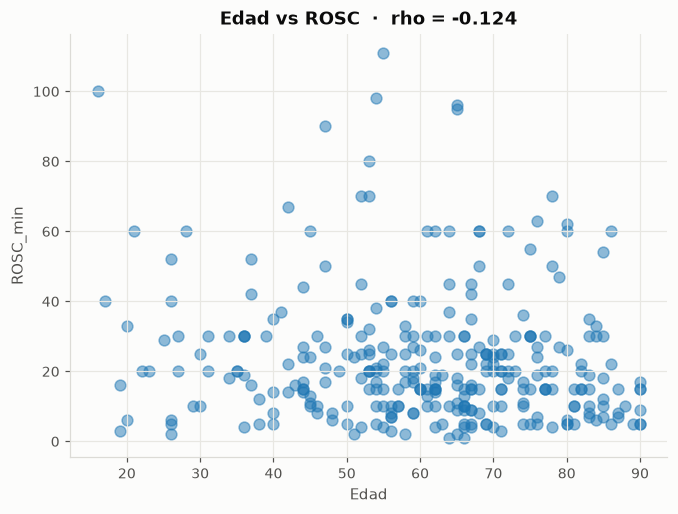

In [12]:
#  nunca interpretar un coeficiente sin mirar la dispersión.
corr_df.plot.scatter('Edad', 'ROSC_min', s=50, alpha=0.5, grid=True,
                     figsize=(7, 5),
                     title=f"Edad vs ROSC  ·  rho = "
                           f"{corr_df['Edad'].corr(corr_df['ROSC_min'], method='spearman'):.3f}");

**Verificación gráfica**

Un coeficiente bajo no significa que no haya relación, porque los coeficientes solo detectan relaciones monótonas. Una relación en forma de U o de campana puede dar ρ ≈ 0 y ser perfectamente real. La única manera de descartarlo es mirar la dispersión.

La nube no muestra ninguna estructura curva ni agrupamientos: los puntos se reparten de forma difusa con una leve tendencia descendente, coherente con el ρ = −0.124 calculado. No hay una relación no lineal que los coeficientes estén pasando por alto.

Lo que sí revela el gráfico es la **cola derecha de `ROSC`**: un grupo reducido de pacientes con tiempos de reanimación muy por encima del resto, que llegan hasta 111 minutos. Esa cola es la que justifica haber usado Spearman en lugar de Pearson, ya que el coeficiente de Pearson es sensible a ese tipo de valores extremos mientras que el de rangos no lo es.

In [ ]:
# Pares con correlación alta entre sí: candidatos a redundancia


# Columnas que provienen de una misma variable original. Las que no aparecen
# aquí son cada una su propio origen y nunca se filtran entre sí.
ORIGEN = {
    'ROSC_min': 'ROSC', 'ROSC_rapido': 'ROSC', 'ROSC_intermedio': 'ROSC',
    'ROSC_prolongado': 'ROSC', 'ROSC_sin_dato': 'ROSC',
    'Ritmo_desfibrilable': 'Ritmo', 'Ritmo_no_desfibrilable': 'Ritmo',
    'Ritmo_sin_registro': 'Ritmo',
    'Paro_extrahospitalario': 'Paro', 'Paro_intrahospitalario': 'Paro',
    'Paro_sin_registro': 'Paro',
    'TTM_33': 'TTM', 'TTM_36': 'TTM', 'Sin_TTM': 'TTM',
    'Hospital_A': 'Hospital', 'Hospital_B': 'Hospital', 'Hospital_D': 'Hospital',
    'Hospital_E': 'Hospital', 'Hospital_F': 'Hospital',
}

print("Pares con |rho| > 0.4, excluyendo indicadoras de una misma variable:\n")
for a, b in itertools.combinations(matriz.columns, 2):
    if ORIGEN.get(a, a) != ORIGEN.get(b, b) and abs(matriz.loc[a, b]) > 0.4:
        print(f"  {a:24s} ~ {b:22s} {matriz.loc[a, b]:+.3f}")

Pares con |rho| > 0.4, excluyendo indicadoras de una misma variable:

  CPC                      ~ Desenlace_favorable    -0.949
  Ritmo_sin_registro       ~ Paro_sin_registro      +0.671
  Ritmo_sin_registro       ~ TTM_36                 +0.583
  Paro_sin_registro        ~ TTM_33                 -0.407
  Paro_sin_registro        ~ TTM_36                 +0.456
  ROSC_intermedio          ~ Hospital_A             -0.515
  ROSC_sin_dato            ~ Hospital_A             +0.867
  ROSC_sin_dato            ~ Hospital_B             -0.497
  TTM_33                   ~ Hospital_F             -0.542
  Sin_TTM                  ~ Hospital_F             +0.746


**Detección de redundancias**

El segundo objetivo de esta sección es identificar variables que aporten información duplicada, porque incluirlas juntas en un modelo infla artificialmente las asociaciones y vuelve inestables los coeficientes. Se revisan todos los pares de la matriz con correlación absoluta superior a 0.4, excluyendo los que provienen de una misma variable original: los niveles de una categórica están correlacionados por construcción, ya que son excluyentes entre sí. Ese filtro reduce la lista de 20 pares a 10.

| Pareja | ρ | Lectura |
|---|---|---|
| `CPC` ~ `Desenlace_favorable` | −0.949 | Redundancia por definición |
| `ROSC_sin_dato` ~ `Hospital_A` | +0.867 | El Hospital A no registra ROSC |
| `Sin_TTM` ~ `Hospital_F` | +0.746 | El Hospital F casi no aplica TTM |
| `Ritmo_sin_registro` ~ `Paro_sin_registro` | +0.671 | Los datos faltan juntos |
| `Ritmo_sin_registro` ~ `TTM_36` | +0.583 | Mismo patrón de registro |
| `TTM_33` ~ `Hospital_F` | −0.542 | Cara opuesta del protocolo del F |
| `ROSC_intermedio` ~ `Hospital_A` | −0.515 | Cara opuesta del registro del A |
| `ROSC_sin_dato` ~ `Hospital_B` | −0.497 | El Hospital B sí registra ROSC |
| `Paro_sin_registro` ~ `TTM_36` | +0.456 | Mismo patrón de registro |
| `Paro_sin_registro` ~ `TTM_33` | −0.407 | Mismo patrón de registro |

**Qué concluye.**

Ninguna de estas parejas describe una relación clínica entre pacientes. Se agrupan en dos fenómenos distintos.

El primero es **redundancia por definición**, y solo afecta al par `CPC` ~ `Desenlace_favorable`. La fase 2 verificó que el desenlace se obtiene agrupando los niveles 1 y 2 de CPC como favorable y los niveles 3 a 5 como desfavorable, sin excepciones en los 607 registros. Son la misma información en dos formatos.

El segundo es **confusión estructural con el centro**, y explica los nueve pares restantes. Cinco de ellos relacionan variables clínicas con el hospital: el A concentra casi todos los casos sin dato de ROSC y el F casi todos los casos sin TTM. Los otros cuatro muestran que las ausencias de dato coinciden entre sí (a los pacientes a los que les falta el ritmo también les falta el lugar del paro). Si los datos se perdieran al azar, esas ausencias no coincidirían. Que coincidan confirma que la falta de registro es una característica del centro y no del paciente, tal como documentó la fase 3.

**Consecuencia para el modelo.**

Ninguna variable se descarta por colinealidad: las siete variables clínicas —`Age`, `Sex`, `OHCA`, `Shockable Rhythm`, `ROSC_cat`, `TTM_cat` y `Hospital` pasan al análisis de regresión. `CPC` se aparta, pero no por colinealidad sino por redundancia con la variable de respuesta; se conserva como conjunto de referencia por si interesa la severidad en cinco niveles.

`Hospital` entra al modelo como variable de control. Sin ese ajuste, el efecto del centro quedaría confundido dentro de los coeficientes de las variables clínicas.

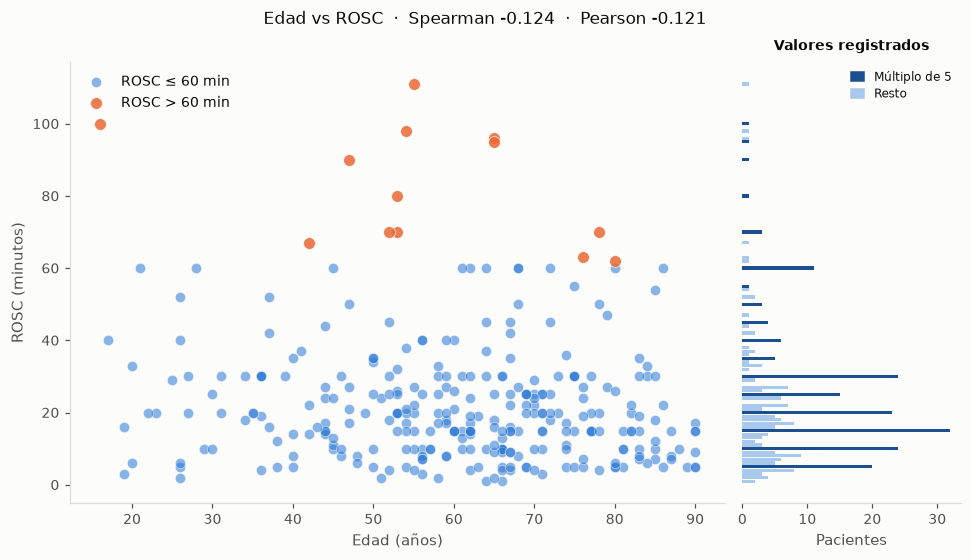

Con todos los datos (n=303):  Spearman -0.124 | Pearson -0.121
Sin ROSC > 60 min   (n=290):  Spearman -0.112 | Pearson -0.104

Múltiplos de 5:  57.8 %   (esperado sin redondeo: ~20 %)
Múltiplos de 10: 32.0 %   (esperado sin redondeo: ~10 %)


In [ ]:


d = corr_df[['Edad', 'ROSC_min']].dropna()
extremo = d['ROSC_min'] > 60

rho_todo, _ = spearmanr(d['Edad'], d['ROSC_min'])
r_todo,   _ = pearsonr(d['Edad'], d['ROSC_min'])
d_sin = d[~extremo]
rho_sin,  _ = spearmanr(d_sin['Edad'], d_sin['ROSC_min'])
r_sin,    _ = pearsonr(d_sin['Edad'], d_sin['ROSC_min'])

fig, (ax, axh) = plt.subplots(1, 2, figsize=(9.2, 5.2), sharey=True,
                              gridspec_kw={'width_ratios': [3, 1], 'wspace': .04})

# --- panel izquierdo: la dispersión -------------------------------------
ax.scatter(d.loc[~extremo, 'Edad'], d.loc[~extremo, 'ROSC_min'],
           s=45, alpha=.55, color='#2a78d6', edgecolor='white', linewidth=.5,
           label='ROSC ≤ 60 min')
ax.scatter(d.loc[extremo, 'Edad'], d.loc[extremo, 'ROSC_min'],
           s=60, alpha=.85, color='#eb6834', edgecolor='white', linewidth=.5,
           label='ROSC > 60 min')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('ROSC (minutos)')
ax.legend(frameon=False, loc='upper left', fontsize=9)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

# --- panel derecho: cuántas veces aparece cada valor ---------------------
conteo = d['ROSC_min'].value_counts().sort_index()
colores = ['#1c4f8f' if v % 5 == 0 else '#a8c8ec' for v in conteo.index]
axh.barh(conteo.index, conteo.values, height=.9, color=colores)
axh.set_xlabel('Pacientes')
axh.set_title('Valores registrados', fontsize=9, pad=8)
axh.legend(handles=[Patch(color='#1c4f8f', label='Múltiplo de 5'),
                    Patch(color='#a8c8ec', label='Resto')],
           frameon=False, fontsize=8, loc='upper right',
           handlelength=1.1, borderpad=.2, labelspacing=.3)
for s in ('top', 'right', 'left'):
    axh.spines[s].set_visible(False)
axh.tick_params(axis='y', length=0)

fig.suptitle(f'Edad vs ROSC  ·  Spearman {rho_todo:+.3f}  ·  Pearson {r_todo:+.3f}',
             fontsize=11, y=.97)
fig.subplots_adjust(left=.09, right=.97, top=.88, bottom=.11)
plt.show()

m5  = (d['ROSC_min'] % 5  == 0).mean() * 100
m10 = (d['ROSC_min'] % 10 == 0).mean() * 100
print(f"Con todos los datos (n={len(d)}):  Spearman {rho_todo:+.3f} | Pearson {r_todo:+.3f}")
print(f"Sin ROSC > 60 min   (n={len(d_sin)}):  Spearman {rho_sin:+.3f} | Pearson {r_sin:+.3f}")
print(f"\nMúltiplos de 5:  {m5:.1f} %   (esperado sin redondeo: ~20 %)")
print(f"Múltiplos de 10: {m10:.1f} %   (esperado sin redondeo: ~10 %)")

**Relación entre edad y tiempo de reanimación**

Se grafican las dos únicas variables continuas de la matriz, con los 13 pacientes de ROSC superior a 60 minutos resaltados en naranja.

**No existe asociación entre ambas.** Spearman da −0.124 y Pearson −0.121: dos coeficientes cercanos a cero sobre una nube sin dirección, en la que cada franja de edad presenta tiempos de reanimación de todo el rango. El tiempo hasta recuperar circulación no depende de la edad del paciente.

**Los valores extremos no distorsionan el resultado.** Pearson opera sobre las magnitudes y Spearman solo sobre el orden, de modo que un puñado de observaciones alejadas separaría a los dos coeficientes. Aquí coinciden hasta la tercera cifra, y los puntos naranjas se reparten entre los 16 y los 80 años sin concentrarse en ningún tramo: son reanimaciones prolongadas reales, no un artefacto de registro.

**La figura expone un problema que el coeficiente no captura.** Los puntos no se distribuyen de forma continua sobre el eje vertical, sino que se apilan en franjas horizontales sobre 5, 10, 15, 20, 30, 40 y 60 minutos, con vacíos entre ellas; el 57.8 % de los valores de ROSC son múltiplos de cinco. El tiempo no se cronometró, se estimó y se redondeó al registrarlo, y la densidad particular de la franja de 60 minutos sugiere un tope de redondeo antes que una medición. Esto respalda la decisión de la fase 3 de conservar `ROSC_cat`: los tramos "rápido", "intermedio" y "prolongado" son fieles a la precisión que los datos realmente tienen, mientras que los minutos exactos aparentan una exactitud inexistente.

**Alcance de la figura.** Describe a 303 pacientes (el 49.9 % de la cohorte) y ese subconjunto excluye por completo al Hospital A, que no registra la variable, por lo que no constituye una muestra aleatoria. El borde derecho del eje horizontal está además censurado: los pacientes que figuran con 90 años pueden tener más.

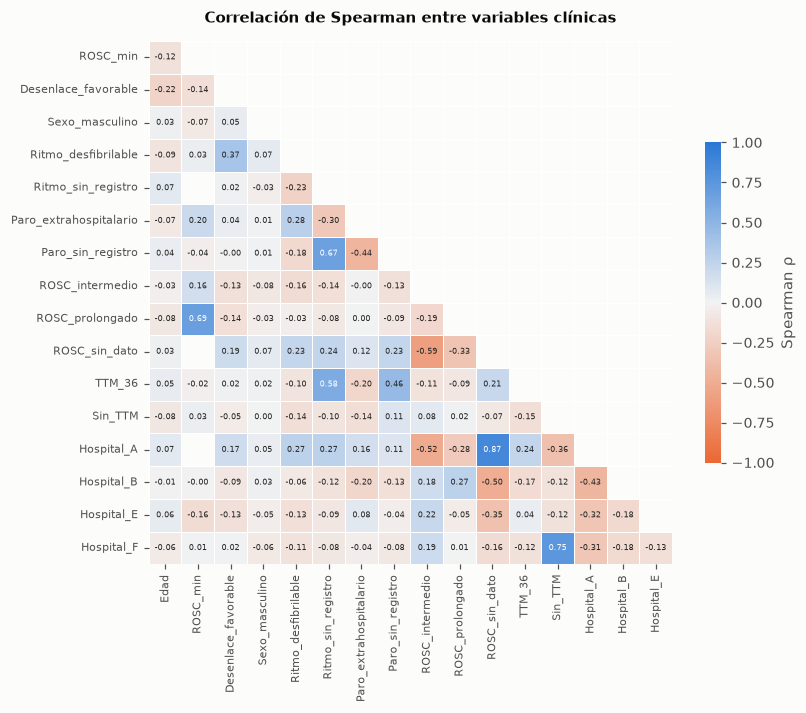

In [15]:



COLUMNAS = ['Edad', 'ROSC_min', 'Desenlace_favorable', 'Sexo_masculino',
            'Ritmo_desfibrilable', 'Ritmo_sin_registro',
            'Paro_extrahospitalario', 'Paro_sin_registro',
            'ROSC_intermedio', 'ROSC_prolongado', 'ROSC_sin_dato',
            'TTM_36', 'Sin_TTM',
            'Hospital_A', 'Hospital_B', 'Hospital_E', 'Hospital_F']

# se recorta además la primera fila y la última columna, que quedarían vacías
reducida = matriz.loc[COLUMNAS, COLUMNAS].iloc[1:, :-1]
mascara = np.triu(np.ones_like(reducida, dtype=bool), k=1)

DIVERGENTE = LinearSegmentedColormap.from_list(
    'naranja_gris_azul', ['#eb6834', '#f2f2f2', '#2a78d6'])

fig, ax = plt.subplots(figsize=(7.5, 6.4))
sns.heatmap(reducida, mask=mascara, cmap=DIVERGENTE, center=0, vmin=-1, vmax=1,
            square=True, linewidths=.6, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 5.5},
            cbar_kws={'label': 'Spearman ρ', 'shrink': .6}, ax=ax)
ax.set_title('Correlación de Spearman entre variables clínicas', fontsize=10, pad=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

**Matriz de correlación de Spearman**

La matriz reúne 17 variables: las 23 de `corr_df` menos `CPC`, redundante por definición, y menos una indicadora por cada grupo categórico, deducible de las restantes. Se representa solo el triángulo inferior, ya que la matriz es simétrica. 

**La fila del desenlace deja un solo predictor clínico de peso.** El ritmo desfibrilable alcanza ρ = +0.37 y no tiene competencia. Le siguen la edad con −0.22, el tiempo de reanimación con −0.14 y el tramo intermedio de ROSC con −0.13. En el extremo opuesto, el sexo (+0.05), el lugar del paro (0.00 a +0.04) y el protocolo de 36 °C (+0.02) son indistinguibles de cero: ninguna de esas tres variables discrimina el desenlace por sí sola.

**El Hospital A domina la estructura de la matriz.** Su columna es la única que presenta valores apreciables frente a casi todas las variables clínicas: +0.87 con la ausencia de dato de ROSC, −0.52 con el tramo intermedio, −0.36 con la ausencia de TTM, +0.27 con el ritmo desfibrilable, +0.27 con la ausencia de registro de ritmo, +0.24 con el protocolo de 36 °C y +0.17 con el desenlace favorable. Ningún otro centro se acerca a ese perfil; el Hospital F concentra su peculiaridad en una sola celda (+0.75 con la ausencia de TTM) y el B y el E reflejan sobre todo el contraste con A.

Estas asociaciones no describen a los pacientes sino al centro que los atiende: qué registra y qué protocolo aplica. 

**La consecuencia es que una ausencia de dato aparenta ser un buen pronóstico.** `ROSC_sin_dato` correlaciona +0.19 con el desenlace favorable, algo sin sentido clínico: no registrar una variable no mejora a ningún paciente. Ese coeficiente es el Hospital A actuando de forma encubierta, y explica por qué el +0.17 del propio hospital y el +0.19 de la ausencia de dato son prácticamente el mismo número.

**Las ausencias de registro forman un bloque.** `Ritmo_sin_registro` correlaciona +0.67 con `Paro_sin_registro` y +0.58 con `TTM_36`, y esta última +0.46 con `Paro_sin_registro`. A un mismo paciente le falta un dato y le falta el otro. Si los registros se perdieran al azar, esas ausencias no coincidirían; que lo hagan confirma que la omisión es un atributo institucional y no del caso, y respalda haber conservado las categorías de ausencia como niveles con nombre propio en la fase 3.

**Solo dos asociaciones entre predictores tienen lectura clínica.** El paro extrahospitalario correlaciona +0.28 con el ritmo desfibrilable y +0.20 con un tiempo de reanimación más largo. Ambas son modestas y coherentes con lo esperado: los paros fuera del hospital se presentan con más frecuencia en ritmos tratables y tardan más en revertirse. Ninguna alcanza magnitud suficiente para comprometer la independencia de las variables en el modelo.

**Cuatro pares intensos son aritméticos y no aparecen en la tabla de redundancias.** `ROSC_prolongado` con `ROSC_min` (+0.69), `ROSC_sin_dato` con `ROSC_intermedio` (−0.59), `Paro_sin_registro` con `Paro_extrahospitalario` (−0.44) y `Hospital_A` con `Hospital_B` (−0.43) enfrentan indicadoras de una misma variable de origen, que son excluyentes entre sí por construcción. El filtro aplicado en la tabla los descarta; en la figura permanecen visibles porque el mapa muestra la matriz completa.

**Las celdas en blanco son un resultado, no un fallo.** La columna `ROSC_min` queda vacía en sus cruces con `ROSC_sin_dato`, `Ritmo_sin_registro` y `Hospital_A`. Un coeficiente exige que ambas variables presenten variación, y entre los 303 pacientes con ROSC registrado ninguno procede del Hospital A ni carece de registro de ritmo: esas columnas valen cero para todos y la correlación resulta indefinida. Esos tres huecos son la evidencia visual más directa de la limitación central del estudio, que ningún coeficiente alcanza a expresar: la variable ROSC y el Hospital A son mutuamente excluyentes.

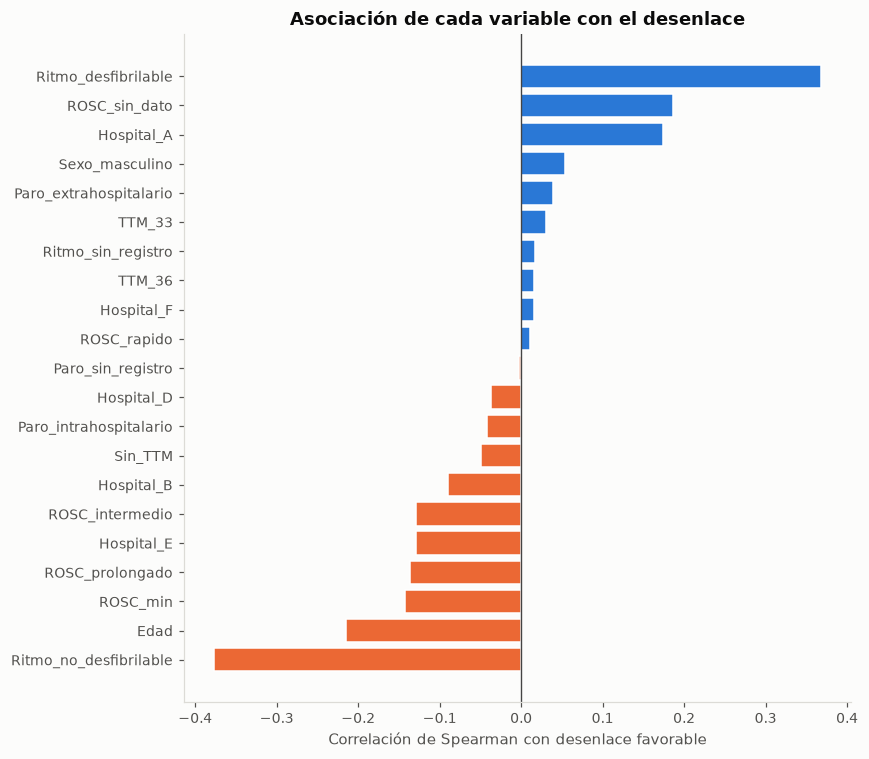

In [16]:
serie = (matriz['Desenlace_favorable']
         .drop(['Desenlace_favorable', 'CPC'])
         .sort_values())

colores = ['#eb6834' if v < 0 else '#2a78d6' for v in serie]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(serie.index, serie.values, color=colores, edgecolor='white')
ax.axvline(0, color='#444', linewidth=.9)
ax.set_xlabel('Correlación de Spearman con desenlace favorable')
ax.set_title('Asociación de cada variable con el desenlace')
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()
plt.show()

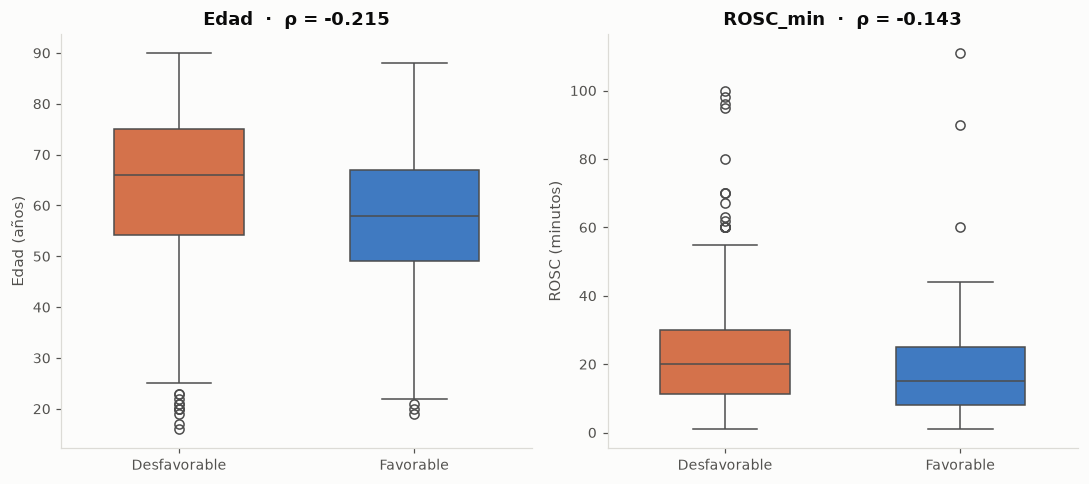

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
paleta = {0: '#eb6834', 1: '#2a78d6'}

for ax, var, etiqueta in zip(axes, ['Edad', 'ROSC_min'],
                             ['Edad (años)', 'ROSC (minutos)']):
    sns.boxplot(data=corr_df, x='Desenlace_favorable', y=var,
                hue='Desenlace_favorable', palette=paleta,
                legend=False, width=.55, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Desfavorable', 'Favorable'])
    ax.set_xlabel('')
    ax.set_ylabel(etiqueta)
    rho = matriz.loc[var, 'Desenlace_favorable']
    ax.set_title(f'{var}  ·  ρ = {rho:+.3f}')
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

**Figura Edad y tiempo de reanimación según el desenlace**

Cada caja contiene al 50 % central de los pacientes de su grupo, la línea interior marca la mediana y los círculos señalan los valores atípicos.

**Las dos variables se comportan en la dirección esperada.** La mediana de edad es de 66 años en el grupo desfavorable y de 58 en el favorable; la de ROSC, de 20 y 15 minutos respectivamente. Mayor edad y reanimaciones más largas acompañan al desenlace desfavorable, tal como anticipaban los coeficientes de −0.215 y −0.143.

**Ninguna de las dos separa a los grupos.** En la edad, la caja del grupo desfavorable abarca de 54 a 75 años y la del favorable de 49 a 67: entre los 54 y los 67 años conviven ambos desenlaces sin distinción. El panel de ROSC presenta un solapamiento equivalente. Esta es la lectura visual de una correlación débil: la variable desplaza la distribución completa sin llegar a dividirla, de modo que sirve para caracterizar poblaciones y no para pronosticar a un paciente individual. 

**Los valores atípicos se reparten de forma asimétrica en el ROSC.** El grupo desfavorable concentra una docena de reanimaciones superiores a 60 minutos, que alcanzan los 100, frente a tres en el grupo favorable. Las reanimaciones muy prolongadas terminan casi siempre en desenlace desfavorable, pero son demasiado escasas para mover el coeficiente global. En la edad, en cambio, los atípicos son pacientes jóvenes (entre 16 y 25 años) presentes en ambos grupos.

**Alcance del panel derecho.** Describe a 303 pacientes, el 49.9 % de la cohorte, y ese subconjunto excluye por completo al Hospital A, que no registra la variable. La comparación no se puede extender a la cohorte completa sin ese matiz.

### Síntesis de la sección 1.1

**Relaciones entre variables**

El análisis se realizó con el coeficiente de Spearman sobre las 23 columnas de `corr_df`, complementado con visualizaciones: el mapa de calor de la matriz completa, el diagrama de barras de asociación con el desenlace, el diagrama de dispersión de las dos variables numéricas y los diagramas de caja por desenlace.

De ese examen emerge un único predictor clínico de peso. El **ritmo desfibrilable** alcanza ρ = +0.37 con el desenlace favorable y no tiene competencia: le siguen la **edad** con −0.22, el **tiempo hasta ROSC** con −0.14 y el tramo intermedio de reanimación con −0.13. En el extremo opuesto, el **sexo** (+0.05), el **lugar del paro** (+0.04) y el **protocolo de temperatura** (+0.02) resultan indistinguibles de cero: ninguna de las tres discrimina el desenlace por sí sola.

Los diagramas de caja matizan incluso las asociaciones que sí existen. En la edad, la caja del grupo desfavorable abarca de 54 a 75 años y la del favorable de 49 a 67: entre los 54 y los 67 años conviven ambos desenlaces sin distinción. Una correlación de −0.22 desplaza la distribución completa sin llegar a dividirla, de modo que la variable sirve para caracterizar poblaciones y no para pronosticar a un paciente individual.

Entre predictores solo se detectaron dos asociaciones con lectura clínica, ambas modestas y en la dirección esperada: el paro extrahospitalario correlaciona +0.28 con el ritmo desfibrilable y +0.20 con un tiempo de reanimación más largo.

**Redundancias detectadas**

La revisión de todos los pares con |ρ| > 0.4 arrojó 20 resultados, de los cuales 10 enfrentaban indicadoras de una misma variable de origen (excluyentes entre sí por construcción) y fueron descartados mediante un filtro por variable de procedencia. Los 10 restantes se agrupan en dos fenómenos de naturaleza distinta.

*Redundancia propiamente dicha.* Un solo par: `CPC` con `Desenlace_favorable`, ρ = −0.949. La fase 2 verificó que el desenlace se obtiene agrupando los niveles 1 y 2 de CPC como favorable y los niveles 3 a 5 como desfavorable, sin excepciones en los 607 registros. Son la misma información en dos formatos y no pueden coexistir en un modelo.

*Confusión estructural con el centro.* Los nueve pares restantes. Cinco vinculan variables clínicas con el hospital (encabezados por `ROSC_sin_dato` con `Hospital_A` (+0.87) y `Sin_TTM` con `Hospital_F` (+0.75)) y cuatro muestran que las ausencias de registro se presentan agrupadas: a un mismo paciente le falta el ritmo y le falta el lugar del paro. Si los registros se perdieran al azar, esas ausencias no coincidirían.

La consecuencia práctica es visible en la fila del desenlace: `ROSC_sin_dato` correlaciona +0.19 con el desenlace favorable, algo sin sentido clínico, puesto que no registrar una variable no mejora a ningún paciente. Ese coeficiente es el Hospital A actuando de forma encubierta, y es prácticamente el mismo valor que el +0.17 del propio hospital.

Ninguna variable se elimina por colinealidad. `CPC` se aparta por redundancia con la respuesta, no por correlación con un predictor y se conserva como respuesta alternativa para el modelo ordinal. `Hospital` se retiene e ingresa al modelo **como variable de control**: sin ese ajuste, su efecto quedaría confundido dentro de los coeficientes clínicos. Dos decisiones adicionales quedan declaradas de forma explícita, ya que el filtro por variable de procedencia las oculta en la salida: `ROSC_cat` se emplea en los análisis sobre la cohorte completa y `ROSC` numérica solo en los restringidos a los 303 pacientes con dato; y de la temperatura se conserva únicamente `TTM_cat`, que representa sin pérdida los dos valores de la versión numérica y añade el grupo sin manejo térmico.

El conjunto que pasa a la regresión de la sección 1.2 queda en siete variables: `Age`, `Sex`, `OHCA`, `Shockable Rhythm`, `ROSC_cat`, `TTM_cat` y `Hospital`.

**Variables seleccionadas y criterio de selección**

Se incluyó **la totalidad de las variables clínicas** de `clinical_prepared.csv` las ocho de la cohorte más `CPC`, sin descartar ninguna de antemano. El criterio fue deliberado: el objetivo del proyecto es pronosticar el desenlace neurológico tras un paro cardiaco, y excluir una variable antes de medirla habría significado decidir por anticipado aquello que el análisis debía establecer. Las señales de EEG quedan fuera de esta fase y se abordan en la fase 5, conforme al alcance acordado.

`CPC` se incorporó a propósito pese a conocerse su relación con el desenlace, para que la redundancia quedara cuantificada en la matriz y no solo afirmada en el texto. El resultado, ρ = −0.949, es la confirmación empírica de esa decisión de diseño.

Las variables categóricas se codificaron en indicadoras conservando **todos sus niveles**, incluidas las categorías de ausencia de dato, en lugar de omitir un nivel de referencia. Esa elección responde a un hallazgo de la fase 3: el patrón de lo que falta resultó ser informativo. La codificación completa es la que permite que `ROSC_sin_dato` aparezca como columna propia y que la confusión con el Hospital A quede visible como un coeficiente de +0.87. Con una codificación reducida, ese resultado —el más importante de la sección— habría sido invisible.


### **1.2. Análisis de regresiones**
---

- A partir de las correlaciones identificadas, ¿es posible llevar a cabo un análisis de regresiones para estimar el valor de alguna de las variables de interés?
- ¿Cuáles fueron las variables seleccionadas para el análisis de regresiones y cómo se eligieron en función de los objetivos del proyecto?



La variable de interés del proyecto es el desenlace neurológico, y es **binaria**. Ajustar sobre ella una regresión lineal tendría tres defectos: produciría probabilidades estimadas fuera del intervalo [0, 1], violaría el supuesto de homocedasticidad (la varianza de una variable de Bernoulli depende de su propia media) y dejaría residuos que no pueden ser normales porque la respuesta solo toma dos valores. La técnica que corresponde es la **regresión logística**, que modela el logaritmo de la razón de momios (*odds*) como función lineal de las variables explicativas y devuelve una probabilidad acotada.



El análisis de correlaciones midió asociaciones de a dos variables por vez. Eso deja sin responder la pregunta que realmente interesa: cuando varias variables actúan a la vez, ¿cuánto aporta cada una por su cuenta?

Es una distinción que importa. La sección 1.1 encontró que el ritmo desfibrilable se asocia a mejor desenlace, pero también que los pacientes con ese ritmo se concentran en determinados hospitales. Una correlación no puede separar ambas cosas. Una regresión sí.

**Por qué regresión logística y no lineal**

La variable que se quiere predecir es el desenlace, que solo toma dos valores: favorable o desfavorable. Una regresión lineal sobre una variable de 0 y 1 puede devolver predicciones de 1.3 o de −0.2, y una probabilidad no puede valer eso. La regresión logística transforma el resultado de modo que siempre quede entre 0 y 1.



---

**Cómo se leen los resultados**

Los tres conceptos que siguen son necesarios para interpretar todas las tablas de esta sección.

**Los momios.** Una probabilidad compara los casos favorables contra el total de pacientes. Los momios los comparan contra los casos desfavorables:

$$\text{momios} = \frac{p}{1-p}$$


La regresión logística trabaja con momios, y no con probabilidades, por una razón matemática. Una probabilidad está acotada entre 0 y 1 y una ecuación lineal no lo está; los momios van de 0 a infinito y su logaritmo cubre todos los números reales, de modo que ahí sí cabe un modelo lineal. Por eso los coeficientes que devuelve el modelo son **logaritmos de momios** y hay que aplicarles la función exponencial para interpretarlos.

**La razón de momios (OR).** Es el cociente entre los momios de un grupo y los de otro:

$$OR = \frac{0.209}{1.23} = 0.17$$

Un OR de 1 indica ausencia de diferencia; por debajo de 1, peor pronóstico; por encima, mejor. Si el intervalo de confianza del OR contiene el 1, el efecto no es distinguible del azar.

Conviene una precisión para no sobreinterpretar: un OR **no** equivale a "cuántas veces más probable". El OR magnifica la diferencia respecto de lo que sugiere el lenguaje corriente. Por ese motivo los resultados se acompañan de las probabilidades siempre que sea posible.

**La categoría de referencia.** Un modelo no puede estimar un coeficiente para todos los niveles de una variable categórica a la vez: necesita dejar uno fuera y usarlo como punto de comparación. Los coeficientes de los demás niveles responden entonces a la pregunta *"¿cuánto cambia el desenlace respecto de ese nivel de referencia?"*. En las tablas que siguen, la categoría de referencia es la que no aparece en la lista.

---

Podría construirse directamente el modelo completo. Se construyen cuatro, de forma incremental, porque lo que interesa observar es **cómo cambia cada coeficiente al añadir las demás variables**:

| Modelo | Contenido | Qué permite observar |
|---|---|---|
| 1 | Solo el ritmo | El efecto crudo de la variable más fuerte |
| 2 | Las seis variables clínicas | Si ese efecto sobrevive al control mutuo |
| 3 | Añade el hospital | Cuánto de lo observado era procedencia institucional |
| 4 | Descarta lo no significativo | El modelo final, más parsimonioso |

Un coeficiente que se mantiene estable a lo largo de los cuatro modelos corresponde a un efecto propio de esa variable. Uno que se desploma al añadir otra estaba tomando prestado su efecto. Y uno que **aparece** solo tras el ajuste estaba enmascarado por una variable que lo compensaba.

Esa progresión es el verdadero resultado de la sección, y no puede verse en un único modelo. 

La sección 1.1 encontró un predictor con fuerza real (ritmo desfibrilable, ρ = +0.37) y dos moderados (edad, tiempo de ROSC). Eso basta para una regresión logística que estime la probabilidad de desenlace favorable.



**Marco de modelado**

- La base de datos tiene los nombres originales en inglés y algunos con espacios, como Shockable Rhythm. Las fórmulas de statsmodels se escriben como texto ("favorable ~ edad + ritmo"), y un nombre con espacio rompe la fórmula. Por esto se renombran.

- Shockable Rhythm guardaba 'True', 'False' y 'Desconocido'. Ahora dice 'Desfibrilable', 'No desfibrilable' y 'Sin registro'.


Un modelo no puede estimar un coeficiente para todos los niveles de una variable a la vez. Necesita dejar uno fuera y usarlo como punto de comparación. Ese nivel es la referencia.


In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

modelo_df = pd.DataFrame({
    'favorable': (clinical['Outcome'] == 'Good').astype(int),
    'edad':      clinical['Age'],
    'sexo':      clinical['Sex'].astype(str).replace(
                    {'Male': 'Hombre', 'Female': 'Mujer'}),
    'paro':      clinical['OHCA'].astype(str).replace(
                    {'True': 'Extrahospitalario', 'False': 'Intrahospitalario',
                     'Desconocido': 'Sin registro'}),
    'ritmo':     clinical['Shockable Rhythm'].astype(str).replace(
                    {'True': 'Desfibrilable', 'False': 'No desfibrilable',
                     'Desconocido': 'Sin registro'}),
    'rosc':      clinical['ROSC_cat'].astype(str).replace(
                    {'Rápido (1-10 min)':      '1 Rápido',
                     'Intermedio (11-30 min)': '2 Intermedio',
                     'Prolongado (>30 min)':   '3 Prolongado',
                     'Sin dato':               '4 Sin dato'}),
    'ttm':       clinical['TTM_cat'].astype(str),
    'hospital':  clinical['Hospital'].astype(str),
})

print(f"Pacientes: {len(modelo_df)}  ·  Favorables: {modelo_df['favorable'].sum()}")
print("\nCategoría de referencia de cada variable (la primera alfabéticamente):")
for v in ['sexo', 'paro', 'ritmo', 'rosc', 'ttm', 'hospital']:
    print(f"  {v:10s} → {sorted(modelo_df[v].unique())[0]}")

Pacientes: 607  ·  Favorables: 225

Categoría de referencia de cada variable (la primera alfabéticamente):
  sexo       → Hombre
  paro       → Extrahospitalario
  ritmo      → Desfibrilable
  rosc       → 1 Rápido
  ttm        → 33 °C
  hospital   → A


In [19]:
#Ordenar los predictores por correlación
matriz['Desenlace_favorable'].drop(['Desenlace_favorable', 'CPC']).sort_values()[::-1]

Ritmo_desfibrilable       0.367850
ROSC_sin_dato             0.186339
Hospital_A                0.173993
Sexo_masculino            0.054052
Paro_extrahospitalario    0.039572
TTM_33                    0.030545
Ritmo_sin_registro        0.017376
TTM_36                    0.015756
Hospital_F                0.015296
ROSC_rapido               0.010974
Paro_sin_registro        -0.002687
Hospital_D               -0.037389
Paro_intrahospitalario   -0.041994
Sin_TTM                  -0.049375
Hospital_B               -0.089767
ROSC_intermedio          -0.128781
Hospital_E               -0.129586
ROSC_prolongado          -0.136677
ROSC_min                 -0.143008
Edad                     -0.215095
Ritmo_no_desfibrilable   -0.376864
Name: Desenlace_favorable, dtype: float64

**Modelo 1: solo el ritmo**

In [20]:
m1 = smf.logit("favorable ~ ritmo", data=modelo_df).fit()
m1.summary()

Optimization terminated successfully.
         Current function value: 0.582803
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              favorable   No. Observations:                  607
Model:                          Logit   Df Residuals:                      604
Method:                           MLE   Df Model:                            2
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.1160
Time:                        16:38:26   Log-Likelihood:                -353.76
converged:                       True   LL-Null:                       -400.20
Covariance Type:            nonrobust   LLR p-value:                 6.768e-21
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.2095      0.117      1.796      0.073      -0.019       0.438
ritmo[T.No desfibrilable]    -1.7764      0.197     -9.019      0.000      -2.162      -1.390
ritmo[T.Sin registro]        -0.5890      0.378     -1.557      0.120      -1.331       0.153
=============================================================================================
"""

Se ajusta una regresión logística con la variable que la sección 1.1 identificó como el predictor más fuerte (ρ = +0.37). 

El modelo converge sobre los 607 pacientes de la cohorte y resulta globalmente significativo (LLR *p* = 6.8 × 10⁻²¹), con un R² de 0.116. La categoría de referencia es el ritmo desfibrilable, de modo que los dos coeficientes estimados expresan cuánto se aparta cada nivel restante de ese punto de comparación.

| Nivel | Coeficiente | *p* | IC 95 % |
|---|---|---|---|
| Ritmo desfibrilable | referencia | — | — |
| Sin registro | −0.589 | 0.120 | [−1.331, +0.153] |
| No desfibrilable | **−1.776** | **< 0.001** | [−2.162, −1.390] |

**Ambos coeficientes son negativos**, en la dirección anticipada por el análisis de correlaciones: cualquier condición distinta de un ritmo desfibrilable reduce la probabilidad de desenlace favorable.

**Solo uno de ellos es concluyente.** El de `No desfibrilable` tiene un p-valor prácticamente nulo y su intervalo de confianza no contiene el cero. El de `Sin registro`, en cambio, alcanza *p* = 0.120 y su intervalo va de −1.331 a +0.153: al incluir el cero, no permite afirmar que esos pacientes difieran de los de ritmo desfibrilable. Con solo 32 casos en esa categoría, la muestra no basta para distinguir el efecto del azar.

**Traducidos a probabilidades**, los coeficientes describen tres grupos claramente separados:

| Ritmo | Probabilidad estimada de desenlace favorable |
|---|---|
| Desfibrilable | 55.2 % |
| Sin registro | 40.6 % |
| No desfibrilable | 17.3 % |



**Modelo 2: todas las variables clínicas**

In [21]:
m2 = smf.logit("favorable ~ edad + sexo + paro + ritmo + rosc + ttm",
               data=modelo_df).fit()
m2.summary()

Optimization terminated successfully.
         Current function value: 0.545207
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              favorable   No. Observations:                  607
Model:                          Logit   Df Residuals:                      595
Method:                           MLE   Df Model:                           11
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.1731
Time:                        16:38:26   Log-Likelihood:                -330.94
converged:                       True   LL-Null:                       -400.20
Covariance Type:            nonrobust   LLR p-value:                 3.247e-24
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     2.5536      0.515      4.957      0.000       1.544       3.563
sexo[T.Mujer]                -0.1770      0.211     -0.840      0.401      -0.590       0.236
paro[T.Intrahospitalario]     0.3939      0.265      1.487      0.137      -0.125       0.913
paro[T.Sin registro]         -0.1555      0.541     -0.287      0.774      -1.216       0.905
ritmo[T.No desfibrilable]    -1.8706      0.225     -8.299      0.000      -2.312      -1.429
ritmo[T.Sin registro]        -0.3338      0.605     -0.552      0.581      -1.520       0.852
rosc[T.2 Intermedio]         -0.6612      0.329     -2.011      0.044      -1.305      -0.017
rosc[T.3 Prolongado]         -1.6685      0.463     -3.605      0.000      -2.576      -0.761
rosc[T.4 Sin dato]           -0.1253      0.306     -0.409      0.682      -0.726       0.475
ttm[T.36 °C]                 -0.1696      0.381     -0.445      0.656      -0.916       0.577
ttm[T.Sin TTM]                0.0358      0.287      0.125      0.901      -0.526       0.597
edad                         -0.0327      0.006     -5.055      0.000      -0.045      -0.020
=============================================================================================
"""

**Modelo 2 · Las seis variables clínicas**

Se incorporan al modelo la edad, el sexo, el lugar del paro, el tramo de reanimación y el protocolo de temperatura, manteniendo el ritmo. El hospital queda deliberadamente fuera: se añade en el modelo siguiente para aislar su contribución.

El ajuste mejora de forma apreciable (el pseudo R² pasa de 0.116 a 0.173) y el modelo sigue siendo globalmente significativo (LLR *p* = 3.2 × 10⁻²⁴). Cuatro coeficientes resultan significativos y siete no.

| Variable | Coeficiente | OR | *p* |
|---|---|---|---|
| Ritmo no desfibrilable | −1.871 | 0.15 | < 0.001 |
| ROSC prolongado (>30 min) | −1.669 | 0.19 | < 0.001 |
| ROSC intermedio (11–30 min) | −0.661 | 0.52 | 0.044 |
| Edad (por año) | −0.033 | 0.97 | < 0.001 |

**El efecto del ritmo resiste el ajuste.** Su coeficiente pasa de −1.776 en el modelo 1 a −1.871 aquí: lejos de debilitarse, se refuerza levemente. Esto indica que su asociación con el desenlace es propia y no procedía de otras variables correlacionadas con él. Es el resultado más robusto del análisis.

**El tiempo de reanimación revela un gradiente que las correlaciones no detectaban.** Tomando el tramo rápido como referencia, los momios de desenlace favorable se reducen a la mitad en el tramo intermedio (OR = 0.52) y a menos de una quinta parte en el prolongado (OR = 0.19). El deterioro es progresivo y ordenado. La sección 1.1 había estimado ρ = −0.14 para `ROSC` en minutos, una asociación aparentemente despreciable; la versión categórica la recupera porque la relación no es proporcional al tiempo transcurrido, sino escalonada por tramos.

**La edad aporta un efecto pequeño pero consistente.** Cada año de edad reduce los momios en un 3.2 % (OR = 0.968, IC 95 % 0.956–0.980). Expresado por década, el OR es de 0.72.

**Tres variables no muestran efecto alguno.** El sexo (*p* = 0.401), el lugar del paro (*p* = 0.137 y 0.774) y el protocolo de temperatura (*p* = 0.656 y 0.901) resultan indistinguibles de cero, en coincidencia con lo observado en el análisis de correlaciones.

**La categoría de ausencia de dato no sigue el gradiente.** El coeficiente de `ROSC = Sin dato` es de −0.125 con *p* = 0.682: mientras los tramos intermedio y prolongado se apartan nítidamente de la referencia, esta categoría se comporta como si correspondiera a una reanimación rápida. Es la misma anomalía que la sección 1.1 detectó al encontrar ρ = +0.19 entre `ROSC_sin_dato` y el desenlace favorable. La hipótesis es que esos pacientes no presentan mejor pronóstico por razones clínicas, sino porque en su gran mayoría proceden del Hospital A. El modelo 3 permite contrastarla: si al incorporar el centro este coeficiente permanece en cero y el hospital absorbe el efecto, la explicación queda confirmada.

**Reserva sobre el protocolo de temperatura.** Sus dos coeficientes son nulos en este modelo, pero la sección 1.1 documentó que la ausencia de TTM está fuertemente asociada al Hospital F (ρ = +0.75). Cabe esperar que estos coeficientes se modifiquen al introducir el centro. De ocurrir, no constituiría una inconsistencia sino evidencia de que el efecto del protocolo estaba enmascarado por la institución que lo aplica.

**Modelo 3: añadiendo el hospital**

In [22]:
m3 = smf.logit("favorable ~ edad + sexo + paro + ritmo + rosc + ttm + hospital",
               data=modelo_df).fit()
m3.summary()

Optimization terminated successfully.
         Current function value: 0.533416
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              favorable   No. Observations:                  607
Model:                          Logit   Df Residuals:                      591
Method:                           MLE   Df Model:                           15
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.1910
Time:                        16:38:26   Log-Likelihood:                -323.78
converged:                       True   LL-Null:                       -400.20
Covariance Type:            nonrobust   LLR p-value:                 6.577e-25
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     2.4627      0.748      3.292      0.001       0.997       3.929
sexo[T.Mujer]                -0.2177      0.214     -1.018      0.309      -0.637       0.202
paro[T.Intrahospitalario]     0.3888      0.277      1.401      0.161      -0.155       0.933
paro[T.Sin registro]          0.3132      0.603      0.519      0.604      -0.869       1.495
ritmo[T.No desfibrilable]    -1.9103      0.233     -8.212      0.000      -2.366      -1.454
ritmo[T.Sin registro]        -0.6835      0.650     -1.051      0.293      -1.958       0.591
rosc[T.2 Intermedio]         -0.9325      0.350     -2.667      0.008      -1.618      -0.247
rosc[T.3 Prolongado]         -1.8934      0.483     -3.919      0.000      -2.840      -0.947
rosc[T.4 Sin dato]            0.0046      0.568      0.008      0.994      -1.109       1.118
ttm[T.36 °C]                 -0.1816      0.391     -0.464      0.642      -0.948       0.585
ttm[T.Sin TTM]               -1.4566      0.581     -2.505      0.012      -2.596      -0.317
hospital[T.B]                 0.2618      0.589      0.444      0.657      -0.893       1.417
hospital[T.D]                 0.7411      0.559      1.325      0.185      -0.355       1.838
hospital[T.E]                -0.1672      0.619     -0.270      0.787      -1.381       1.046
hospital[T.F]                 2.1532      0.819      2.628      0.009       0.547       3.759
edad                         -0.0332      0.007     -5.007      0.000      -0.046      -0.020
=============================================================================================
"""

**Modelo 3 · Incorporación del hospital**

Se añade el centro de atención a las seis variables clínicas del modelo anterior. El pseudo R² sube de 0.173 a 0.191 y el modelo se mantiene globalmente significativo (LLR *p* = 6.6 × 10⁻²⁵). La categoría de referencia es el Hospital A, el de mayor volumen de la cohorte.

Este ajuste produce los dos resultados centrales de la sección.

**Un efecto oculto se revela.** El coeficiente de la ausencia de manejo térmico pasa de +0.036 (*p* = 0.901) a −1.457 (*p* = 0.012), lo que equivale a un OR de 0.233. La explicación aparece en la misma tabla: el Hospital F recibe un coeficiente de +2.153, y la sección 1.1 documentó que ese centro concentra los casos sin TTM (ρ = +0.75). Ambos efectos se compensaban mutuamente, de modo que la ventaja institucional enmascaraba la desventaja del protocolo. Sin el ajuste por centro, el análisis habría concluido que el manejo térmico es irrelevante.

**Una asociación aparente se desvanece.** El coeficiente de `ROSC = Sin dato` cae a +0.005 y su error estándar aumenta de 0.306 a 0.568. Ese incremento es la firma de la colinealidad con el Hospital A, documentada en el análisis de redundancias con ρ = +0.87: una vez presente el centro, el modelo ya no puede separar ambas condiciones. Queda así confirmado que el ρ = +0.186 que la sección 1.1 atribuía a la ausencia de registro reflejaba procedencia institucional y no condición clínica.

**Los efectos clínicos se mantienen o se refuerzan.**

| Variable | OR | IC 95 % | *p* |
|---|---|---|---|
| Ritmo no desfibrilable | 0.148 | 0.094 – 0.234 | < 0.001 |
| ROSC prolongado (>30 min) | 0.151 | 0.058 – 0.388 | < 0.001 |
| ROSC intermedio (11–30 min) | 0.394 | 0.198 – 0.781 | 0.008 |
| Sin manejo de temperatura | 0.233 | 0.075 – 0.728 | 0.012 |
| Hospital F | 8.612 | 1.728 – 42.91 | 0.009 |
| Edad (por año) | 0.967 | 0.955 – 0.980 | < 0.001 |

El coeficiente del ritmo pasa de −1.871 a −1.910 y el de la edad de −0.0327 a −0.0332: ambos permanecen estables frente al ajuste, lo que indica que sus efectos son propios y no procedían de diferencias entre centros. El gradiente del tiempo de reanimación, en cambio, se acentúa (el tramo intermedio pasa de OR 0.52 a 0.39 y el prolongado de 0.19 a 0.15), de modo que descontar el centro permite apreciarlo con mayor nitidez.

**Variables sin efecto detectable.** El sexo (*p* = 0.309) y el lugar del paro (*p* = 0.161 y 0.604) siguen sin alcanzar significancia, en coincidencia con el análisis de correlaciones. Tampoco la alcanzan los hospitales B, D y E frente al A, aunque se conservan en el modelo: una variable categórica se incluye con todos sus niveles o no se incluye.


**Qué justifica el modelo siguiente.** El pseudo R² de 0.191 es el más alto de la serie, pero se obtiene con 15 parámetros. El modelo final prescinde del sexo y del lugar del paro y desciende únicamente a 0.187 con 12 parámetros: una pérdida de ajuste de 0.004 a cambio de tres parámetros menos. Esa comparación es el argumento formal para descartar ambas variables.

**Modelo final, descartando lo no significativo**

In [23]:
m4 = smf.logit("favorable ~ edad + ritmo + rosc + ttm + hospital",
               data=modelo_df).fit()
m4.summary()

Optimization terminated successfully.
         Current function value: 0.535995
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              favorable   No. Observations:                  607
Model:                          Logit   Df Residuals:                      594
Method:                           MLE   Df Model:                           12
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.1870
Time:                        16:38:26   Log-Likelihood:                -325.35
converged:                       True   LL-Null:                       -400.20
Covariance Type:            nonrobust   LLR p-value:                 6.495e-26
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     2.4358      0.732      3.327      0.001       1.001       3.871
ritmo[T.No desfibrilable]    -1.8562      0.227     -8.185      0.000      -2.301      -1.412
ritmo[T.Sin registro]        -0.5187      0.490     -1.059      0.290      -1.479       0.442
rosc[T.2 Intermedio]         -1.0290      0.343     -3.001      0.003      -1.701      -0.357
rosc[T.3 Prolongado]         -1.9962      0.478     -4.180      0.000      -2.932      -1.060
rosc[T.4 Sin dato]           -0.0696      0.554     -0.126      0.900      -1.155       1.016
ttm[T.36 °C]                 -0.1075      0.385     -0.279      0.780      -0.863       0.647
ttm[T.Sin TTM]               -1.3275      0.550     -2.415      0.016      -2.405      -0.250
hospital[T.B]                 0.3864      0.579      0.667      0.505      -0.749       1.522
hospital[T.D]                 0.7858      0.548      1.435      0.151      -0.287       1.859
hospital[T.E]                -0.1836      0.608     -0.302      0.763      -1.375       1.008
hospital[T.F]                 2.0811      0.811      2.566      0.010       0.491       3.671
edad                         -0.0322      0.007     -4.892      0.000      -0.045      -0.019
=============================================================================================
"""

**Modelo final · Variables clínicas con el hospital como control**

Se eliminan el sexo y el lugar del paro, que en el modelo 2 no alcanzaron significancia, y se incorpora el hospital. El ajuste mejora pese a usar menos predictores: el pseudo R² pasa de 0.173 a 0.187 y el modelo sigue siendo globalmente significativo (LLR *p* = 6.5 × 10⁻²⁶).

`Hospital` se retiene aunque tres de sus cuatro niveles no sean significativos. Esto constituye una excepción deliberada al criterio de descartar variables por p-valor: la sección 1.1 demostró que el centro determina qué se registra y qué protocolo se aplica, de modo que excluirlo haría que sus diferencias quedaran absorbidas por los coeficientes clínicos.

| Variable | OR | IC 95 % | *p* |
|---|---|---|---|
| Ritmo no desfibrilable | 0.156 | 0.100 – 0.244 | < 0.001 |
| ROSC prolongado (>30 min) | 0.136 | 0.053 – 0.346 | < 0.001 |
| ROSC intermedio (11–30 min) | 0.357 | 0.183 – 0.700 | 0.003 |
| Sin manejo de temperatura | 0.265 | 0.090 – 0.779 | 0.016 |
| Hospital F | 8.013 | 1.634 – 39.29 | 0.010 |
| Edad (por año) | 0.968 | 0.956 – 0.981 | < 0.001 |

**El control por centro revela un efecto que estaba oculto.** El coeficiente de la ausencia de manejo térmico pasa de +0.036 (*p* = 0.901) en el modelo 2 a −1.328 (*p* = 0.016) al incorporar el hospital. La explicación se encuentra en el análisis de correlaciones: `Sin_TTM` presenta ρ = +0.75 con el Hospital F, y ese centro recibe aquí un coeficiente positivo de +2.081. Ambos efectos se compensaban mutuamente, de modo que la ventaja institucional enmascaraba la desventaja asociada al protocolo. Este resultado constituye la demostración empírica, sobre los propios datos del estudio, de por qué el centro debía incluirse como variable de control.

**El gradiente del tiempo de reanimación se acentúa tras el ajuste.** El tramo intermedio pasa de OR 0.52 a 0.36 y el prolongado de 0.19 a 0.14. La asociación con el desenlace se aprecia con mayor nitidez una vez descontadas las diferencias entre centros.

**Los efectos del ritmo y de la edad permanecen estables a lo largo de los tres modelos**, con coeficientes de −1.776, −1.871 y −1.856 para el ritmo no desfibrilable, y de −0.033 y −0.032 para la edad. Esa estabilidad frente a sucesivos ajustes es el mejor indicio de que se trata de asociaciones propias y no de efectos prestados de otras variables.

**La ausencia de dato de ROSC no se distingue del tramo rápido** (OR = 0.93, *p* = 0.900), y su error estándar aumenta de 0.306 a 0.554 al incorporar el hospital. Ese incremento es la firma de la colinealidad con el Hospital A documentada en la sección 1.1: una vez presente el centro, el modelo ya no puede separar ambos efectos. Queda así confirmado que la aparente ventaja pronóstica de esa categoría reflejaba procedencia institucional y no condición clínica.

**Dos limitaciones sobre la precisión de las estimaciones.** El intervalo de confianza del Hospital F abarca de 1.63 a 39.29: el efecto es positivo y significativo, pero su magnitud es muy imprecisa por el reducido número de pacientes del centro, de modo que no debe reportarse como una estimación puntual. Y los coeficientes de `Sin TTM` y `Hospital F` deben interpretarse conjuntamente, dada su elevada correlación: para un paciente del Hospital F sin manejo térmico, ambos se suman y resultan en un OR de 2.1. Atribuir el −1.328 a un efecto clínico aislado del protocolo excedería lo que los datos permiten afirmar.

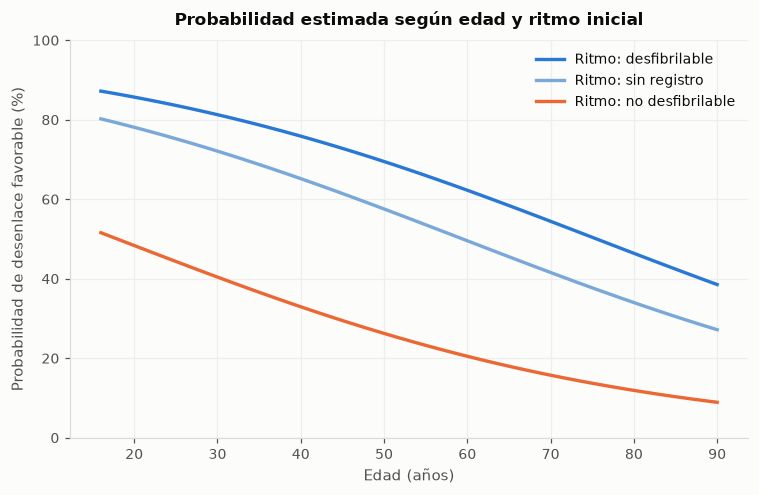

In [24]:
modelo = m4

edades = np.linspace(16, 90, 100)
ritmos = ['Desfibrilable', 'Sin registro', 'No desfibrilable']

perfil = pd.DataFrame({
    'edad':     np.tile(edades, 3),
    'ritmo':    np.repeat(ritmos, len(edades)),
    'rosc':     '1 Rápido',
    'ttm':      '33 °C',
    'hospital': 'A',
})
perfil['p'] = modelo.predict(perfil) * 100

fig, ax = plt.subplots(figsize=(7, 4.6))
for r, color in zip(ritmos, ['#2a78d6', '#7aa8d9', '#eb6834']):
    sub = perfil[perfil['ritmo'] == r]
    ax.plot(sub['edad'], sub['p'], color=color, linewidth=2.2, label=f'Ritmo: {r.lower()}')

ax.set_xlabel('Edad (años)')
ax.set_ylabel('Probabilidad de desenlace favorable (%)')
ax.set_title('Probabilidad estimada según edad y ritmo inicial', fontsize=11, pad=10)
ax.legend(frameon=False, fontsize=9)
ax.set_ylim(0, 100)
ax.grid(color='#eee', linewidth=.8)
ax.set_axisbelow(True)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Figura · Probabilidad estimada según edad y ritmo inicial**

La figura traduce los coeficientes del modelo final a la escala en que se toman las decisiones clínicas: probabilidades, no razones de momios. Cada curva corresponde a un valor de `Shockable Rhythm` y describe cómo varía la probabilidad de desenlace favorable a lo largo del rango de edad de la cohorte. Las tres fijan un mismo perfil de referencia (ROSC rápido, protocolo de 33 °C y Hospital A), de modo que la única diferencia entre ellas es el ritmo inicial.

**Lectura directa.** Para un paciente de 60 años, el modelo estima un 62 % de probabilidad de desenlace favorable si presentó ritmo desfibrilable y un 21 % si no lo presentó. A los 40 años, las cifras son 76 % y 33 %; a los 90, 39 % y 9 %.

| Edad | Ritmo desfibrilable | Ritmo no desfibrilable |
|---|---|---|
| 40 años | 76 % | 33 % |
| 60 años | 62 % | 21 % |
| 70 años | 55 % | 16 % |
| 90 años | 39 % | 9 % |

**Las curvas descienden en paralelo y no se cruzan en ningún punto del rango.** Esta propiedad es consecuencia directa de la especificación del modelo, que no incluye términos de interacción: el ritmo desplaza la curva completa sin alterar la pendiente de la edad. Interpretado clínicamente, el deterioro asociado al envejecimiento opera de forma equivalente en los tres grupos, que difieren en su punto de partida y no en su trayectoria.

**La separación horizontal ofrece la lectura más elocuente.** Un paciente de 16 años sin ritmo desfibrilable alcanza un 52 % de probabilidad estimada; esa misma cifra corresponde, en la curva del ritmo desfibrilable, a un paciente de aproximadamente 74 años. En términos pronósticos, la ausencia de ritmo desfibrilable equivale a un envejecimiento de casi seis décadas. Es la traducción intuitiva del OR de 0.16 estimado para esa variable.

**El aplanamiento progresivo de las curvas es una propiedad del modelo logístico.** La caída es pronunciada en el tramo intermedio y se atenúa conforme la probabilidad se aproxima a los extremos, dado que estos no pueden rebasarse. Un modelo lineal aplicado a la misma variable produciría predicciones fuera del intervalo [0, 1], y es precisamente esta restricción la que motiva el uso de la regresión logística.

**Alcance de la figura.** Las curvas representan estimaciones del modelo y no observaciones: ningún paciente concreto está graficado. Su validez depende del perfil de referencia fijado; variar el hospital o el tramo de ROSC desplazaría las tres curvas en bloque. Los extremos del eje horizontal descansan además sobre muy pocos casos (siete pacientes figuran con 90 años y son escasos los menores de 25), de modo que el tramo comprendido entre los 50 y los 75 años es el único sólidamente respaldado por los datos.

In [25]:
import numpy as np

NOMBRES = {
    'rosc[T.3 Prolongado]':      'ROSC >30 min (vs rápido)',
    'ritmo[T.No desfibrilable]': 'Ritmo no desfibrilable',
    'ttm[T.Sin TTM]':            'Sin manejo de temperatura',
    'rosc[T.2 Intermedio]':      'ROSC 11–30 min (vs rápido)',
    'ritmo[T.Sin registro]':     'Ritmo sin registro',
    'hospital[T.E]':             'Hospital E (vs A)',
    'ttm[T.36 °C]':              'TTM 36 °C (vs 33 °C)',
    'rosc[T.4 Sin dato]':        'ROSC sin dato (vs rápido)',
    'edad':                      'Edad (por año)',
    'hospital[T.B]':             'Hospital B (vs A)',
    'hospital[T.D]':             'Hospital D (vs A)',
    'hospital[T.F]':             'Hospital F (vs A)',
}

razones = pd.DataFrame({
    'OR':       np.exp(m4.params),
    'IC 2.5%':  np.exp(m4.conf_int()[0]),
    'IC 97.5%': np.exp(m4.conf_int()[1]),
    'p':        m4.pvalues,
}).drop('Intercept').sort_values('OR')

razones.index = [NOMBRES.get(i, i) for i in razones.index]
razones['significativo'] = np.where(razones['p'] < .05, 'sí', 'no')

print(razones.round(3).to_string())

                               OR  IC 2.5%  IC 97.5%      p significativo
ROSC >30 min (vs rápido)    0.136    0.053     0.346  0.000            sí
Ritmo no desfibrilable      0.156    0.100     0.244  0.000            sí
Sin manejo de temperatura   0.265    0.090     0.779  0.016            sí
ROSC 11–30 min (vs rápido)  0.357    0.182     0.700  0.003            sí
Ritmo sin registro          0.595    0.228     1.555  0.290            no
Hospital E (vs A)           0.832    0.253     2.740  0.763            no
TTM 36 °C (vs 33 °C)        0.898    0.422     1.911  0.780            no
ROSC sin dato (vs rápido)   0.933    0.315     2.762  0.900            no
Edad (por año)              0.968    0.956     0.981  0.000            sí
Hospital B (vs A)           1.472    0.473     4.580  0.505            no
Hospital D (vs A)           2.194    0.750     6.417  0.151            no
Hospital F (vs A)           8.013    1.635    39.276  0.010            sí


**Razones de momios del modelo final**

Los coeficientes que devuelve `smf.logit` están expresados en logaritmos de momios y no admiten lectura directa. Aplicarles la función exponencial los convierte en razones de momios (OR), que es la métrica con la que se reportan habitualmente los modelos logísticos en la literatura clínica. La misma transformación se aplica a los límites del intervalo de confianza.

Un OR de 1 indica ausencia de efecto. Por debajo de 1, la condición se asocia a menor probabilidad de desenlace favorable; por encima, a mayor. El criterio de significancia puede leerse directamente del intervalo: **si contiene el 1, el efecto no es distinguible del azar**, lo que equivale a la comprobación de que el intervalo del coeficiente original contenga el 0.

**Efectos significativos** — seis de las doce filas:

| Variable | OR | IC 95 % | *p* |
|---|---|---|---|
| ROSC >30 min (vs rápido) | 0.136 | 0.053 – 0.346 | < 0.001 |
| Ritmo no desfibrilable | 0.156 | 0.100 – 0.244 | < 0.001 |
| Sin manejo de temperatura | 0.265 | 0.090 – 0.779 | 0.016 |
| ROSC 11–30 min (vs rápido) | 0.357 | 0.182 – 0.700 | 0.003 |
| Edad (por año) | 0.968 | 0.956 – 0.981 | < 0.001 |
| Hospital F (vs A) | 8.013 | 1.635 – 39.276 | 0.010 |

Una reanimación prolongada reduce los momios de desenlace favorable a la séptima parte respecto de una rápida, y la ausencia de ritmo desfibrilable a la sexta parte. El tramo intermedio de reanimación los reduce a poco más de un tercio, de modo que los dos niveles de `ROSC_cat` dibujan un gradiente ordenado. La edad opera de forma continua y moderada: un 3.2 % menos de momios por cada año, equivalente a un 28 % por década.

**Efectos no concluyentes** — las seis filas restantes: ritmo sin registro (OR = 0.595), hospitales E (0.832), B (1.472) y D (2.194), protocolo de 36 °C (0.898) y ROSC sin dato (0.933). En todas ellas el intervalo de confianza contiene el 1.

**Dos resultados conviene destacar de esta tabla.**

El primero es `ROSC sin dato`, con OR = 0.933 y *p* = 0.900. El análisis de correlaciones le había asignado ρ = +0.186 con *p* = 3.8 × 10⁻⁶, una de las asociaciones más significativas de la sección 1.1. Ajustado por hospital, el efecto desaparece por completo. La verificación posterior mostró que el Hospital A no registra la variable en ninguno de sus 261 pacientes: ser del Hospital A y carecer de dato de ROSC no son dos condiciones correlacionadas sino la misma condición, y el modelo no puede atribuirle efecto propio a ninguna de las dos por separado.

El segundo es el `Hospital F`, cuyo OR de 8.013 se acompaña de un intervalo que abarca de 1.635 a 39.276. El efecto es positivo y estadísticamente significativo, pero su magnitud resulta tan imprecisa que la estimación puntual carece de valor informativo. Con 69 pacientes en ese centro, el modelo detecta que hay un efecto sin poder cuantificarlo. En las conclusiones se reporta como efecto positivo significativo, nunca como «ocho veces más momios».

**Precisión sobre la interpretación de un OR.** Una razón de momios no equivale a «cuántas veces más probable». Los pacientes con ritmo desfibrilable presentan un 55.2 % de desenlaces favorables frente al 17.3 % de los que no lo presentan —algo más del triple—, mientras que el OR correspondiente ronda el valor 6. Cuando el desenlace es frecuente, como ocurre en esta cohorte con un 37.1 %, el OR magnifica la diferencia respecto de lo que sugiere el lenguaje corriente. Por ese motivo los resultados se acompañan de las probabilidades estimadas siempre que resulta posible.

In [26]:
d = pd.DataFrame({
    'rosc_min': clinical['ROSC'],
    'edad':     clinical['Age'],
    'ritmo':    clinical['Shockable Rhythm'].astype(str).replace(
                    {'True': 'Desfibrilable', 'False': 'No desfibrilable',
                     'Desconocido': 'Sin registro'}),
    'hospital': clinical['Hospital'].astype(str),
}).dropna(subset=['rosc_min'])

print(f"Pacientes con dato de ROSC: {len(d)}")
print("\nDistribución por hospital:")
print(d['hospital'].value_counts().sort_index())

Pacientes con dato de ROSC: 303

Distribución por hospital:
hospital
B    120
D     61
E     72
F     50
Name: count, dtype: int64


**Regresión lineal simple**
¿la edad sola sirve para estimar el ROSC?

In [27]:
pend, interc, corr, p_valor, error_std = stats.linregress(d['edad'], d['rosc_min'])

print(f"n          = {len(d)}")
print(f"pendiente  = {pend:.4f} min por año")
print(f"intercepto = {interc:.4f}")
print(f"p-valor    = {p_valor:.4f}")
print(f"R²         = {corr**2:.4f}  →  la edad explica el {corr**2*100:.1f} % del ROSC")

n          = 303
pendiente  = -0.1332 min por año
intercepto = 31.3278
p-valor    = 0.0360
R²         = 0.0145  →  la edad explica el 1.5 % del ROSC


**Regresión lineal múltiple**  ¿La edad, ritmo y hospital sirven para estimar el ROSC?

In [28]:
ols = sm.OLS.from_formula("rosc_min ~ edad + ritmo + hospital", data=d).fit()

print(f"R² = {ols.rsquared:.4f}  →  todas las variables juntas explican "
      f"el {ols.rsquared*100:.1f} % del ROSC")
print(f"R² ajustado = {ols.rsquared_adj:.4f}")
print(f"F p-valor   = {ols.f_pvalue:.4g}")
print(f"\nReferencias: ritmo = {sorted(d['ritmo'].unique())[0]}  ·  "
      f"hospital = {sorted(d['hospital'].unique())[0]}")

ols.summary()

R² = 0.0655  →  todas las variables juntas explican el 6.5 % del ROSC
R² ajustado = 0.0497
F p-valor   = 0.001143

Referencias: ritmo = Desfibrilable  ·  hospital = B


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               rosc_min   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     4.161
Date:                Wed, 23 Sep 2026   Prob (F-statistic):            0.00114
Time:                        16:38:27   Log-Likelihood:                -1308.0
No. Observations:                 303   AIC:                             2628.
Df Residuals:                     297   BIC:                             2650.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    29.6230      4.270      6.937      0.000      21.219      38.027
ritmo[T.No desfibrilable]     0.1745      2.203      0.079      0.937      -4.161       4.510
hospital[T.D]                 7.0191      2.888      2.430      0.016       1.335      12.703
hospital[T.E]                -5.5502      2.756     -2.014      0.045     -10.974      -0.126
hospital[T.F]                -2.6834      3.101     -0.865      0.388      -8.785       3.419
edad                         -0.1011      0.063     -1.613      0.108      -0.224       0.022
==============================================================================
Omnibus:                      102.647   Durbin-Watson:                   2.161
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              263.180
Skew:                           1.611   Prob(JB):                     7.10e-58
Kurtosis:                       6.236   Cond. No.                         276.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Contraejemplo · ¿se puede estimar el tiempo hasta ROSC?**


**Modelo simple.** Sobre los 303 pacientes con dato, la edad arroja una pendiente de −0.133 minutos por año (*p* = 0.036) y un R² de 0.0145: explica el **1.5 %** de la variabilidad del tiempo de reanimación.

**Modelo múltiple.** Incorporando el ritmo inicial y el hospital, el R² asciende a 0.0655 (el **6.5 %**), con un R² ajustado de 0.0497 y un contraste global significativo (F *p* = 0.0011). La caída del R² al ajustarlo por el número de parámetros indica que una fracción de ese 6.5 % procede simplemente de haber incorporado cinco predictores.

Esta aparente contradicción resulta instructiva: el p-valor y el coeficiente de determinación responden preguntas distintas. El primero establece si existe alguna relación; el segundo, cuánta. Con 303 observaciones, una asociación de magnitud mínima alcanza significancia estadística sin que ello la vuelva aprovechable. Traducido a la escala original, entre un paciente de 30 años y uno de 80 el modelo predice una diferencia de 6.7 minutos, mientras que los valores observados abarcan de 1 a 111 minutos.

**A la limitación estadística se suma una de cobertura.** El modelo descansa sobre 303 pacientes de cuatro centros, y su categoría de referencia es el Hospital B porque el Hospital A no aporta un solo caso: no registra la variable en ninguno de sus 261 pacientes. El modelo describe, por tanto, a una submuestra que excluye al 43 % de la cohorte y al centro de mayor volumen.

**Conclusión.** El tiempo hasta la recuperación de la circulación no es estimable a partir de las variables disponibles. Este resultado respalda la decisión adoptada en la fase 3 de conservar `ROSC_cat` para los análisis sobre la cohorte completa y reservar la versión en minutos para descripciones restringidas al subconjunto con dato.

### Síntesis de la sección 1.2

**¿Es posible realizar un análisis de regresiones a partir de las correlaciones identificadas?**

Sí para la variable de interés principal, y la propia sección permite precisar para cuál no.

El análisis de correlaciones dejó al menos un predictor con asociación apreciable, el ritmo desfibrilable, con ρ = +0.368— y dos de magnitud moderada: la edad, con −0.215, y el tiempo de reanimación, con −0.143. Ese material basta para construir un modelo de la variable `Outcome`. Dado que la respuesta es binaria, el modelo apropiado es la **regresión logística**: una regresión lineal sobre una variable codificada como 0 y 1 puede devolver predicciones fuera del intervalo [0, 1], que no admiten lectura como probabilidad.

El modelo resultante es globalmente significativo (LLR *p* = 6.5 × 10⁻²⁶) y alcanza un pseudo R² de 0.187, con seis coeficientes significativos sobre doce estimados. La reanimación prolongada (OR = 0.136), el ritmo no desfibrilable (OR = 0.156), la ausencia de manejo térmico (OR = 0.265), la reanimación de duración intermedia (OR = 0.357) y la edad (OR = 0.968 por año) se asocian a menor probabilidad de desenlace favorable; el Hospital F, a mayor (OR = 8.013).

No ocurre lo mismo con el tiempo hasta la recuperación de la circulación. La correlación entre `ROSC` y la edad es de −0.124, y el modelo lineal correspondiente alcanza un R² de **0.0145**, de modo que la edad explica apenas el **1.5 %** de su variabilidad. Ampliando el modelo con el ritmo inicial y el hospital, el R² asciende únicamente a **0.0655** un 6.5 %, que desciende a 0.0497 al ajustarlo por el número de parámetros. Ninguna combinación de las variables disponibles permite estimar esa magnitud con utilidad práctica. Ambos modelos alcanzan no obstante significancia estadística: *p* = 0.036 el simple y F *p* = 0.0011 el múltiple. Conviene explicitar por qué eso no los vuelve aprovechables, dado que el p-valor y el coeficiente de determinación responden preguntas diferentes. El p-valor establece si existe alguna relación; el R², cuánta. El primero depende además del tamaño de muestra, de modo que con 303 observaciones una asociación de magnitud mínima resulta detectable con seguridad sin que su capacidad predictiva lo sea. En la escala original, el modelo predice una diferencia de 6.7 minutos entre un paciente de 30 años y uno de 80, sobre valores observados que abarcan de 1 a 111 minutos.


A esa limitación estadística se suma una de cobertura que resulta más severa. De los 607 pacientes de la cohorte, solo 303 tienen registrado el tiempo de reanimación, y ninguno de ellos pertenece al Hospital A: ese centro no consigna la variable en ninguno de sus 261 casos. El modelo lineal describe, por tanto, a cuatro de los cinco centros y excluye al 43 % de la cohorte.

| Hospital | Pacientes | Con dato de ROSC | Cobertura |
|---|---|---|---|
| A | 261 | 0 | 0 % |
| B | 120 | 120 | 100 % |
| D | 83 | 61 | 73 % |
| E | 74 | 72 | 97 % |
| F | 69 | 50 | 72 % |

La respuesta completa a la pregunta es entonces que **sí es posible estimar el desenlace neurológico, y no lo es estimar el tiempo de reanimación**. Incluir ambos resultados es deliberado: la selección de qué modelar constituye una decisión metodológica, y reportar únicamente el caso favorable la presentaría como una inercia.

---

**¿Qué variables se seleccionaron y cómo se eligieron en función de los objetivos del proyecto?**

La selección siguió tres etapas, cada una con un criterio propio.

**Primera etapa — qué puede entrar.** El análisis de correlaciones descartó cuatro de las once variables disponibles, por razones distintas entre sí: `Outcome` es la variable respuesta y no un predictor; `CPC` resultó redundante con ella (ρ = −0.949), puesto que el desenlace se define agrupando sus niveles; `ROSC` en minutos quedó excluida por cobertura insuficiente en favor de `ROSC_cat`, que cubre la cohorte completa; y `TTM` numérica, por duplicación con `TTM_cat`, que la representa sin pérdida y añade el grupo sin manejo térmico. Quedaron siete variables candidatas: `Age`, `Sex`, `OHCA`, `Shockable Rhythm`, `ROSC_cat`, `TTM_cat` y `Hospital`.

Ninguna se descartó por colinealidad entre predictores. Las diez asociaciones fuertes detectadas en el análisis de redundancias correspondían a redundancia con la respuesta o a confusión con el centro, y la confusión no se resuelve eliminando variables sino controlando por ellas.

**Segunda etapa — qué aporta cada una.** Los modelos se construyeron de forma incremental. El propósito no era únicamente llegar al modelo final, sino observar cómo se comporta cada coeficiente al incorporar los demás.

| Modelo | Variables | Pseudo R² | Parámetros |
|---|---|---|---|
| 1 | Solo el ritmo | 0.116 | 2 |
| 2 | Las seis clínicas | 0.173 | 11 |
| 3 | Añade el hospital | 0.191 | 15 |
| 4 | Sin sexo ni lugar del paro | 0.187 | 12 |

Esa progresión reveló dos cambios de veredicto que un modelo único habría ocultado. La ausencia de manejo térmico no mostraba asociación alguna en el modelo 2 (*p* = 0.901) y resultó significativa al incorporar el centro (*p* = 0.012): el Hospital F concentra los casos sin TTM y su ventaja institucional compensaba la desventaja del protocolo. En sentido inverso, la ausencia de dato de ROSC exhibía una asociación marcada en el análisis de correlaciones (*p* = 3.8 × 10⁻⁶) y se desvaneció bajo el mismo ajuste (OR = 0.933, *p* = 0.900). Reportar solo las correlaciones habría llevado a afirmar que el manejo térmico es irrelevante y que no registrar el tiempo de reanimación constituye un buen signo pronóstico.

### **1.3. Estadística inferencial**
---

- ¿Resulta pertinente calcular intervalos de confianza para estimar algún parámetro con confianza a partir de una muestra?
- ¿Es posible realizar pruebas de hipótesis para probar alguna teoría sobre un parámetro de la población?



Las secciones anteriores describieron lo que ocurre **en estos 607 pacientes**.
La estadística inferencial responde una pregunta distinta: qué puede afirmarse,
y con cuánta confianza, sobre la población de la que provienen.

Siguiendo el material de la asignatura, se abordan los dos propósitos de esta

### Alcance de la inferencia

Los 607 pacientes no constituyen una muestra aleatoria de una población general.
Corresponden al conjunto público de entrenamiento del George B. Moody PhysioNet
Challenge 2023, procedentes de cinco identificadores de hospital de un consorcio
de siete centros académicos, y sujetos a criterios de inclusión específicos:
paro cardíaco con recuperación de circulación espontánea, coma persistente y
puntuación en la Escala de Coma de Glasgow igual o inferior a 8.

Las estimaciones que siguen se refieren, por tanto, a la población de pacientes
comatosos post-paro atendidos en centros académicos con monitorización
electroencefalográfica continua. Su extrapolación a la población general de
pacientes con paro cardíaco no está respaldada por este diseño muestral.

### ¿Resulta pertinente calcular intervalos de confianza para estimar algún parámetro a partir de una muestra?

Sí. El conjunto permite estimar dos tipos de parámetro poblacional: la **media**
de una variable continua y la **proporción** de una categoría.

Un intervalo de confianza se construye como la estimación del parámetro más o
menos un margen de error, donde ese margen depende del nivel de confianza
elegido y del error estándar de la estimación. Se trabaja con un nivel de
confianza del 95 %, equivalente a una significancia de α = 0.05.

Se estima en primer lugar la **edad media** de cada grupo de desenlace. Al
desconocerse la desviación estándar poblacional, se emplea la distribución t de
Student.

In [29]:
fav   = (clinical["Outcome"].astype(str) == "Good")
ritmo = clinical["Shockable Rhythm"].astype(str)

edad_fav  = clinical.loc[fav,  "Age"].dropna().to_numpy()
edad_desf = clinical.loc[~fav, "Age"].dropna().to_numpy()

print("Edad media según desenlace — IC 95 % (distribución t de Student)\n")
for nombre, x in [("Favorable   ", edad_fav), ("Desfavorable", edad_desf)]:
    limite_inferior, limite_superior = sm.stats.DescrStatsW(x).tconfint_mean(alpha=0.05)
    print(f"  {nombre}: media = {x.mean():5.2f} años   "
          f"IC 95 % = ({limite_inferior:.2f}, {limite_superior:.2f})   n = {len(x)}")

Edad media según desenlace — IC 95 % (distribución t de Student)

  Favorable   : media = 57.57 años   IC 95 % = (55.77, 59.38)   n = 225
  Desfavorable: media = 63.29 años   IC 95 % = (61.65, 64.93)   n = 382


La edad media estimada es de **57.57 años** en el grupo de desenlace favorable,
con un intervalo de confianza del 95 % de (55.77, 59.38), y de **63.29 años** en
el grupo desfavorable, con intervalo (61.65, 64.93). La diferencia entre ambas
medias es de 5.72 años.

**Los dos intervalos no se superponen.** El límite superior del grupo favorable
(59.38 años) queda por debajo del límite inferior del grupo desfavorable
(61.65 años), con una separación de más de dos años. Esta ausencia de
superposición constituye evidencia de que la diferencia observada no es
atribuible a variabilidad muestral, y anticipa el resultado de la prueba de
hipótesis que se presenta más adelante.

La interpretación correcta de estos intervalos es la siguiente: si el proceso de
muestreo se repitiera un número elevado de veces, el 95 % de los intervalos
construidos de esta forma contendría la verdadera edad media poblacional. **No**
corresponde afirmar que exista una probabilidad del 95 % de que el parámetro se
encuentre dentro del intervalo calculado.

Se estima a continuación la **proporción de desenlace favorable**, primero en la
cohorte completa y luego dentro de cada categoría de ritmo inicial.

In [30]:
print("Proporción de desenlace favorable — IC 95 % (aproximación normal)\n")

k, N = int(fav.sum()), len(fav)
limite_inferior, limite_superior = sm.stats.proportion_confint(k, N)
print(f"  Cohorte completa: {k}/{N} = {k/N:.2%}   "
      f"IC 95 % = ({limite_inferior:.2%}, {limite_superior:.2%})\n")

for etiqueta, mascara in [("Desfibrilable   ", ritmo == "True"),
                          ("No desfibrilable", ritmo == "False"),
                          ("Sin registro    ", ritmo == "Desconocido")]:
    kk, nn = int(fav[mascara].sum()), int(mascara.sum())
    li, ls = sm.stats.proportion_confint(kk, nn)
    print(f"  {etiqueta}: {kk:3d}/{nn:3d} = {kk/nn:6.2%}   "
          f"IC 95 % = ({li:.2%}, {ls:.2%})   ancho = {(ls-li)*100:5.2f} puntos")

Proporción de desenlace favorable — IC 95 % (aproximación normal)

  Cohorte completa: 225/607 = 37.07%   IC 95 % = (33.23%, 40.91%)

  Desfibrilable   : 164/297 = 55.22%   IC 95 % = (49.56%, 60.87%)   ancho = 11.31 puntos
  No desfibrilable:  48/278 = 17.27%   IC 95 % = (12.82%, 21.71%)   ancho =  8.89 puntos
  Sin registro    :  13/ 32 = 40.62%   IC 95 % = (23.61%, 57.64%)   ancho = 34.03 puntos


La proporción de desenlace favorable en la cohorte es de **37.07 %** (225 de 607
pacientes), con un intervalo de confianza del 95 % de (33.23 %, 40.91 %). La
amplitud del intervalo, de 7.7 puntos porcentuales, refleja la precisión que
permite un tamaño de muestra de 607 observaciones.

Los intervalos por categoría de ritmo inicial permiten tres lecturas.

**La separación entre ritmo desfibrilable y no desfibrilable es inequívoca.** El
primer grupo estima 55.22 % (IC 49.56 %–60.87 %) y el segundo 17.27 %
(IC 12.82 %–21.71 %). Entre el límite inferior del primero y el límite superior
del segundo median casi 28 puntos porcentuales sin superposición alguna. La
diferencia no admite explicación por azar muestral.


**La amplitud del intervalo es tan informativa como su posición.** Este
contraste ilustra por qué la estimación puntual resulta insuficiente sin su
margen de error: dos proporciones aparentemente comparables (37.07 % y 40.62 %)
están respaldadas por cantidades de evidencia radicalmente distintas.




### ¿Es posible realizar pruebas de hipótesis para probar alguna teoría sobre un parámetro de la población?

Sí. Se plantean dos contrastes, cada uno con su hipótesis nula y alternativa,
sobre un nivel de significancia de α = 0.05.

La hipótesis nula representa la ausencia de diferencia. Las pruebas no permiten
demostrarla: únicamente permiten hallar evidencia suficiente para rechazarla en
favor de la alternativa. Un valor p inferior a α indica que el resultado
observado sería poco probable si la hipótesis nula fuera cierta.

Antes de aplicar las pruebas se verifican los supuestos que estas requieren.

Normalidad de la edad — prueba de Shapiro-Wilk
H0: los datos provienen de una distribución normal

  Favorable   : W = 0.9857   p = 2.362e-02   → se rechaza H0
  Desfavorable: W = 0.9472   p = 1.941e-10   → se rechaza H0

Homocedasticidad — prueba de Levene
H0: ambos grupos provienen de poblaciones con varianzas iguales

  W = 3.4530   p = 0.0636   → no se rechaza H0

Desviación estándar por grupo
  Favorable   : 13.76 años
  Desfavorable: 16.30 años

Pacientes consignados con edad 90 (censura por anonimización)
  Favorable   :   0 de 225
  Desfavorable:   7 de 382
Figura guardada en results/figures/qq_edad.png


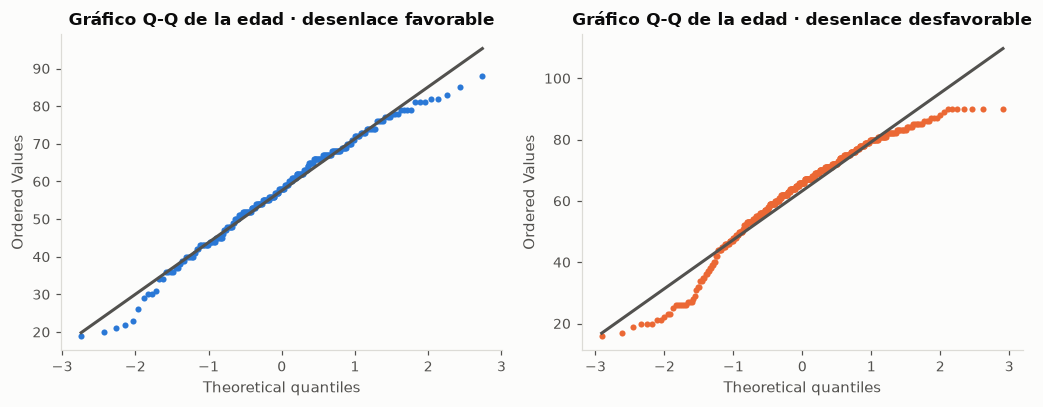

In [31]:
print("Normalidad de la edad — prueba de Shapiro-Wilk")
print("H0: los datos provienen de una distribución normal\n")
for nombre, x in [("Favorable   ", edad_fav), ("Desfavorable", edad_desf)]:
    w, p_valor = stats.shapiro(x)
    decision = "se rechaza H0" if p_valor < 0.05 else "no se rechaza H0"
    print(f"  {nombre}: W = {w:.4f}   p = {p_valor:.3e}   → {decision}")

print("\nHomocedasticidad — prueba de Levene")
print("H0: ambos grupos provienen de poblaciones con varianzas iguales\n")
lev, p_lev = stats.levene(edad_fav, edad_desf)
decision = "se rechaza H0" if p_lev < 0.05 else "no se rechaza H0"
print(f"  W = {lev:.4f}   p = {p_lev:.4f}   → {decision}")

print("\nDesviación estándar por grupo")
print(f"  Favorable   : {edad_fav.std(ddof=1):.2f} años")
print(f"  Desfavorable: {edad_desf.std(ddof=1):.2f} años")

print("\nPacientes consignados con edad 90 (censura por anonimización)")
for nombre, x in [("Favorable   ", edad_fav), ("Desfavorable", edad_desf)]:
    print(f"  {nombre}: {(x == 90).sum():3d} de {len(x)}")

fig, ejes = plt.subplots(1, 2, figsize=(9.5, 3.8))
for ax, (nombre, x) in zip(ejes, [("favorable", edad_fav), ("desfavorable", edad_desf)]):
    stats.probplot(x, plot=ax)
    ax.set_title(f"Gráfico Q-Q de la edad · desenlace {nombre}", fontsize=11)
    ax.get_lines()[0].set_markerfacecolor(FAVORABLE if nombre == "favorable" else DESFAVORABLE)
    ax.get_lines()[0].set_markeredgecolor("none")
    ax.get_lines()[0].set_markersize(4)
    ax.get_lines()[1].set_color(TINTA_2)
fig.tight_layout()
guardar(fig, "qq_edad")
plt.show()

**Normalidad.** La prueba de Shapiro-Wilk rechaza la normalidad en los dos
grupos, pero los dos rechazos no son equivalentes.

En el grupo favorable el valor p es 0.024, apenas por debajo del umbral de 0.05,
y el gráfico Q-Q muestra los puntos bien ajustados a la línea de referencia
salvo en los extremos. Con 225 observaciones la prueba resulta muy sensible y
detecta desviaciones pequeñas.

En el grupo desfavorable el valor p es 1.94 × 10⁻¹⁰, un rechazo mucho más
fuerte, y el gráfico Q-Q muestra por qué: los puntos más altos se alinean en
horizontal a la altura de 90. Esa forma aparece cuando muchos pacientes
comparten el mismo valor. Y lo comparten porque el conjunto fue anonimizado: la
documentación de PhysioNet indica que todo paciente mayor de 89 años se consigna
con edad 90.

El rechazo no indica entonces que la edad se distribuya de forma extraña, sino
que la variable está truncada en su extremo superior.

**Consecuencia para el análisis.** A los pacientes de mayor edad se les redujo
la edad registrada. El grupo desfavorable es el de mayor edad y, por tanto, el
más afectado. Su edad media real es superior a los 63.29 años estimados, y la
diferencia entre grupos es mayor que los 5.72 años observados. La estimación es
conservadora: el defecto del dato reduce la diferencia en lugar de exagerarla.

**Homocedasticidad.** La prueba de Levene arroja p = 0.0636, superior al umbral
de 0.05, por lo que no se rechaza la igualdad de varianzas. Se emplea en
consecuencia la versión con varianzas agrupadas de la prueba t.

**Validez de las pruebas.** El rechazo de la normalidad no invalida los
contrastes siguientes. La prueba z no exige que cada dato siga una distribución
normal, sino que la siga el promedio de la muestra, y el teorema del límite
central lo garantiza con 225 y 382 observaciones. La verificación de supuestos
cumplió aquí una función distinta de la prevista: no decidió qué prueba aplicar,
sino que permitió detectar la censura de la variable edad.

In [32]:
print("PRUEBA 1 — Diferencia de edad media entre grupos de desenlace")
print("  H0: μ_favorable = μ_desfavorable")
print("  Ha: μ_favorable ≠ μ_desfavorable   (dos colas, α = 0.05)\n")

print(f"  Media favorable   : {edad_fav.mean():.2f} años   (n = {len(edad_fav)})")
print(f"  Media desfavorable: {edad_desf.mean():.2f} años   (n = {len(edad_desf)})")
print(f"  Diferencia observada: {edad_fav.mean() - edad_desf.mean():.2f} años\n")

z_score, p_valor = sm.stats.ztest(edad_fav, edad_desf, value=0, alternative="two-sided")
print(f"  Prueba z:  estadístico = {z_score:.4f}   p = {p_valor:.4e}")

test, p_t, gl = sm.stats.ttest_ind(edad_fav, edad_desf)
print(f"  Prueba t:  estadístico = {test:.4f}   p = {p_t:.4e}   gl = {gl:.0f}")

print(f"\n  → {'Se rechaza H0' if p_valor < 0.05 else 'No se rechaza H0'}")

PRUEBA 1 — Diferencia de edad media entre grupos de desenlace
  H0: μ_favorable = μ_desfavorable
  Ha: μ_favorable ≠ μ_desfavorable   (dos colas, α = 0.05)

  Media favorable   : 57.57 años   (n = 225)
  Media desfavorable: 63.29 años   (n = 382)
  Diferencia observada: -5.72 años

  Prueba z:  estadístico = -4.4165   p = 1.0032e-05
  Prueba t:  estadístico = -4.4165   p = 1.1885e-05   gl = 605

  → Se rechaza H0


Como los dos grupos superan ampliamente las 30 observaciones, la prueba z es la
apropiada. Se reporta también la prueba t, que con tamaños de muestra así da
prácticamente lo mismo.

Ambas arrojan el **mismo estadístico, −4.4165**, con valores p de 1.00 × 10⁻⁵ la
prueba z y 1.19 × 10⁻⁵ la prueba t. Coinciden porque las dos calculan el error
estándar de la misma manera; lo único que cambia es la distribución que usan
para obtener el valor p, y con 605 grados de libertad esas dos distribuciones
son casi idénticas. La diferencia entre z y t solo se nota en muestras pequeñas.

El valor p queda muy por debajo de 0.05, de modo que **se rechaza la hipótesis
nula**. Los pacientes con desenlace favorable son más jóvenes: **5.72 años menos
en promedio**, con un intervalo de confianza del 95 % de 3.18 a 8.26 años.

Esa diferencia es, además, un mínimo. Como todas las edades superiores a 89 años
se registraron como 90, el grupo desfavorable (que es el de mayor edad) aparece
más joven de lo que realmente es. Sin esa censura la brecha sería más amplia.

El resultado coincide con lo observado antes por otras vías: los intervalos de
confianza de las dos edades medias no se superponen, el modelo logístico de la
sección 1.2 da OR = 0.968 por año (IC 95 % 0.956–0.981), y los diagramas de
cajas muestran la misma separación. Cuatro procedimientos distintos llegan a la
misma conclusión.

Ahora bien, que la diferencia sea significativa no implica que sirva para
predecir un caso individual. Las cajas se solapan bastante: la cohorte tiene
pacientes de casi noventa años con desenlace favorable y pacientes de menos de
veinte con desenlace desfavorable.

In [33]:
print("PRUEBA 2 — Diferencia de proporción de desenlace favorable según ritmo inicial")
print("  H0: p_desfibrilable = p_no_desfibrilable")
print("  Ha: p_desfibrilable ≠ p_no_desfibrilable   (dos colas, α = 0.05)\n")

k1, n1 = int(fav[ritmo == "True"].sum()),  int((ritmo == "True").sum())
k2, n2 = int(fav[ritmo == "False"].sum()), int((ritmo == "False").sum())
z_prop, p_prop = sm.stats.proportions_ztest([k1, k2], [n1, n2], alternative="two-sided")

print(f"  Desfibrilable:    {k1}/{n1} = {k1/n1:.2%}")
print(f"  No desfibrilable: {k2}/{n2} = {k2/n2:.2%}")
print(f"  Diferencia observada: {k1/n1 - k2/n2:.2%}\n")
print(f"  Prueba z:  estadístico = {z_prop:.4f}   p = {p_prop:.4e}")

print(f"\n  → {'Se rechaza H0' if p_prop < 0.05 else 'No se rechaza H0'}")

PRUEBA 2 — Diferencia de proporción de desenlace favorable según ritmo inicial
  H0: p_desfibrilable = p_no_desfibrilable
  Ha: p_desfibrilable ≠ p_no_desfibrilable   (dos colas, α = 0.05)

  Desfibrilable:    164/297 = 55.22%
  No desfibrilable: 48/278 = 17.27%
  Diferencia observada: 37.95%

  Prueba z:  estadístico = 9.4266   p = 4.2355e-21

  → Se rechaza H0


La prueba z para dos proporciones arroja un estadístico de **9.4266** con
**p = 4.24 × 10⁻²¹**, valor que se sitúa varios órdenes de magnitud por debajo
del nivel de significancia. **Se rechaza la hipótesis nula.**

Existe evidencia suficiente para afirmar que, en la población de referencia, la
proporción de desenlace favorable entre pacientes con ritmo inicial
desfibrilable difiere de la observada entre pacientes con ritmo no
desfibrilable. La diferencia estimada es de **37.95 puntos porcentuales**
(55.22 % frente a 17.27 %), la mayor separación producida por cualquier variable
del conjunto, y coincide con la amplitud calculada en el análisis descriptivo de
la sección 2.



## **2. Resultados y visualizaciones**

### **2.1. Visualizaciones Estáticas**
---

* Incluya gráficos y visualizaciones estáticas que sean relevantes para los datos analizados.
* Explique cada visualización y cómo contribuye a la comprensión de los resultados.

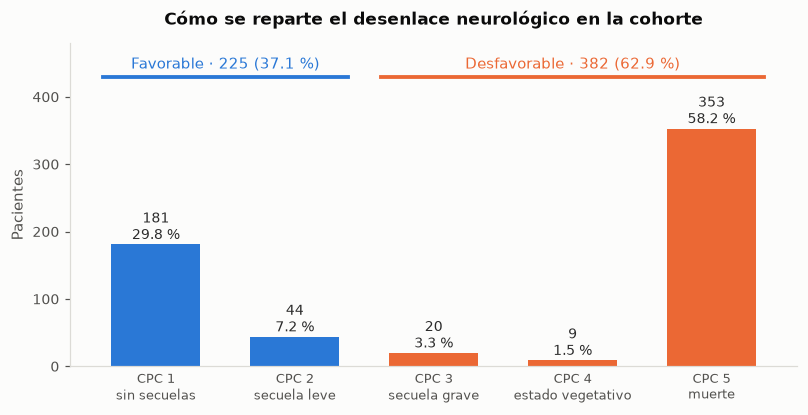

In [34]:


AZUL, NARANJA = '#2a78d6', '#eb6834'

conteo = cpc_reference['CPC'].value_counts().sort_index()
niveles = ['CPC 1\nsin secuelas', 'CPC 2\nsecuela leve', 'CPC 3\nsecuela grave',
           'CPC 4\nestado vegetativo', 'CPC 5\nmuerte']
N = len(clinical)

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(range(5), conteo.values, width=.64, color=[AZUL]*2 + [NARANJA]*3)

for i, v in enumerate(conteo.values):
    ax.text(i, v + 8, f'{v}\n{v/N*100:.1f} %', ha='center', fontsize=9, color='#2b2b2b')

favorables = conteo.iloc[:2].sum()
ax.plot([-.38, 1.38], [430, 430], color=AZUL, linewidth=2.5)
ax.text(.5, 442, f'Favorable · {favorables} ({favorables/N*100:.1f} %)',
        ha='center', fontsize=9.5, color=AZUL)
ax.plot([1.62, 4.38], [430, 430], color=NARANJA, linewidth=2.5)
ax.text(3, 442, f'Desfavorable · {N-favorables} ({(N-favorables)/N*100:.1f} %)',
        ha='center', fontsize=9.5, color=NARANJA)

ax.set_xticks(range(5), labels=niveles, fontsize=8.5)
ax.set_ylim(0, 480)
ax.set_ylabel('Pacientes')
ax.set_title('Cómo se reparte el desenlace neurológico en la cohorte', fontsize=11, pad=12)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.tick_params(axis='x', length=0)
fig.subplots_adjust(left=.10, right=.97, top=.86, bottom=.16)
plt.show()

Figura guardada en results/figures/composicion_desenlace.png


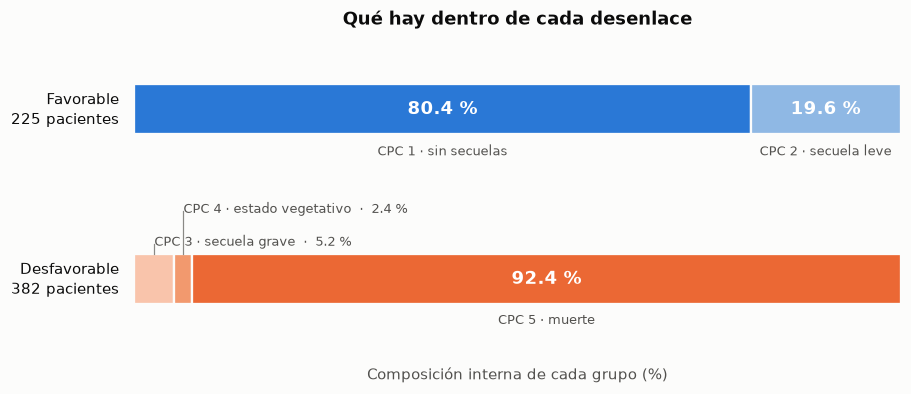

In [35]:
conteo = cpc_reference['CPC'].value_counts().sort_index()

GRUPOS = [
    (1.55, 'Favorable',    [(1, 'CPC 1 · sin secuelas',      FAVORABLE),
                            (2, 'CPC 2 · secuela leve',      '#8fb8e4')]),
    (0.00, 'Desfavorable', [(3, 'CPC 3 · secuela grave',     '#f9c4ab'),
                            (4, 'CPC 4 · estado vegetativo', '#f2996e'),
                            (5, 'CPC 5 · muerte',            DESFAVORABLE)]),
]

fig, ax = plt.subplots(figsize=(8.6, 4.3))

for y, nombre, niveles in GRUPOS:
    total = sum(conteo[k] for k, _, _ in niveles)
    izq, escalon = 0.0, 0
    for k, etiqueta, color in niveles:
        ancho = conteo[k] / total * 100
        ax.barh(y, ancho, left=izq, height=.46, color=color,
                edgecolor=SUPERFICIE, linewidth=1.5)
        if ancho >= 12:                       # cabe el rótulo dentro
            ax.text(izq + ancho / 2, y, f'{ancho:.1f} %', ha='center', va='center',
                    color='white', fontsize=12, fontweight='bold')
            ax.text(izq + ancho / 2, y - .32, etiqueta, ha='center', va='top',
                    color=TINTA_2, fontsize=8.5)
        else:                                 # segmento estrecho: rótulo fuera
            alto = .34 + .30 * escalon
            escalon += 1
            ax.plot([izq + ancho / 2] * 2, [y + .23, y + alto - .02],
                    color=TINTA_3, linewidth=.8)
            ax.text(izq + ancho / 2, y + alto, f'{etiqueta}  ·  {ancho:.1f} %',
                    ha='left', va='center', color=TINTA_2, fontsize=8.5)
        izq += ancho
    ax.text(-2, y, f'{nombre}\n{total} pacientes', ha='right', va='center',
            fontsize=10, color=TINTA, linespacing=1.4)

ax.set_xlim(0, 100)
ax.set_ylim(-.75, 2.10)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel('Composición interna de cada grupo (%)', labelpad=4)
ax.set_title('Qué hay dentro de cada desenlace', pad=16)
for s in ax.spines.values():
    s.set_visible(False)
fig.subplots_adjust(left=.17, right=.98, top=.82, bottom=.16)

guardar(fig, 'composicion_desenlace')
plt.show()

**¿Cómo se reparte el desenlace neurológico en la cohorte?**

La figura desglosa los 607 pacientes en los cinco niveles de la escala CPC, agrupados por color según la dicotomización que define la variable `Outcome`: los niveles 1 y 2 conforman el desenlace favorable y los niveles 3 a 5 el desfavorable.

**La distribución es marcadamente bimodal.** El 88 % de la cohorte se concentra en los dos extremos de la escala: 181 pacientes sin secuelas neurológicas (29.8 %) y 353 fallecidos (58.2 %). Los niveles intermedios están casi vacíos pues 20 pacientes con secuela grave y 9 en estado vegetativo.

**El desenlace desfavorable es, en la práctica, mortalidad.** De los 382 pacientes clasificados como desfavorables, 353 corresponden a fallecimientos: el **92.4 %**.

**La simetría se repite en el otro extremo.** De los 225 pacientes con desenlace favorable, 181 alcanzan el CPC 1: el **80.4 %** no presenta secuela alguna. Recuperarse en esta cohorte significa mayoritariamente recuperarse por completo.


Figura guardada en results/figures/centros_crudo_vs_ajustado.png


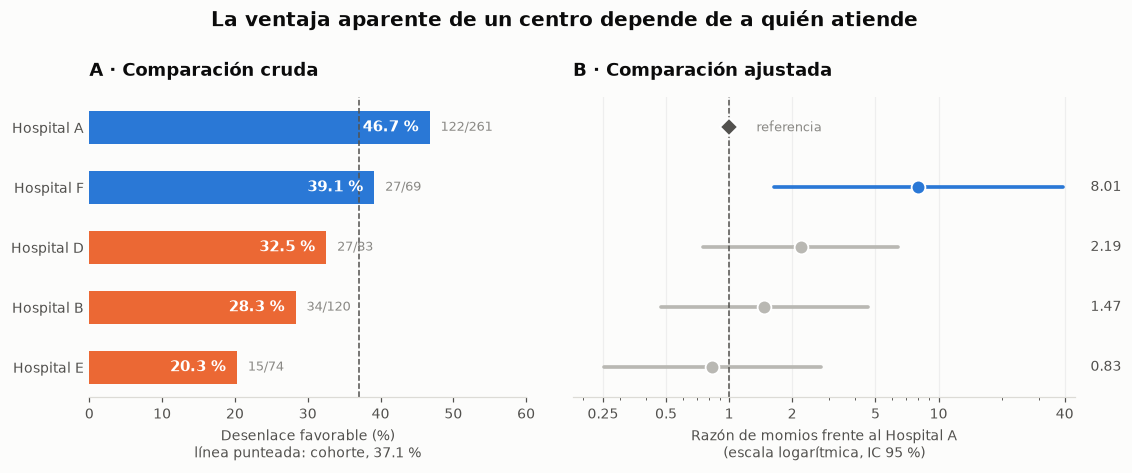

In [36]:
import numpy as np

media = (clinical['Outcome'] == 'Good').mean() * 100

# --- panel A: tasas crudas, ordenadas de mayor a menor -------------------
favorable = (clinical['Outcome'] == 'Good').astype(int)
crudo = pd.DataFrame({
    'fav': favorable.groupby(clinical['Hospital'], observed=True).sum(),
    'tot': favorable.groupby(clinical['Hospital'], observed=True).size(),
})
crudo['tasa'] = crudo['fav'] / crudo['tot'] * 100
crudo = crudo.sort_values('tasa', ascending=False)

# --- panel B: OR ajustados del modelo final ------------------------------
ic = m4.conf_int()
ajustado = pd.DataFrame(index=crudo.index, columns=['OR', 'lo', 'hi'], dtype=float)
for h in crudo.index:
    clave = f'hospital[T.{h}]'
    if clave in m4.params:
        ajustado.loc[h] = [np.exp(m4.params[clave]),
                           np.exp(ic.loc[clave, 0]), np.exp(ic.loc[clave, 1])]
REFERENCIA = crudo.index[~crudo.index.isin(
    [k.split('T.')[1][:-1] for k in m4.params.index if k.startswith('hospital')])][0]

y = np.arange(len(crudo))[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.8, 4.4), sharey=True,
                               gridspec_kw={'width_ratios': [1, 1.15], 'wspace': .10})

ax1.barh(y, crudo['tasa'], height=.55,
         color=[FAVORABLE if t >= media else DESFAVORABLE for t in crudo['tasa']])
ax1.axvline(media, color=TINTA_2, linestyle='--', linewidth=1)
for yi, (h, fila) in zip(y, crudo.iterrows()):
    ax1.text(fila['tasa'] - 1.5, yi, f"{fila['tasa']:.1f} %", ha='right', va='center',
             color='white', fontsize=10, fontweight='bold')
    ax1.text(fila['tasa'] + 1.5, yi, f"{int(fila['fav'])}/{int(fila['tot'])}",
             ha='left', va='center', color=TINTA_3, fontsize=8.5)
ax1.set_xlim(0, 60)
ax1.set_yticks(y, labels=[f'Hospital {h}' for h in crudo.index])
ax1.set_xlabel(f'Desenlace favorable (%)\nlínea punteada: cohorte, {media:.1f} %', fontsize=9)
ax1.set_title('A · Comparación cruda', pad=14, loc='left')
ax1.tick_params(axis='y', length=0)
ax1.spines['left'].set_visible(False)

for yi, h in zip(y, crudo.index):
    if h == REFERENCIA:
        ax2.plot(1, yi, 'D', color=TINTA_2, markersize=8,
                 markeredgecolor='white', markeredgewidth=1.2, zorder=3)
        ax2.text(1.35, yi, 'referencia', va='center', fontsize=8.5, color=TINTA_3)
        continue
    OR, lo, hi = ajustado.loc[h]
    color = FAVORABLE if (lo > 1 or hi < 1) else NEUTRO
    ax2.plot([lo, hi], [yi, yi], color=color, linewidth=2.4, solid_capstyle='round')
    ax2.plot(OR, yi, 'o', color=color, markersize=9,
             markeredgecolor='white', markeredgewidth=1.2, zorder=3)
    ax2.text(1.03, yi, f'{OR:.2f}', ha='left', va='center', fontsize=9,
             color=TINTA_2, transform=ax2.get_yaxis_transform())

ax2.axvline(1, color=TINTA_2, linestyle='--', linewidth=1)
ax2.set_xscale('log')
ax2.set_xlim(.18, 45)
ax2.set_xticks([0.25, 0.5, 1, 2, 5, 10, 40],
               labels=['0.25', '0.5', '1', '2', '5', '10', '40'])
ax2.set_xlabel(f'Razón de momios frente al Hospital {REFERENCIA}\n(escala logarítmica, IC 95 %)',
               fontsize=9)
ax2.set_title('B · Comparación ajustada', pad=14, loc='left')
ax2.tick_params(axis='y', length=0)
ax2.spines['left'].set_visible(False)
ax2.grid(axis='x', color='#eee', linewidth=.8)
ax2.set_axisbelow(True)

fig.suptitle('La ventaja aparente de un centro depende de a quién atiende',
             fontsize=13, fontweight='bold', y=1.0)
fig.subplots_adjust(left=.10, right=.93, top=.82, bottom=.20)

guardar(fig, 'centros_crudo_vs_ajustado')
plt.show()

¿Los centros obtienen resultados distintos?**

La figura muestra la proporción de desenlaces favorables en cada hospital, ordenada de mayor a menor, con la media de la cohorte como línea de referencia (225 favorables sobre 607 pacientes = 37.07 %). Bajo cada barra aparece el número de casos favorables sobre el total del centro, porque los denominadores difieren de forma considerable (261 pacientes en el Hospital A frente a 69 en el F).

**La diferencia observada es amplia.** El Hospital A alcanza un 46.7 % de desenlaces favorables y el E un 20.3 %: más del doble entre el primero y el último. Los hospitales A y F se sitúan por encima de la media de la cohorte, y D, B y E por debajo.

**La lectura inmediata sería incorrecta.** Un lector podría concluir que el Hospital A atiende mejor a sus pacientes que el E. Los resultados de la sección 1.2 no respaldan esa interpretación: al ajustar por edad, ritmo inicial, tiempo de reanimación y protocolo térmico, el Hospital E obtiene un OR de 0.832 frente al A, con *p* = 0.763 y un intervalo de confianza de 0.253 a 2.740. La diferencia estimada pasa a ser mínima, el p-valor muestra que el azar la produciría con facilidad, y el intervalo contiene el 1 con tal amplitud que ni siquiera permite establecer en qué dirección va el efecto. Los 26 puntos porcentuales que separaban a ambos centros en la comparación cruda se disuelven al igualar las condiciones clínicas de los pacientes: la desventaja aparente no procedía de la atención prestada, sino de la composición de su casuística.

La conclusión es que la brecha observada en la figura desaparece al igualar las condiciones clínicas de los pacientes. La desventaja aparente del Hospital E no procedía de la atención prestada, sino de la composición de su casuística.

**El ajuste llega incluso a invertir el orden.** El Hospital F ocupa el segundo puesto en la comparación cruda, con un 39.1 % frente al 46.7 % del A. En el modelo ajustado es el único centro con un coeficiente significativo, y en sentido favorable: OR = 8.01 (IC 95 % 1.63–39.28; *p* = 0.010). Atiende a pacientes con peor perfil de partida, de modo que una tasa cruda ligeramente inferior corresponde, una vez igualadas las condiciones clínicas, a un resultado superior. La amplitud del intervalo obliga no obstante a la cautela: con 69 pacientes, el modelo detecta el efecto sin poder cuantificarlo con precisión.

**Qué aporta esta figura al conjunto.** Documenta que existe heterogeneidad institucional, que es la razón por la que `Hospital` se incorpora como variable de control en toda la sección 1.2. Y establece una advertencia que la figura siguiente desarrolla: **la comparación cruda de resultados entre centros no constituye una medida de calidad asistencial**, porque las poblaciones que atienden difieren y porque, como se verá, también difiere lo que cada uno registra.


conclusión del panel del Hospital vs Razon de momios
Cuatro de los cinco centros son indistinguibles entre sí una vez igualadas las condiciones clínicas de sus pacientes. La única diferencia que sobrevive al ajuste es la del Hospital F, y en sentido favorable pese a que en la comparación cruda quedaba por debajo del A.

#### **Las dos variables numéricas, separadas por desenlace**

La pregunta que responde: *¿difieren los pacientes con desenlace favorable y desfavorable en edad y en tiempo de reanimación, y cuánto se solapan sus distribuciones?*

Figura guardada en results/figures/fig1_numericas_por_desenlace.png


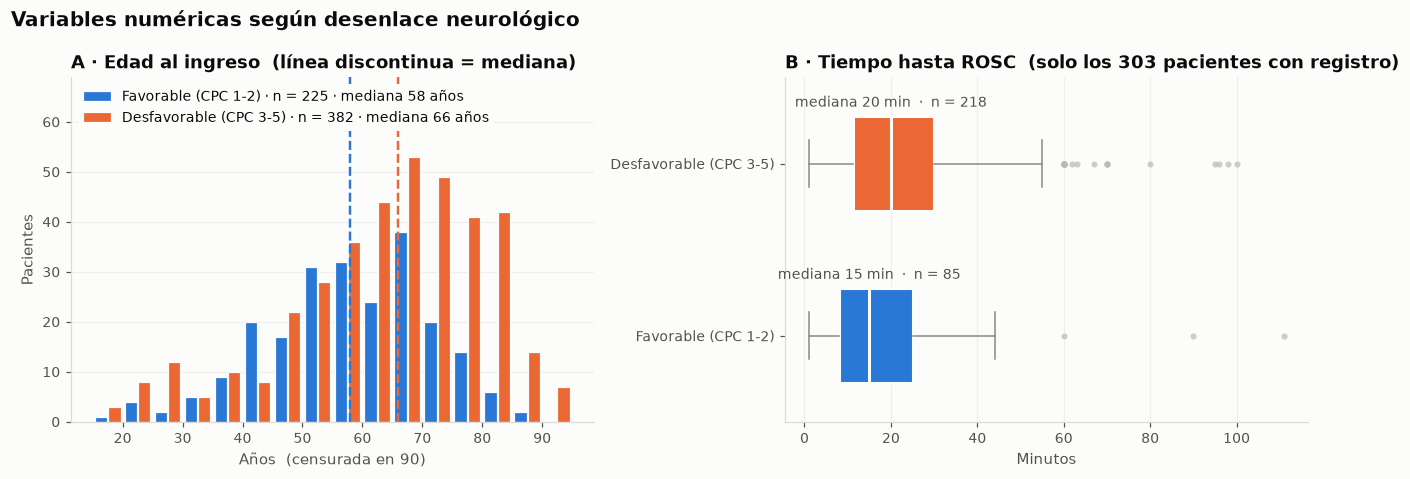

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# --- Panel A: edad -------------------------------------------------------
ax = axes[0]
bins = np.arange(15, 96, 5)
centros = (bins[:-1] + bins[1:]) / 2
ancho = 2.1   # deja un hueco del color de la superficie entre barras contiguas
maximo = 0
for grupo, desplaz in [("Good", -1.1), ("Poor", 1.1)]:
    serie = clinical.loc[clinical["Outcome"] == grupo, "Age"].dropna()
    conteos, _ = np.histogram(serie, bins=bins)
    maximo = max(maximo, conteos.max())
    # La mediana viaja en la leyenda para no competir con las barras por el espacio.
    ax.bar(centros + desplaz, conteos, width=ancho, color=COLOR_DESENLACE[grupo],
           label=f"{ETIQUETA_DESENLACE[grupo]} · n = {len(serie)} · "
                 f"mediana {serie.median():.0f} años",
           edgecolor=SUPERFICIE, linewidth=0.8)

ax.set_ylim(0, maximo * 1.30)
for grupo in ["Good", "Poor"]:
    ax.axvline(clinical.loc[clinical["Outcome"] == grupo, "Age"].median(),
               color=COLOR_DESENLACE[grupo], linestyle="--", linewidth=1.6)
ax.set_title("A · Edad al ingreso  (línea discontinua = mediana)", loc="left")
ax.set_xlabel("Años  (censurada en 90)")
ax.set_ylabel("Pacientes")
ax.legend(loc="upper left", frameon=True, framealpha=1,
          facecolor=SUPERFICIE, edgecolor="none")
ax.grid(axis="y", alpha=0.6)
ax.set_axisbelow(True)

# --- Panel B: tiempo hasta ROSC -----------------------------------------
ax = axes[1]
datos = [clinical.loc[(clinical["Outcome"] == g) & clinical["ROSC"].notna(), "ROSC"]
         for g in ["Good", "Poor"]]
partes = ax.boxplot(datos, vert=False, widths=0.55, patch_artist=True,
                    medianprops=dict(color=SUPERFICIE, linewidth=2),
                    flierprops=dict(marker="o", markersize=4, markerfacecolor=NEUTRO,
                                    markeredgecolor="none", alpha=0.7),
                    whiskerprops=dict(color=TINTA_3), capprops=dict(color=TINTA_3))
for caja, grupo in zip(partes["boxes"], ["Good", "Poor"]):
    caja.set_facecolor(COLOR_DESENLACE[grupo])
    caja.set_edgecolor(SUPERFICIE)
    caja.set_linewidth(2)
for i, (grupo, serie) in enumerate(zip(["Good", "Poor"], datos), start=1):
    ax.text(serie.median(), i + 0.33, f"mediana {serie.median():.0f} min  ·  n = {len(serie)}",
            ha="center", fontsize=9, color=TINTA_2)
ax.set_yticklabels([ETIQUETA_DESENLACE["Good"], ETIQUETA_DESENLACE["Poor"]])
ax.set_title("B · Tiempo hasta ROSC  (solo los 303 pacientes con registro)", loc="left")
ax.set_xlabel("Minutos")
ax.grid(axis="x", alpha=0.6)
ax.set_axisbelow(True)

fig.suptitle("Variables numéricas según desenlace neurológico",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
guardar(fig, "fig1_numericas_por_desenlace")
plt.show()

**Variables numéricas según desenlace neurológico**

**Panel A · Edad al ingreso**

Las dos distribuciones se desplazan en la dirección esperada: la mediana es de 58 años en el grupo favorable y de 66 en el desfavorable, ocho años de diferencia. El grupo favorable concentra su masa entre los 45 y los 65 años, mientras que el desfavorable la desplaza hacia el tramo de 60 a 85.

**El desplazamiento no equivale a separación.** Los dos histogramas se superponen en prácticamente todo su recorrido, y en la franja que va de los 55 a los 70 años ambos grupos están representados con frecuencias comparables. Esa superposición es la imagen de la correlación de ρ = −0.215 obtenida en la sección 1.1; un efecto real pero moderado, que sirve para caracterizar poblaciones y no para pronosticar a un paciente concreto. Es decir, conocer que un paciente tiene 62 años no permite anticipar su desenlace.

El extremo derecho del eje está censurado. Los pacientes que figuran con 90 años pueden tener más, puesto que ese valor se registró como «90 o más», de modo que la cola superior de ambas distribuciones aparece comprimida artificialmente.

**Panel B · Tiempo hasta ROSC**

La lectura es equivalente. La mediana es de 15 minutos en el grupo favorable y de 20 en el desfavorable, y las cajas se solapan en la mayor parte de su recorrido. Coincide con ρ = −0.143, la asociación más débil de las que resultaron significativas.

**Los valores atípicos se reparten de forma asimétrica.** El grupo desfavorable concentra una docena de reanimaciones superiores a los 60 minutos, que alcanzan los 100, frente a tres en el grupo favorable. Las reanimaciones muy prolongadas terminan casi siempre en desenlace desfavorable, pero son demasiado escasas para desplazar el coeficiente global.

**Este panel describe a 303 pacientes, no a la cohorte.** El propio gráfico lo hace evidente: de esos 303, solo 85 tuvieron desenlace favorable, es decir el **28.1 %**, frente al 37.1 % de la cohorte completa. La submuestra con dato de ROSC no es una muestra aleatoria sino un subconjunto sesgado, porque excluye por completo al Hospital A (hospital que no registra la variable en ninguno de sus 261 pacientes) y ese centro es justamente el de mejor tasa cruda de recuperación. La diferencia de nueve puntos entre el 28.1 % y el 37.1 % es la medida directa de ese sesgo.

**Lectura conjunta de ambos paneles**

Las dos variables se comportan igual: desplazan la distribución del grupo favorable hacia valores más bajos sin llegar a dividir los grupos. Ninguna de las dos, por sí sola, permite clasificar a un paciente. Esto explica por qué el modelo de la sección 1.2 no puede apoyarse en ellas y por qué el ritmo desfibrilable termina siendo la variable dominante.

La comparación entre paneles ilustra además una asimetría metodológica que conviene declarar. El panel A describe a los 607 pacientes de la cohorte; el panel B, únicamente a la mitad que tiene el dato, y esa mitad tiene peor pronóstico por razones ajenas a la clínica. Es el argumento que sostiene la decisión adoptada en la fase 3: `Age` se emplea en su forma numérica original, mientras que del tiempo de reanimación se usa `ROSC_cat` en los modelos sobre la cohorte completa, reservando la versión en minutos para descripciones restringidas a los 303 pacientes con registro.

#### **Estructura de asociación entre todas las variables**

La pregunta que responde: *¿qué variables comparten información, y cuáles de esas relaciones son hallazgos y cuáles artefactos del registro?*

Figura guardada en results/figures/pares_clasificados.png


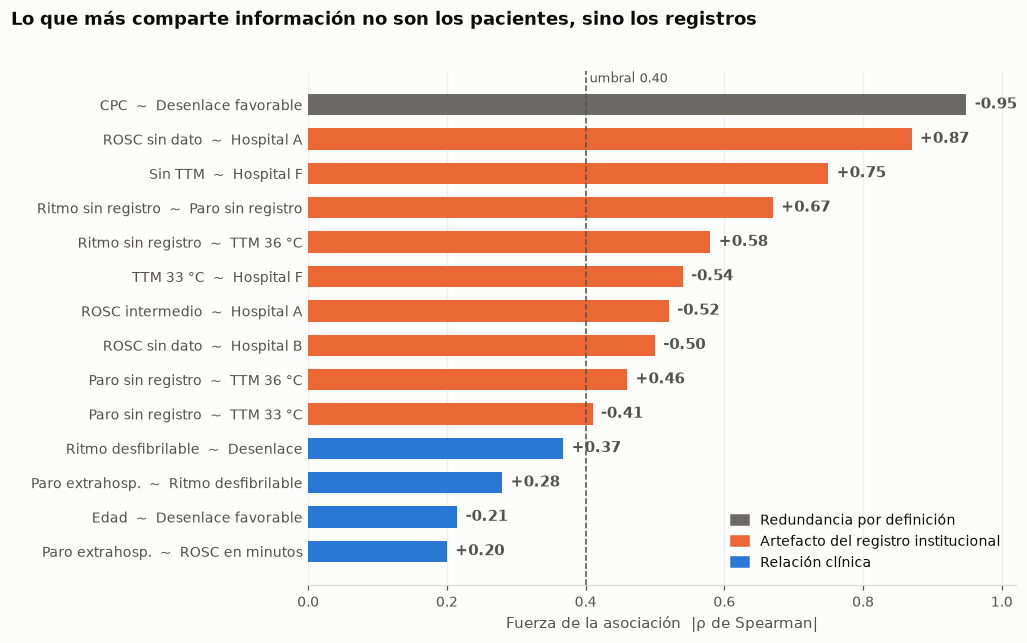

In [ ]:


DEFINICION = '#6b6a66'

# (etiqueta, rho, categoría)
PARES = [
    ('CPC  ~  Desenlace favorable',              -0.949, 'def'),
    ('ROSC sin dato  ~  Hospital A',             +0.870, 'art'),
    ('Sin TTM  ~  Hospital F',                   +0.750, 'art'),
    ('Ritmo sin registro  ~  Paro sin registro', +0.670, 'art'),
    ('Ritmo sin registro  ~  TTM 36 °C',         +0.580, 'art'),
    ('TTM 33 °C  ~  Hospital F',                 -0.540, 'art'),
    ('ROSC intermedio  ~  Hospital A',           -0.520, 'art'),
    ('ROSC sin dato  ~  Hospital B',             -0.500, 'art'),
    ('Paro sin registro  ~  TTM 36 °C',          +0.460, 'art'),
    ('Paro sin registro  ~  TTM 33 °C',          -0.410, 'art'),
    ('Ritmo desfibrilable  ~  Desenlace',        +0.368, 'cli'),
    ('Paro extrahosp.  ~  Ritmo desfibrilable',  +0.280, 'cli'),
    ('Edad  ~  Desenlace favorable',             -0.215, 'cli'),
    ('Paro extrahosp.  ~  ROSC en minutos',      +0.200, 'cli'),
]
COLOR = {'def': DEFINICION, 'art': DESFAVORABLE, 'cli': FAVORABLE}

PARES.sort(key=lambda p: abs(p[1]), reverse=True)
y = np.arange(len(PARES))[::-1]

fig, ax = plt.subplots(figsize=(9.6, 6.0))
ax.barh(y, [abs(p[1]) for p in PARES], height=.62,
        color=[COLOR[p[2]] for p in PARES])

for yi, (etiqueta, rho, cat) in zip(y, PARES):
    ax.text(abs(rho) + .012, yi, f'{rho:+.2f}', va='center',
            fontsize=9.5, color=TINTA_2, fontweight='bold')

ax.axvline(.40, color=TINTA_2, linestyle='--', linewidth=1, zorder=3)
ax.text(.40, len(PARES) - .35, ' umbral 0.40', fontsize=8.5, color=TINTA_2)

ax.set_yticks(y, labels=[p[0] for p in PARES], fontsize=9)
ax.set_xlim(0, 1.02)
ax.set_xlabel('Fuerza de la asociación  |ρ de Spearman|')
ax.set_title('Lo que más comparte información no son los pacientes, sino los registros',
             pad=30, loc='left', x=-.42)
ax.tick_params(axis='y', length=0)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', color='#eee', linewidth=.8)
ax.set_axisbelow(True)

ax.legend(handles=[Patch(color=DEFINICION, label='Redundancia por definición'),
                   Patch(color=DESFAVORABLE, label='Artefacto del registro institucional'),
                   Patch(color=FAVORABLE, label='Relación clínica')],
          loc='lower right', fontsize=9, handlelength=1.3, borderpad=.6)

fig.subplots_adjust(left=.30, right=.97, top=.88, bottom=.10)

guardar(fig, 'pares_clasificados')
plt.show()

**Pregunta · ¿Qué variables comparten información, y cuáles de esas relaciones son hallazgos y cuáles artefactos del registro?**

La figura resume la matriz de correlación de la sección 1.1 quedándose con las parejas que aportan algo. Las barras miden la fuerza de la asociación en valor absoluto, porque lo que se compara aquí es la intensidad y no la dirección; el signo aparece en la etiqueta de cada barra. Se excluyeron las parejas formadas por indicadoras de una misma variable de origen, que están correlacionadas por construcción al ser sus niveles excluyentes entre sí.

El color separa las tres naturalezas posibles de una asociación fuerte.

**Redundancia por definición.** Una sola pareja: `CPC` con `Desenlace favorable`, ρ = −0.949. No es un hallazgo sino una identidad, puesto que el desenlace se construye agrupando los niveles de CPC. Es la razón por la que esa variable queda fuera del modelo.

**Artefactos del registro institucional.** Nueve parejas, encabezadas por `ROSC sin dato` con `Hospital A` (+0.87) y `Sin TTM` con `Hospital F` (+0.75). Ninguna describe a los pacientes: describen qué registra cada centro y qué protocolo aplica. Las cuatro últimas del bloque merecen atención aparte, porque relacionan ausencias de dato entre sí —al paciente al que le falta el ritmo suele faltarle también el lugar del paro, con ρ = +0.67—. Si los registros se perdieran al azar, esas ausencias no coincidirían; que lo hagan confirma que la omisión es un atributo de la institución y no del caso.

**Relaciones clínicas.** Cuatro parejas, todas por debajo del umbral: el ritmo desfibrilable con el desenlace (+0.37), el paro extrahospitalario con el ritmo desfibrilable (+0.28), la edad con el desenlace (−0.21) y el paro extrahospitalario con el tiempo de reanimación (+0.20). Las dos intermedias van en la dirección que cabría esperar, ya que los paros ocurridos fuera del hospital se presentan con más frecuencia en ritmos tratables y tardan más en revertirse.

**El resultado que la figura hace evidente.** Todas las barras que superan el umbral de 0.40 son grises o naranjas; el azul aparece únicamente por debajo. **La asociación clínica más intensa de toda la matriz es más débil que cualquiera de las nueve parejas institucionales.** En estos datos, lo que con más fuerza comparte información no es la fisiología de los pacientes sino la forma en que cinco hospitales llevan sus registros.

De ahí se derivan las dos decisiones que sostienen el resto del análisis. `Hospital` se incorpora al modelo como variable de control, porque sin ese ajuste su efecto quedaría absorbido por los coeficientes clínicos. Y las categorías de ausencia de dato se conservan como niveles con nombre propio, conforme a lo decidido en la fase 3: eliminarlas o imputarlas habría borrado precisamente la señal que permite detectar el problema.

#### **Efectos ajustados del modelo logístico**

La pregunta que responde: *una vez controladas todas las variables entre sí, ¿cuáles conservan efecto y con qué precisión se conoce cada uno?*

Las razones de momios se representan en **escala logarítmica**, que es la escala natural de un efecto multiplicativo: en ella, duplicar y reducir a la mitad ocupan la misma distancia a cada lado de la línea de no efecto.

Figura guardada en results/figures/forest_modelo_final.png


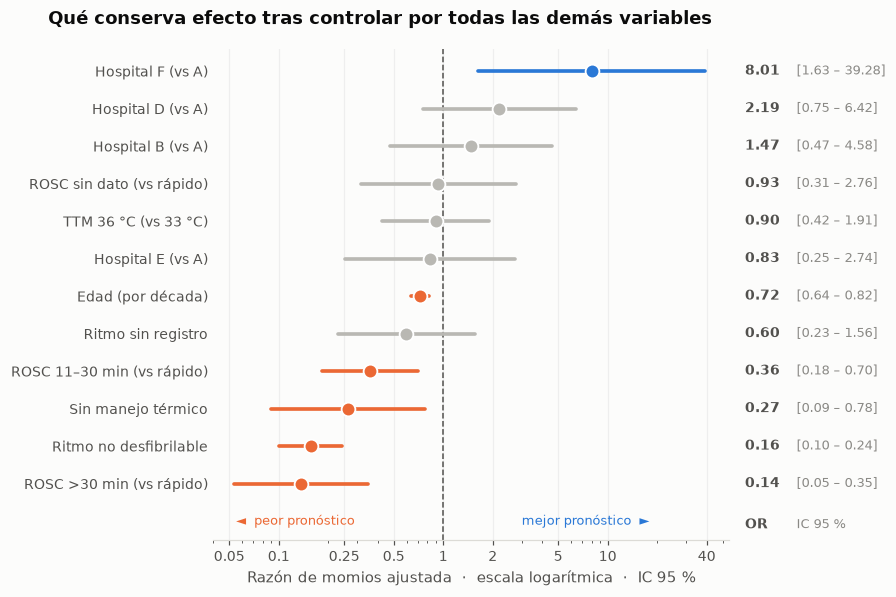

In [39]:
NOMBRES = {
    'hospital[T.F]':              'Hospital F (vs A)',
    'hospital[T.D]':              'Hospital D (vs A)',
    'hospital[T.B]':              'Hospital B (vs A)',
    'hospital[T.E]':              'Hospital E (vs A)',
    'rosc[T.4 Sin dato]':         'ROSC sin dato (vs rápido)',
    'rosc[T.2 Intermedio]':       'ROSC 11–30 min (vs rápido)',
    'rosc[T.3 Prolongado]':       'ROSC >30 min (vs rápido)',
    'ttm[T.36 °C]':               'TTM 36 °C (vs 33 °C)',
    'ttm[T.Sin TTM]':             'Sin manejo térmico',
    'ritmo[T.No desfibrilable]':  'Ritmo no desfibrilable',
    'ritmo[T.Sin registro]':      'Ritmo sin registro',
    'edad':                       'Edad (por década)',
}

coef, ic = m4.params.drop('Intercept'), m4.conf_int().drop('Intercept')
esc = lambda k: 10 if k == 'edad' else 1          # la edad, por década
filas = sorted(coef.index, key=lambda k: coef[k] * esc(k))

OR = np.exp([coef[k] * esc(k) for k in filas])
lo = np.exp([ic.loc[k, 0] * esc(k) for k in filas])
hi = np.exp([ic.loc[k, 1] * esc(k) for k in filas])
etiquetas = [NOMBRES.get(k, k) for k in filas]

fig, ax = plt.subplots(figsize=(9.2, 5.8))
yt, y = ax.get_yaxis_transform(), np.arange(len(filas))

for i in y:
    signif = lo[i] > 1 or hi[i] < 1
    color = NEUTRO if not signif else (FAVORABLE if OR[i] > 1 else DESFAVORABLE)
    ax.plot([lo[i], hi[i]], [i, i], color=color, linewidth=2.4,
            solid_capstyle='round', zorder=2)
    ax.plot(OR[i], i, 'o', color=color, markersize=9, zorder=3,
            markeredgecolor='white', markeredgewidth=1.2)
    ax.text(1.03, i, f'{OR[i]:.2f}', transform=yt, va='center',
            fontsize=9, color=TINTA_2, fontweight='bold')
    ax.text(1.13, i, f'[{lo[i]:.2f} – {hi[i]:.2f}]', transform=yt,
            va='center', fontsize=8.5, color=TINTA_3)

ax.axvline(1, color=TINTA_2, linestyle='--', linewidth=1, zorder=1)
ax.set_xscale('log')
ax.set_xlim(.04, 55)
ax.set_xticks([0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10, 40],
              labels=['0.05', '0.1', '0.25', '0.5', '1', '2', '5', '10', '40'])
ax.set_yticks(y, labels=etiquetas, fontsize=9)
ax.set_ylim(-1.5, len(filas) - .4)
ax.set_xlabel('Razón de momios ajustada  ·  escala logarítmica  ·  IC 95 %')
ax.set_title('Qué conserva efecto tras controlar por todas las demás variables',
             pad=16, loc='left', x=-.32)

ax.text(1.03, -1.1, 'OR', transform=yt, va='center', fontsize=9,
        color=TINTA_2, fontweight='bold')
ax.text(1.13, -1.1, 'IC 95 %', transform=yt, va='center', fontsize=8.5, color=TINTA_3)
ax.text(.055, -1.1, '◄  peor pronóstico', fontsize=8.5, color=DESFAVORABLE)
ax.text(3.0, -1.1, 'mejor pronóstico  ►', fontsize=8.5, color=FAVORABLE)

ax.tick_params(axis='y', length=0)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', color='#eee', linewidth=.8)
ax.set_axisbelow(True)
fig.subplots_adjust(left=.27, right=.78, top=.90, bottom=.13)

guardar(fig, 'forest_modelo_final')
plt.show()

**Pregunta · Una vez controladas todas las variables entre sí, ¿cuáles conservan efecto y con qué precisión se conoce cada uno?**

La figura presenta los doce coeficientes del modelo final convertidos a razones de momios. Cada punto es la estimación y cada línea su intervalo de confianza del 95 %; la vertical punteada marca el 1, es decir, la ausencia de efecto. Las líneas grises corresponden a los coeficientes cuyo intervalo cruza esa vertical, de modo que no puede afirmarse su dirección. El eje es logarítmico para que duplicar y reducir a la mitad ocupen la misma distancia desde el 1, y para que el valor del Hospital F no comprima contra el margen al resto de las estimaciones. La edad se expresa por década, no por año, para que su magnitud resulte comparable con la de las variables categóricas.

**Seis coeficientes conservan efecto.** Cuatro de ellos en sentido desfavorable: la reanimación prolongada (OR = 0.14), el ritmo no desfibrilable (0.16), la ausencia de manejo térmico (0.27) y la reanimación de duración intermedia (0.36). La edad los acompaña con un OR de 0.72 por década. En sentido favorable, únicamente el Hospital F, con 8.01.

**Seis no lo conservan.** Los hospitales D, B y E frente al A, el protocolo de 36 °C, el ritmo sin registrar y la ausencia de dato de ROSC. En todos ellos el intervalo contiene el 1.

**La precisión varía enormemente de una estimación a otra, y ahí está lo más informativo de la figura.**

En un extremo, la edad: su OR de 0.72 viene acompañado de un intervalo de 0.64 a 0.83, apenas perceptible en el gráfico. El efecto es moderado pero se conoce con gran exactitud, porque la edad está registrada en los 607 pacientes y varía de forma continua. Le sigue el ritmo no desfibrilable, con un intervalo de 0.10 a 0.24: efecto intenso y bien determinado, sostenido por 278 pacientes.

En el extremo opuesto, el Hospital F: su intervalo abarca de 1.63 a 39.29. Es significativo, puesto que no toca el 1, pero su amplitud impide cuantificar el efecto. Con 69 pacientes, el modelo detecta que hay algo sin poder precisar cuánto. **En las conclusiones debe reportarse como efecto positivo significativo y nunca como «ocho veces más momios».** Algo análogo ocurre con la ausencia de manejo térmico, cuyo intervalo va de 0.09 a 0.78.

**Una precaución sobre las dos últimas.** Los coeficientes del Hospital F y de la ausencia de manejo térmico deben interpretarse conjuntamente, dada su elevada correlación (ρ = +0.75 en el análisis de la sección 1.1). Para un paciente del Hospital F sin manejo térmico ambos se suman y resultan en un OR neto en torno a 2. Atribuir el 0.27 a un efecto clínico aislado del protocolo excedería lo que los datos permiten afirmar.

**Qué añade esta figura al resto de la sección.** Las figuras anteriores muestran asociaciones crudas, en las que cada variable aparece confundida con las demás. Esta es la única que muestra el efecto de cada una descontado el de todas las restantes, y es la que permite afirmar que el ritmo inicial y el tiempo de reanimación actúan por sí mismos, y no a través de la edad o del centro de atención.

Figura guardada en results/figures/ritmo_por_hospital.png


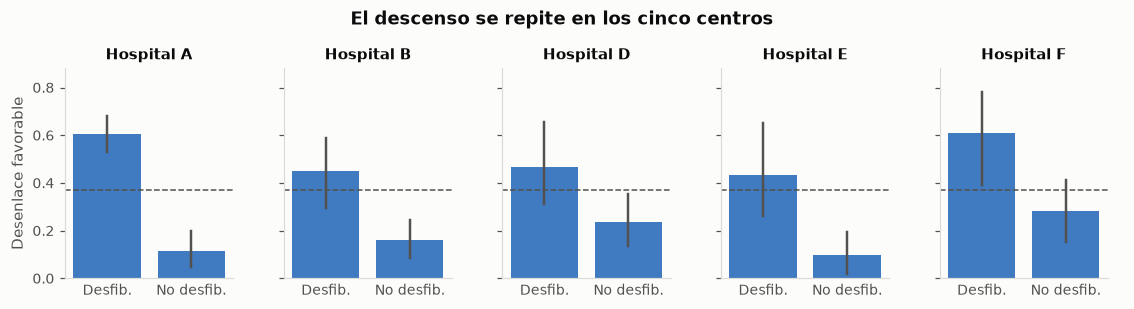

In [40]:
import seaborn as sns

datos = clinical.assign(
    favorable=(clinical['Outcome'] == 'Good').astype(int),
    ritmo=clinical['Shockable Rhythm'].astype(str).map(
        {'True': 'Desfib.', 'False': 'No desfib.'}),
).dropna(subset=['ritmo'])          # deja fuera los 32 sin registro

media = (clinical['Outcome'] == 'Good').mean()

g = sns.catplot(data=datos, x='ritmo', y='favorable', col='Hospital',
                kind='bar', errorbar=('ci', 95), order=['Desfib.', 'No desfib.'],
                color=FAVORABLE, height=3.1, aspect=.66, col_wrap=5,
                err_kws={'linewidth': 1.6, 'color': TINTA_2})

g.set_axis_labels('', 'Desenlace favorable')
g.set_titles('Hospital {col_name}')
for ax in g.axes.flat:
    ax.axhline(media, color=TINTA_2, linestyle='--', linewidth=1)
    ax.set_ylim(0, .88)
    ax.tick_params(axis='x', length=0)

g.figure.subplots_adjust(wspace=.30, top=.80)
g.figure.suptitle('El descenso se repite en los cinco centros',
                  y=.97, fontweight='bold', fontsize=12)

guardar(g.figure, 'ritmo_por_hospital')
plt.show()

¿El efecto del ritmo se repite en cada centro, o lo produce uno solo?**

Cada panel compara la tasa de desenlace favorable entre pacientes con ritmo desfibrilable y sin él, dentro de un mismo hospital. La línea punteada marca el 37.1 % de la cohorte completa, y las barras verticales son intervalos de confianza del 95 % obtenidos por bootstrap, de modo que su longitud refleja el número de pacientes que sostiene cada estimación.

Se excluye de la figura el nivel «sin registro» de ritmo. Sus 32 pacientes proceden en su totalidad del Hospital A, y por tanto no representa una condición clínica sino una práctica de registro de un único centro. Incluirlo habría añadido una barra a un solo panel y ninguna información comparable.

**El patrón se repite en los cinco centros sin excepción.** En todos ellos el ritmo desfibrilable se sitúa por encima de la media de la cohorte y el no desfibrilable por debajo, con tasas que van aproximadamente del 44 % al 61 % en el primer grupo y del 10 % al 29 % en el segundo. La magnitud de la diferencia varía, pero la dirección nunca se invierte.

**Esa consistencia es lo que aporta la figura.** Un efecto observado sobre la cohorte agregada podría, en principio, proceder de un único centro cuyo peso arrastrara al conjunto: si en cuatro hospitales no existiera diferencia y en uno fuera muy grande, el promedio global la mostraría igualmente. Los cinco paneles descartan esa posibilidad. El efecto del ritmo inicial se replica de forma independiente en cinco poblaciones distintas, atendidas por equipos distintos y con protocolos de registro distintos, lo que constituye una validación interna del hallazgo principal del análisis.

**Un apunte sobre la precisión.** Los intervalos del Hospital D y del F son notablemente más anchos, ya que esos centros aportan 83 y 69 pacientes frente a los 261 del A. En ambos el intervalo del ritmo desfibrilable roza o cruza la línea de la cohorte, de modo que la comparación individual en esos paneles no es concluyente por sí sola. Lo que sostiene la conclusión no es cada panel aislado, sino la coincidencia de los cinco.

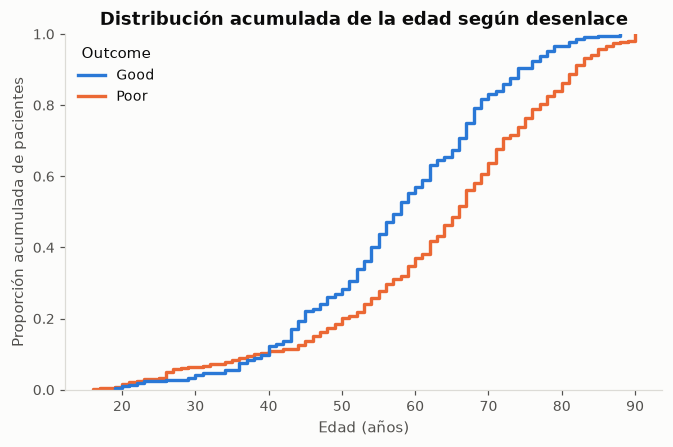

In [41]:
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.ecdfplot(data=datos, x='Age', hue='Outcome',
             palette={'Good': FAVORABLE, 'Poor': DESFAVORABLE}, linewidth=2.2, ax=ax)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Proporción acumulada de pacientes')
ax.set_title('Distribución acumulada de la edad según desenlace')
plt.show()

**Figura · Distribución acumulada de la edad según desenlace**

Cada curva indica, para una edad dada, qué proporción de su grupo tiene esa edad o menos. Se prefiere esta representación al histograma porque no exige elegir un ancho de intervalo: cada escalón corresponde a un paciente, y la comparación entre dos líneas resulta más directa que entre dos conjuntos de barras.

**La curva del grupo favorable discurre a la izquierda de la desfavorable en prácticamente todo el recorrido**, lo que equivale a decir que ese grupo es sistemáticamente más joven. La lectura en un punto concreto lo cuantifica: alrededor de los 60 años, cerca del 63 % de los pacientes con desenlace favorable ya han sido contabilizados, frente al 40 % de los desfavorables. Ambas curvas cruzan el 0.50 en los valores que la Tabla 1 reporta como medianas, 58 y 66 años respectivamente.

**La separación no es uniforme a lo largo del eje.** Por debajo de los 40 años las dos curvas se superponen, de modo que entre los pacientes jóvenes la edad no distingue el desenlace. Lo mismo ocurre por encima de los 85. La diferencia se concentra en la franja central, donde alcanza unos 23 puntos porcentuales de distancia vertical alrededor de los 60 años.

Esa distancia máxima entre dos distribuciones acumuladas es el estadístico D de Kolmogorov-Smirnov, de manera que la figura ofrece la representación gráfica de ese contraste. Un valor de esa magnitud describe distribuciones desplazadas pero ampliamente solapadas, en coincidencia con la correlación de ρ = −0.215 obtenida en la sección 1.1.

**Edad frente a tiempo de reanimación con ajuste lineal (`lmplot`)**

La pregunta que responde: *¿la relación entre las dos variables numéricas es la misma en ambos desenlaces?* Seaborn ajusta la recta y dibuja su banda de confianza del 95 %, uniendo en una sola figura el análisis de correlación de la sección 1.1 y el de regresión de la 1.2.

Figura guardada en results/figures/edad_rosc_por_desenlace.png


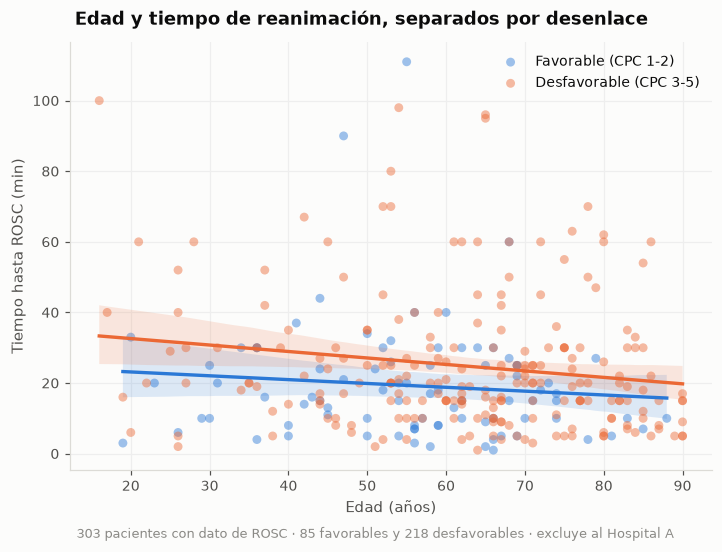

In [42]:
datos = clinical.assign(
    Desenlace=clinical['Outcome'].map(ETIQUETA_DESENLACE)
).dropna(subset=['ROSC'])

g = sns.lmplot(data=datos, x='Age', y='ROSC', hue='Desenlace',
               palette={ETIQUETA_DESENLACE['Good']: FAVORABLE,
                        ETIQUETA_DESENLACE['Poor']: DESFAVORABLE},
               height=4.6, aspect=1.45, ci=95,
               scatter_kws={'alpha': .45, 's': 34, 'edgecolor': 'none'},
               line_kws={'linewidth': 2.2},
               facet_kws={'despine': False, 'legend_out': False})

g.set_axis_labels('Edad (años)', 'Tiempo hasta ROSC (min)')
g.figure.suptitle('Edad y tiempo de reanimación, separados por desenlace',
                  y=1.03, fontweight='bold')
g.ax.legend(title='', loc='upper right', frameon=False)
g.ax.grid(color='#eee', linewidth=.8)
g.ax.set_axisbelow(True)

n_fav = (datos['Outcome'] == 'Good').sum()
g.ax.text(.01, -.16, f'303 pacientes con dato de ROSC · {n_fav} favorables y '
          f'{len(datos)-n_fav} desfavorables · excluye al Hospital A',
          transform=g.ax.transAxes, fontsize=8.5, color=TINTA_3)

guardar(g.figure, 'edad_rosc_por_desenlace')
plt.show()

**Figura · Edad y tiempo de reanimación, separados por desenlace**

Cada punto es un paciente de los 303 que tienen registrado el tiempo hasta ROSC, coloreado según su desenlace. Las rectas son ajustes lineales independientes para cada grupo, con su banda de confianza del 95 %.

**Las dos rectas discurren separadas a lo largo de todo el rango de edad.** La del grupo favorable se sitúa por debajo de la desfavorable tanto en los pacientes jóvenes como en los mayores, sin que lleguen a cruzarse. Ese paralelismo es el resultado de interés: **la diferencia en el tiempo de reanimación entre ambos desenlaces no se explica por la edad**. Si la ventaja del grupo favorable procediera únicamente de estar compuesto por pacientes más jóvenes, las rectas convergerían al avanzar el eje horizontal; lo que se observa es un desplazamiento vertical constante.

**Ambas pendientes son ligeramente descendentes**, en coincidencia con la correlación de −0.12 entre edad y ROSC, y lo son en la misma medida en los dos grupos. La edad influye poco sobre el tiempo de reanimación, y lo hace por igual con independencia del desenlace.

**Alcance de la figura.** Los grupos son muy desiguales: 85 pacientes favorables frente a 218 desfavorables, y esa proporción —un 28.1 % de desenlaces favorables— es inferior al 37.1 % de la cohorte. La razón es que el subconjunto con dato de ROSC excluye por completo al Hospital A, el centro con mejor tasa cruda de recuperación. Las bandas de confianza reflejan además esa desigualdad: la del grupo favorable es más ancha por descansar sobre menos casos. La figura describe, por tanto, a una submuestra sesgada por centro y no a la cohorte completa.

### **2.2. Visualizaciones Interactivas**
---

* Cree visualizaciones interactivas, como gráficos dinámicos o tableros interactivos y proporcione instrucciones claras sobre cómo interactuar con ellos.
* Explore cómo estas visualizaciones ayudan en la exploración de datos y documente su análisis.

Las tres visualizaciones siguientes usan **Plotly** y responden a preguntas que un gráfico estático no puede atender bien: seguir un subgrupo concreto a través de varias variables, aislar un centro del resto, o descender desde el total de la cohorte hasta un nivel individual de severidad.

> **Nota de reproducción.** Si el notebook se abre sin conexión, las figuras interactivas pueden no renderizarse porque la librería se carga desde CDN. Basta con volver a ejecutar las celdas de esta sección con conexión disponible.

In [ ]:


# ---------------------------------------------------------------------------
# Preparación · se convierte a texto porque Plotly no admite categóricas
# no ordenadas en el argumento 'path'
# ---------------------------------------------------------------------------
base = clinical.assign(
    Desenlace=clinical['Outcome'].astype(str).map(ETIQUETA_DESENLACE)
)

MAPA = {ETIQUETA_DESENLACE['Good']: FAVORABLE,
        ETIQUETA_DESENLACE['Poor']: DESFAVORABLE,
        '(?)': '#d9d8d3'}          # nodos intermedios del sunburst

# ---------------------------------------------------------------------------
# Figura interactiva · jerarquía hospital → tramo de ROSC → desenlace
# ---------------------------------------------------------------------------
jerarquia = (base.groupby(['Hospital', 'ROSC_cat', 'Desenlace'], observed=True)
             .size().reset_index(name='Pacientes')
             .astype({'Hospital': str, 'ROSC_cat': str, 'Desenlace': str}))

fig = px.sunburst(
    jerarquia,
    path=['Hospital', 'ROSC_cat', 'Desenlace'],
    values='Pacientes',
    color='Desenlace',
    color_discrete_map=MAPA,
    title='Del hospital al desenlace · haga clic en un anillo para profundizar',
)
fig.update_traces(
    hovertemplate='<b>%{label}</b><br>%{value} pacientes'
                  '<br>%{percentParent:.1%} de su nivel superior<extra></extra>')
fig.update_layout(width=720, height=620,
                  paper_bgcolor=SUPERFICIE, font=dict(size=12),
                  margin=dict(t=70, l=10, r=10, b=10))
fig.show()

print(f"{len(base)} pacientes · {jerarquia['Hospital'].nunique()} centros")

607 pacientes · 5 centros


**Interactivo · Del hospital al desenlace**

El anillo interior son los cinco centros, el intermedio el tramo de reanimación y el exterior el desenlace. El tamaño de cada sector es proporcional al número de pacientes.

**Cómo interactuar:** un clic sobre un hospital reorganiza el gráfico tomando ese centro como total; un clic en el círculo central devuelve a la vista completa; el cursor sobre cualquier sector muestra el número de pacientes y su porcentaje respecto del nivel superior.

**La figura hace visible el hallazgo central del análisis.** El anillo intermedio del Hospital A no está dividido: es un bloque único etiquetado «Sin dato». Ese centro no registra el tiempo de reanimación en ninguno de sus 261 pacientes, y como aporta el 43 % de la cohorte, su sector ocupa proporcionalmente ese espacio. El Hospital B presenta el comportamiento opuesto, con los tres tramos representados y ninguna ausencia. D y F ocupan posiciones intermedias.

**Las ausencias de dato no se distribuyen al azar entre centros: se concentran en uno solo.** Un patrón aleatorio produciría en los cinco hospitales sectores «Sin dato» de tamaño comparable. Lo que se observa es una división nítida entre centros que registran la variable y uno que no la registra nunca.

**La consecuencia se aprecia en el anillo exterior.** El bloque «Sin dato» del Hospital A se divide en desenlaces favorables y desfavorables en proporción cercana a la mitad, mientras que los sectores «Prolongado» del resto de centros son predominantemente desfavorables. De ahí procede la correlación positiva entre la ausencia de dato y el desenlace favorable que documenta la sección 1.1 (ρ = +0.186): no refleja una condición clínica sino la procedencia institucional de esos pacientes. El modelo de la sección 1.2 lo confirma, al reducir ese efecto a un OR de 0.93 con *p* = 0.900 una vez incorporado el centro como variable de control.



**Recorridos que el lector puede seguir.** La figura admite al menos tres exploraciones con valor propio.

Aislar el **Hospital B** proporciona una vista libre del problema de registro, puesto que es el único centro con cobertura completa de la variable: la comparación entre sus tramos de reanimación y el desenlace correspondiente no está contaminada por la categoría de ausencia de dato.

**El gradiente del tiempo de reanimación no va de bueno a malo, sino de normal a peor.** El tramo rápido alcanza un 38.4 % de desenlaces favorables, apenas 1.3 puntos por encima del 37.1 % de la cohorte; el intermedio desciende a 26.6 % y el prolongado a 16.9 %, es decir 10.5 y 20.1 puntos por debajo del promedio. Una reanimación breve no mejora el pronóstico respecto del conjunto de pacientes.

**El único nivel que supera el promedio es el que no describe una condición clínica.** La categoría «Sin dato» alcanza un 46.1 %, nueve puntos por encima de la cohorte y muy por delante de los tres tramos reales.

Situar el cursor sobre cualquier sector devuelve el número de pacientes y su porcentaje respecto del nivel superior, de modo que la tasa de desenlace favorable de cada centro puede leerse directamente y contrastarse con el 37.1 % de la cohorte completa.

In [51]:


PLANTILLA = "plotly_white"
MAPA_DESENLACE = {"Good": FAVORABLE, "Poor": DESFAVORABLE}

interactivo = clinical.copy()
interactivo["Desenlace"] = interactivo["Outcome"].map(ETIQUETA_DESENLACE).astype(str)
interactivo["CPC"] = cpc_reference["CPC"]
interactivo["Ritmo"] = interactivo["Shockable Rhythm"].map(
    {"True": "Desfibrilable", "False": "No desfibrilable", "Desconocido": "Sin registro"}).astype(str)
interactivo["Paro"] = interactivo["OHCA"].map(
    {"True": "Extrahospitalario", "False": "Intrahospitalario", "Desconocido": "Sin registro"}).astype(str)
MAPA_ETIQUETAS = {ETIQUETA_DESENLACE["Good"]: FAVORABLE, ETIQUETA_DESENLACE["Poor"]: DESFAVORABLE}

print("Entorno interactivo listo · renderizador:", pio.renderers.default)

Entorno interactivo listo · renderizador: notebook_connected


**Recorrido de la cohorte por las variables clínicas**

**Cómo interactuar:** arrastre verticalmente las categorías de cualquier eje para reordenarlas; haga clic y arrastre **sobre una categoría** para resaltar únicamente a los pacientes que pasan por ella y ver el resto en gris; arrastre los ejes horizontalmente para cambiar su orden y comparar pares distintos de variables.

In [45]:
ritmo_legible = base['Shockable Rhythm'].astype(str).replace(
    {'True': 'Desfibrilable', 'False': 'No desfibrilable',
     'Desconocido': 'Sin registro'})

fig = go.Figure(go.Parcats(
    dimensions=[
        dict(label='Ritmo inicial', values=ritmo_legible),
        dict(label='Tiempo hasta ROSC', values=base['ROSC_cat'].astype(str)),
        dict(label='Desenlace', values=base['Desenlace']),
    ],
    line=dict(color=(base['Outcome'] == 'Good').astype(int),
              colorscale=[[0, DESFAVORABLE], [1, FAVORABLE]], shape='hspline'),
    labelfont=dict(size=12), tickfont=dict(size=10),
    arrangement='freeform',
))
fig.update_layout(width=900, height=460, paper_bgcolor=SUPERFICIE,
                  title='Trayectoria clínica de los 607 pacientes',
                  margin=dict(l=90, r=180, t=70, b=40))
fig.show()

**Interactivo · Trayectoria clínica de los 607 pacientes**

Un diagrama de categorías paralelas. Cada paciente es una línea que atraviesa las tres columnas pasando por su propia categoría: ritmo inicial, tramo de reanimación y desenlace. El grosor de cada cinta corresponde al número de pacientes que siguen esa ruta, y el color es el desenlace, que permanece constante a lo largo de todo el recorrido.

**Cómo interactuar:**

| Acción | Resultado |
|---|---|
| Pasar el cursor sobre una categoría | Resalta todas las líneas que pasan por ella y muestra el recuento |
| Pasar el cursor sobre una cinta | Muestra cuántos pacientes siguen exactamente esa ruta |
| Arrastrar una categoría hacia arriba o abajo | Reordena los nodos y reduce los cruces |
| Arrastrar el rótulo de una columna | Cambia el orden de las dimensiones |

**El ritmo inicial condiciona la trayectoria antes que ninguna otra variable.** Prácticamente todas las cintas que parten del nodo «No desfibrilable» son naranjas, con independencia del tramo de reanimación que atraviesen después. El nodo «Desfibrilable», en cambio, se reparte entre ambos colores en proporción cercana a la mitad. Es la representación como flujo del hallazgo que el análisis cuantifica en 38 puntos porcentuales de diferencia y en una razón de momios ajustada de 0.16.

**La ruta más voluminosa de color azul no es clínica.** Va de «Desfibrilable» a «Sin dato» y de ahí a «Favorable»: pacientes con ritmo tratable, sin tiempo de reanimación registrado, que se recuperan. La sección 2.1 establece que la ausencia de ese dato corresponde en su totalidad al Hospital A, de modo que esta cinta no describe un mecanismo fisiológico sino la coincidencia de un buen ritmo inicial con la procedencia del centro de mayor tasa de recuperación.

**El contraste entre el nodo «Sin dato» y los tres tramos clínicos resulta evidente en la figura.** El primero es el más voluminoso de la columna central y se divide casi por igual entre ambos colores; los tramos rápido, intermedio y prolongado son predominantemente naranjas, y su grosor decrece a medida que aumenta la duración. Las cintas que salen del tramo prolongado son finas y casi enteramente desfavorables: pocos pacientes, y casi ninguno se recupera.



#### **Edad y tiempo de reanimación, centro por centro**

**Cómo interactuar:** use el **menú desplegable** de la esquina superior izquierda para aislar un hospital; pase el cursor sobre cualquier punto para ver el detalle del paciente (identificador, edad, tiempo hasta ROSC, ritmo y CPC); haga clic en una entrada de la leyenda para ocultar o mostrar ese desenlace; seleccione un área con el cursor para hacer zoom, y doble clic para volver a la vista completa.

In [46]:
disp = interactivo[interactivo["ROSC"].notna()].reset_index()

fig = px.scatter(
    disp, x="Age", y="ROSC", color="Desenlace",
    color_discrete_map=MAPA_ETIQUETAS, symbol="Ritmo",
    hover_data={"Patient": True, "Hospital": True, "CPC": True,
                "Age": ":.0f", "ROSC": ":.0f", "Desenlace": False},
    labels={"Age": "Edad (años)", "ROSC": "Tiempo hasta ROSC (min)"},
    template=PLANTILLA, height=560, opacity=0.85,
)
fig.update_traces(marker=dict(size=10, line=dict(width=1.4, color=SUPERFICIE)))

# Menú desplegable: un botón por hospital, más la vista completa.
hospitales = sorted(disp["Hospital"].unique())
botones = [dict(label="Todos los centros", method="update",
                args=[{"x": [t.x for t in fig.data], "y": [t.y for t in fig.data],
                       "customdata": [t.customdata for t in fig.data]}])]
for h in hospitales:
    xs, ys, cds = [], [], []
    for t in fig.data:
        mascara = np.array([c[1] == h for c in t.customdata])
        xs.append(np.array(t.x)[mascara])
        ys.append(np.array(t.y)[mascara])
        cds.append(np.array(t.customdata)[mascara])
    botones.append(dict(label=f"Hospital {h}  (n = {int((disp['Hospital'] == h).sum())})",
                        method="update", args=[{"x": xs, "y": ys, "customdata": cds}]))

# Rangos fijos: sin esto los ejes se reescalan al cambiar de centro
# y las vistas dejan de ser comparables entre sí.
RANGO_X = [disp["Age"].min() - 3, disp["Age"].max() + 3]
RANGO_Y = [-4, disp["ROSC"].max() + 8]

fig.update_layout(
    title="Edad frente a tiempo hasta ROSC en los 303 pacientes con registro",
    updatemenus=[dict(buttons=botones, direction="down", x=0, xanchor="left",
                      y=1.14, yanchor="top", showactive=True,
                      bgcolor=SUPERFICIE, bordercolor="#dcdbd6")],
    legend=dict(orientation="h", y=-0.16),
    paper_bgcolor=SUPERFICIE, plot_bgcolor=SUPERFICIE,
    margin=dict(l=60, r=40, t=110, b=80),
    xaxis=dict(range=RANGO_X, title="Edad (años)"),
    yaxis=dict(range=RANGO_Y, title="Tiempo hasta ROSC (min)"),
)
fig.show()

print(f"{len(disp)} pacientes · máximo de ROSC: {disp['ROSC'].max():.0f} min")
for h in hospitales:
    sub = disp[disp['Hospital'] == h]
    print(f"  Hospital {h}: n = {len(sub):3d}   ROSC máximo = {sub['ROSC'].max():.0f} min")

303 pacientes · máximo de ROSC: 111 min
  Hospital B: n = 120   ROSC máximo = 100 min
  Hospital D: n =  61   ROSC máximo = 111 min
  Hospital E: n =  72   ROSC máximo = 60 min
  Hospital F: n =  50   ROSC máximo = 54 min


 La nube completa muestra lo que las correlaciones ya indicaban: edad y tiempo de reanimación son prácticamente independientes (ρ = −0.124), de modo que aportan información distinta sobre el mismo paciente. Los puntos azules se concentran en la esquina inferior izquierda (pacientes más jóvenes con reanimación más corta) pero sin una frontera limpia que los separe.

Al filtrar por centro aparece lo que el análisis agregado no muestra: el Hospital A **desaparece del gráfico**, porque ninguno de sus 261 pacientes tiene el dato. Esa ausencia, imposible de representar en un gráfico estático sin una nota al pie, aquí se experimenta directamente al usar el filtro.

**Interactivo · Edad frente a tiempo hasta ROSC**

Cada punto es uno de los 303 pacientes con tiempo de reanimación registrado. El color indica el desenlace y la forma el ritmo inicial. El menú superior filtra por centro, y los ejes permanecen fijos para que las cinco vistas sean comparables entre sí.

**Cómo interactuar:** el menú desplegable aísla un hospital; el cursor sobre un punto muestra identificador, centro y nivel de CPC de ese paciente; arrastrar amplía una región y el doble clic restablece la vista.

**Los centros tienen techos distintos.** Los hospitales B y D registran tiempos de hasta 100 y 111 minutos, mientras que el E no supera los 60 y el F los 54. Ninguno de estos dos últimos presenta un solo caso por encima de la hora, pese a reunir 122 pacientes entre ambos. 


**Dos lecturas adicionales.** En los cuatro hospitales los puntos por encima de los 40 minutos son predominantemente naranjas, de modo que el efecto del tiempo de reanimación se replica en cada centro por separado y no procede de uno solo. Y la nube del Hospital F contiene visiblemente más puntos azules que las demás a lo largo de todo el rango de edad, lo que ofrece una imagen del origen de su razón de momios de 8.01 en el modelo ajustado.



In [47]:
import plotly.express as px

PLANTILLA = "plotly_white"

def _t(col):
    return clinical[col].astype(str)          # las categóricas se comparan como texto

matriz_df = pd.DataFrame({
    "Desenlace favorable":     (_t("Outcome") == "Good").astype(int),
    "Edad":                    clinical["Age"].astype(float),
    "ROSC (min)":              clinical["ROSC"].astype(float),
    "Sexo masculino":          (_t("Sex") == "Male").astype(int),
    "Paro extrahospitalario":  (_t("OHCA") == "True").astype(int),
    "Paro sin registro":       (_t("OHCA") == "Desconocido").astype(int),
    "Ritmo desfibrilable":     (_t("Shockable Rhythm") == "True").astype(int),
    "Ritmo sin registro":      (_t("Shockable Rhythm") == "Desconocido").astype(int),
    "ROSC rápido":             (_t("ROSC_cat") == "Rápido (1-10 min)").astype(int),
    "ROSC intermedio":         (_t("ROSC_cat") == "Intermedio (11-30 min)").astype(int),
    "ROSC prolongado":         (_t("ROSC_cat") == "Prolongado (>30 min)").astype(int),
    "ROSC sin dato":           (_t("ROSC_cat") == "Sin dato").astype(int),
    "TTM 33 °C":               (_t("TTM_cat") == "33 °C").astype(int),
    "TTM 36 °C":               (_t("TTM_cat") == "36 °C").astype(int),
    "Sin TTM":                 (_t("TTM_cat") == "Sin TTM").astype(int),
    "Hospital A":              (_t("Hospital") == "A").astype(int),
    "Hospital E":              (_t("Hospital") == "E").astype(int),
    "Hospital F":              (_t("Hospital") == "F").astype(int),
})

try:
    matriz_df.insert(1, "CPC", cpc_reference["CPC"].to_numpy())
except NameError:
    print("Aviso: no se encontró 'cpc_reference'; la matriz va sin la fila CPC.")

matriz = matriz_df.corr(method="spearman").round(2)

fig = px.imshow(
    matriz, text_auto=True, aspect="auto", zmin=-1, zmax=1,
    color_continuous_scale=[[0.0, DESFAVORABLE], [0.5, "#f2f2f2"], [1.0, FAVORABLE]],
    template=PLANTILLA,
    labels=dict(x="", y="", color="ρ de Spearman"),
    title="Matriz de correlación · pase el cursor para leer cada celda",
)
fig.update_traces(
    textfont_size=9,
    hovertemplate="<b>%{y}</b><br><b>%{x}</b><br>ρ = %{z:.2f}<extra></extra>",
)
fig.update_xaxes(side="bottom", tickangle=45)
fig.update_layout(
    width=920, height=800,
    paper_bgcolor=SUPERFICIE, plot_bgcolor=SUPERFICIE, font=dict(size=11),
    margin=dict(l=180, b=180, t=80, r=40),
    coloraxis_colorbar=dict(thickness=14, len=.6, title_side="right"),
)
fig.show()

### la matriz interactiva

La matriz reúne diecinueve variables y permite tres lecturas.

**Coherencia interna.** La fila de `CPC` reproduce la del desenlace favorable con
el signo invertido en todas sus celdas: −0.22 frente a +0.21 con la edad, +0.37
frente a −0.36 con el ritmo desfibrilable. La dicotomización de la escala CPC en
desenlace favorable y desfavorable conserva la estructura de asociación del
indicador original.

**Jerarquía de las asociaciones.** Las cinco celdas más intensas corresponden a
prácticas de registro institucional: `ROSC sin dato` con `Hospital A` (+0.87),
`Sin TTM` con `Hospital F` (+0.75), `Paro sin registro` con `Ritmo sin registro`
(+0.67), `Ritmo sin registro` con `TTM 36 °C` (+0.58) y `TTM 33 °C` con
`Hospital F` (−0.54). La asociación clínica de mayor magnitud, entre ritmo
desfibrilable y desenlace favorable, alcanza +0.37. La estructura dominante del
conjunto describe cómo documenta cada centro, no cómo evolucionan los pacientes.

Un tercer grupo de celdas intensas carece de contenido sustantivo: los valores
negativos entre niveles de una misma variable —`TTM 33 °C` con `Sin TTM`
(−0.74), `ROSC sin dato` con `ROSC intermedio` (−0.59) y los que vinculan
`ROSC (min)` con las categorías derivadas de esa misma columna (−0.78 y +0.69)
son consecuencia de la codificación y no deben interpretarse.

**Límite del análisis bivariado.** Tres celdas ilustran por qué la matriz
resulta insuficiente. `Sin TTM` se asocia al desenlace con ρ = −0.05 y
`Hospital F` con ρ = +0.02: ambas variables parecen irrelevantes. Sin embargo,
`Sin TTM` se asocia a `Hospital F` con ρ = +0.75. El centro que con menor
frecuencia aplica manejo térmico es también el de mejores desenlaces, de modo
que los dos efectos se compensan mientras se examinen por pares. En el modelo
logístico ajustado, la ausencia de manejo térmico corresponde a OR = 0.265
(IC 95 % 0.090–0.779; p = 0.012) y el Hospital F a OR = 8.01
(IC 95 % 1.635–39.276; p = 0.010). El análisis de correlación no identifica
estas relaciones porque no puede controlar una variable mientras evalúa la otra;
esta limitación motiva la sección siguiente.



In [ ]:


PLANTILLA = "plotly_white"
MAPA = {ETIQUETA_DESENLACE["Good"]: FAVORABLE,
        ETIQUETA_DESENLACE["Poor"]: DESFAVORABLE}

caja = (clinical.reset_index()
        .assign(Hospital=lambda d: d["Hospital"].astype(str),
                Desenlace=lambda d: d["Outcome"].astype(str).map(ETIQUETA_DESENLACE))
        .dropna(subset=["ROSC"]))

fig = px.box(
    caja, x="Hospital", y="ROSC", color="Desenlace",
    color_discrete_map=MAPA,
    category_orders={"Hospital": ["B", "D", "E", "F"],
                     "Desenlace": [ETIQUETA_DESENLACE["Good"],
                                   ETIQUETA_DESENLACE["Poor"]]},
    points="all",
    hover_data={"Patient": True, "Age": ":.0f", "Desenlace": False, "Hospital": False},
    labels={"ROSC": "Tiempo hasta ROSC (min)", "Hospital": "Centro"},
    template=PLANTILLA,
    title="Tiempo hasta ROSC por centro · el Hospital A no aparece porque no registra la variable",
)
fig.update_traces(marker=dict(size=5, opacity=.55), jitter=.35, pointpos=0,
                  boxmean=True)
fig.add_hline(y=60, line_dash="dot", line_color=TINTA_2, line_width=1,
              annotation_text="60 min", annotation_position="top left",
              annotation_font_size=10)
fig.update_layout(width=880, height=560, paper_bgcolor=SUPERFICIE,
                  plot_bgcolor=SUPERFICIE, boxmode="group", legend_title_text="",
                  legend=dict(orientation="h", y=1.10, x=0), font=dict(size=12),
                  margin=dict(t=100, l=70, r=30, b=60))
fig.show()

En los hospitales B, D y E la distribución del tiempo hasta ROSC es menor entre
los pacientes con desenlace favorable, en la dirección que cabía esperar. El
Hospital F presenta el patrón inverso, con una mediana superior en el grupo
favorable. El tamaño de sus subgrupos no permite descartar que se trate de
variación.

El solapamiento entre ambos grupos es considerable en los cuatro centros. Esto
es coherente con la correlación observada en la sección 1.1 entre el tiempo en
minutos y el desenlace favorable (ρ = −0.143; n = 303; p = 0.013), de magnitud
reducida frente a la del ritmo inicial (ρ = +0.368).

Todas las distribuciones presentan asimetría positiva: la media, señalada con un
rombo, se sitúa por encima de la mediana en la mayoría de los subgrupos, con una
diferencia notable en el grupo desfavorable del Hospital D. Esta asimetría
justifica el uso del coeficiente de Spearman en el análisis de correlación.

Por último, los hospitales B y D registran valores que superan los 60 minutos,
en tanto que E y F no presentan ningún caso por encima de ese umbral y el máximo
de E coincide exactamente con él. El detalle es consistente con la existencia de
un límite en el protocolo de registro de esos dos centros, expuesto en la
sección correspondiente.

In [49]:
caja2 = (clinical.reset_index()
         .assign(Desenlace=lambda d: d["Outcome"].astype(str).map(ETIQUETA_DESENLACE),
                 Ritmo=lambda d: d["Shockable Rhythm"].astype(str).replace(
                     {"True": "Desfibrilable", "False": "No desfibrilable",
                      "Desconocido": "Sin registro"})))

fig = px.box(
    caja2, x="Ritmo", y="Age", color="Desenlace",
    color_discrete_map=MAPA,
    category_orders={"Ritmo": ["Desfibrilable", "No desfibrilable", "Sin registro"],
                     "Desenlace": [ETIQUETA_DESENLACE["Good"],
                                   ETIQUETA_DESENLACE["Poor"]]},
    points="outliers",
    labels={"Age": "Edad (años)", "Ritmo": "Ritmo inicial"},
    template=PLANTILLA,
    title="Edad por ritmo inicial y desenlace",
)
fig.update_traces(boxmean=True)
fig.update_layout(width=820, height=520, paper_bgcolor=SUPERFICIE,
                  plot_bgcolor=SUPERFICIE, boxmode="group", legend_title_text="",
                  legend=dict(orientation="h", y=1.10, x=0),
                  margin=dict(t=90, l=70, r=30, b=60))
fig.show()

En los tres estratos, la mediana de edad del grupo favorable es inferior a la del
grupo desfavorable, con diferencias de alrededor de ocho años en ritmo
desfibrilable, seis en no desfibrilable y once en la categoría sin registro. La
persistencia del patrón dentro de cada estrato indica que la asociación entre
edad y desenlace no se explica por el ritmo inicial: si así fuera, la diferencia
se anularía al fijar esa variable.

La comparación en sentido horizontal muestra el fenómeno complementario. Las
medianas de edad apenas varían entre categorías de ritmo dentro de un mismo
desenlace, lo que coincide con la correlación prácticamente nula observada entre
ambas variables (ρ = −0.09). Edad y ritmo inicial aportan información
independiente, y esto explica que en el modelo logístico ajustado ninguna de las
dos reduzca de manera apreciable el coeficiente de la otra: la edad conserva
OR = 0.968 por año (IC 95 % 0.956–0.981) y el ritmo no desfibrilable, OR = 0.156
(IC 95 % 0.100–0.244).

El solapamiento entre grupos es, no obstante, considerable. Los rangos
intercuartílicos abarcan alrededor de veinte años frente a diferencias de
mediana inferiores a diez. La cohorte incluye pacientes cercanos a los noventa
años con desenlace favorable y pacientes menores de veinte con desenlace
desfavorable. La edad describe adecuadamente el riesgo de un grupo, pero posee
escasa capacidad discriminante a nivel individual, en línea con el bajo
coeficiente de determinación obtenido en los modelos lineales de la sección 1.2.

### **2.3. Visualización de Mapas Coropléticos (Opcional)**
---

* Si aplica mapas coropléticos para representar datos geoespaciales, incluya estas visualizaciones.
* Explique la elección de este tipo de visualización y cómo ésta contribuye a la comprensión de patrones geográficos y a la solución planteada.

**Qué se puede y qué no se puede mapear con estos datos**

El conjunto no contiene ninguna variable geográfica a nivel de paciente. La única con componente espacial es `Hospital`, y sus valores están **anonimizados como letras A–F** precisamente para impedir identificar el centro de procedencia de cada registro. En consecuencia:

- **No es posible** representar tasas de desenlace por país o región: haría falta una correspondencia entre las letras A–F y los centros reales, que la documentación de I-CARE no publica. Construirla por inferencia sería fabricar un dato que no existe.
- **Sí es posible y pertinente** mapear la composición geográfica del consorcio que generó los datos, tomada de la documentación pública del estudio. Ese mapa no describe a los pacientes, sino **de dónde viene la evidencia**, y responde a una pregunta legítima del entendimiento del negocio: ¿a qué población puede extrapolarse lo observado?

La visualización se incluye con esa lectura explícita, y el mapa se rotula en consecuencia para que no pueda confundirse con una distribución de pacientes.

In [50]:
# Centros del consorcio I-CARE según la documentación publicada del estudio.
# Fuente: Amorim et al. (2023), I-CARE Database v2.1, PhysioNet — sección Methods.
# No son datos de paciente: describen el origen institucional del conjunto.
centros = pd.DataFrame([
    {"Centro": "Rijnstate Hospital", "Ciudad": "Arnhem", "País": "Países Bajos", "ISO3": "NLD"},
    {"Centro": "Medisch Spectrum Twente", "Ciudad": "Enschede", "País": "Países Bajos", "ISO3": "NLD"},
    {"Centro": "Erasme Hospital", "Ciudad": "Bruselas", "País": "Bélgica", "ISO3": "BEL"},
    {"Centro": "Massachusetts General Hospital", "Ciudad": "Boston", "País": "Estados Unidos", "ISO3": "USA"},
    {"Centro": "Brigham and Women's Hospital", "Ciudad": "Boston", "País": "Estados Unidos", "ISO3": "USA"},
    {"Centro": "Beth Israel Deaconess Medical Center", "Ciudad": "Boston", "País": "Estados Unidos", "ISO3": "USA"},
    {"Centro": "Yale New Haven Hospital", "Ciudad": "New Haven", "País": "Estados Unidos", "ISO3": "USA"},
])

por_pais = (centros.groupby(["País", "ISO3"], as_index=False)
            .agg(Centros=("Centro", "size"),
                 Detalle=("Centro", lambda s: "<br>· " + "<br>· ".join(s))))

fig = px.choropleth(
    por_pais, locations="ISO3", color="Centros", hover_name="País",
    custom_data=["Detalle"],
    color_continuous_scale=[[0, "#cde2fb"], [0.5, "#3987e5"], [1, "#0d366b"]],
    range_color=(0, 4), template=PLANTILLA, height=520,
)
fig.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>%{z} centro(s) participante(s)%{customdata[0]}<extra></extra>",
    marker_line_color=SUPERFICIE, marker_line_width=0.8,
)
fig.update_geos(showcountries=True, countrycolor="#e8e7e2",
                showland=True, landcolor="#f4f4f1", showframe=False,
                projection_type="natural earth")
fig.update_layout(
    title="Mapa · Centros del consorcio I-CARE por país<br>"
          "<sup>Representa el origen institucional del estudio, NO la distribución de los 607 "
          "pacientes, cuyo hospital está anonimizado (A–F, sin correspondencia con los nombres)</sup>",
    coloraxis_colorbar=dict(title="Centros", tickvals=[1, 2, 3, 4]),
    paper_bgcolor=SUPERFICIE, margin=dict(t=90, l=10, r=10, b=10),
)
fig.show()

print(f"Centros del consorcio: {len(centros)} en {por_pais['País'].nunique()} países")
print(f"Identificadores de hospital en el conjunto público: "
      f"{clinical['Hospital'].nunique()} de 6 documentados "
      f"({', '.join(sorted(clinical['Hospital'].astype(str).unique()))})")

Centros del consorcio: 7 en 3 países
Identificadores de hospital en el conjunto público: 5 de 6 documentados (A, B, D, E, F)


**Qué aporta y qué no.** El mapa deja ver que la evidencia procede de siete centros terciarios de tres países de Europa occidental y Norteamérica, con clara concentración en el área de Boston. Esa composición es una **limitación de validez externa** que ningún análisis estadístico posterior puede corregir: los sistemas de emergencias, los protocolos de reanimación y los criterios de limitación del esfuerzo terapéutico de esos países no son los de otros contextos, incluido el colombiano.

El conjunto público de entrenamiento contiene además solo **cinco** de los siete centros (A, B, D, E, F), de modo que dos quedan fuera por completo. Esa ausencia refuerza la advertencia: la heterogeneidad entre centros documentada en las secciones anteriores se mide sobre una parte del consorcio, no sobre todo él.

### **2.4. Interpretación de Resultados**
---
* ¿Existen patrones o tendencias significativas en los datos?
* ¿Qué significan los resultados en términos prácticos?
* ¿Existen patrones o tendencias inesperadas en los datos que requieran una consideración especial o una investigación adicional?
* ¿Cuáles fueron los hallazgos principales que contribuirán al proceso de toma de decisiones?

### ¿Existen patrones o tendencias significativas en los datos?

Cuatro cosas influyen en cómo le va a un paciente después de un paro cardíaco.

La más importante con diferencia es **el ritmo que tenía el corazón cuando lo
atendieron**. Si era un ritmo que un desfibrilador puede corregir, un poco más
de la mitad de los pacientes se recuperó bien. Si no lo era, menos de uno de
cada cinco.

La segunda es **cuánto tardó el corazón en volver a latir**. Aquí lo que importa
no es cada minuto por separado, sino pasar cierto límite. Un paciente que tardó
diez minutos y uno que tardó veinticinco se parecen bastante. Uno que tardó más
de media hora es un caso distinto, y le va claramente peor.

La tercera es **la edad**, y funciona de forma pareja: cada década de más reduce
las probabilidades un poco.

La cuarta es **el control de la temperatura corporal**, y esta apareció tarde.
Cuando comparamos a todos los pacientes juntos, no parecía importar nada. Solo
se notó cuando comparamos pacientes dentro de un mismo hospital. Más adelante
explicamos por qué.


### ¿Qué significan los resultados en términos prácticos?

Los factores identificados describen el riesgo de grupos, no el pronóstico de
pacientes individuales. En todas las visualizaciones estratificadas, las
distribuciones de los grupos favorable y desfavorable se solapan de manera
considerable: la cohorte incluye pacientes cercanos a los noventa años con
desenlace favorable y pacientes menores de veinte con desenlace desfavorable. El
pseudo R² del modelo final es 0.187, de modo que la mayor parte de la
variabilidad del desenlace permanece sin explicar.

Tres de los cuatro factores son anteriores al ingreso hospitalario y no
modificables por el equipo tratante: la edad, el ritmo registrado en la
reanimación y el tiempo transcurrido hasta la recuperación de circulación. Su
valor es pronóstico, no terapéutico. 

La consecuencia práctica más relevante es que **las variables clínicas de ingreso, por sí solas, no bastan para
fundamentar un pronóstico individual**. Este resultado es coherente con el
propósito del conjunto de datos original, que incorpora electroencefalografía
continua precisamente porque la información clínica de admisión resulta
insuficiente.

A ello se añade una consideración ética. La documentación del conjunto indica
que entre el 50 % y el 80 % de los pacientes que sobreviven al ingreso en
cuidados intensivos reciben retiro del soporte vital como consecuencia de un
pronóstico percibido como desfavorable. En esta cohorte, el 92.4 % de los
desenlaces desfavorables corresponde a fallecimientos. Un modelo ajustado sobre
estos datos aprende, en alguna medida, a reproducir el criterio pronóstico de los
equipos tratantes. Ningún resultado de este trabajo debe emplearse para apoyar
decisiones de limitación del esfuerzo terapéutico.

### ¿Existen patrones o tendencias inesperadas que requieran consideración especial?

Sí, y constituyen el hallazgo más característico de este conjunto. Se agrupan en
tres categorías.

**Ausencias estructurales de registro.** El Hospital A no consigna el tiempo
hasta ROSC en ninguno de sus 261 pacientes. La correlación entre la ausencia de
ese dato y la pertenencia al Hospital A alcanza ρ = +0.87, valor que no
representa una asociación sino una equivalencia: el indicador de dato faltante
es, en la práctica, un indicador de centro. El mismo patrón se repite con los 32
pacientes cuyo ritmo inicial figura como desconocido, todos pertenecientes a ese
hospital. En consecuencia, la categoría "sin dato" del tiempo hasta ROSC
presenta una tasa de desenlace favorable del 46.1 %, superior en nueve puntos a
la de la cohorte, no por razones clínicas sino porque agrupa a los pacientes de
un centro con mejores resultados registrados.

**Inversiones entre el análisis bivariado y el ajustado.** Dos variables cambian
de conclusión al pasar de uno a otro. El manejo térmico pasa de p = 0.901 a
p = 0.012, y la ausencia de registro de ROSC pasa de p = 3.8 × 10⁻⁶ a p = 0.900.
La explicación está en la estructura del registro: el centro que con menor
frecuencia aplica manejo térmico (ρ = +0.75 entre "sin TTM" y Hospital F) es
también el de mejores desenlaces, de modo que ambos efectos se cancelan mientras
se observen por pares. El Hospital F presenta ρ = +0.02 con el desenlace en la
matriz de correlación y OR = 8.01 (IC 95 % 1.635–39.276; p = 0.010) en el modelo
ajustado. Se trata de un caso de supresión, no de un error de cálculo.

**Indicios de límites en el protocolo de registro.** Los hospitales E y F no
consignan ningún valor de tiempo hasta ROSC superior a 60 minutos, mientras que B
y D sí lo hacen. Bajo la tasa observada en el resto de la cohorte, la
probabilidad de que dos centros con 122 pacientes combinados no presenten ningún
valor por encima de ese umbral es de 0.005. A ello se suma que el 57.8 % de los
tiempos registrados son múltiplos de cinco, lo que indica redondeo en la
consignación. Ambos fenómenos afectan a la variable continua; la variable
categorizada es inmune a ellos, puesto que un valor real de 80 minutos
consignado como 60 permanece en el mismo nivel.

Finalmente, el subconjunto de 303 pacientes con tiempo hasta ROSC registrado
presenta un 28.1 % de desenlaces favorables, frente al 37.1 % de la cohorte
completa. Cualquier análisis restringido a esa variable opera sobre una
población sistemáticamente distinta.

### ¿Cuáles fueron los hallazgos principales que contribuirán a la toma de decisiones?

Se enuncian siete, ordenados por su efecto sobre la fase de modelado.

1. **Emplear el tiempo hasta ROSC en su forma categorizada, no continua.** La
   relación con el desenlace es de umbral y no lineal, la variable presenta
   redondeo y posible truncamiento por centro, y la mitad de los registros
   están ausentes. La versión categórica es robusta frente a los tres problemas.

2. **Tratar las categorías de dato faltante como indicadores de centro.** Los
   niveles "sin dato" y "desconocido" no describen a los pacientes sino a las
   prácticas documentales de los hospitales. Interpretarlos como información
   clínica conduce a conclusiones erróneas.


3. **Excluir la variable CPC como predictor.** Su correlación con el desenlace
   favorable es ρ = −0.949 por construcción, dado que el desenlace se deriva de
   ella. Su inclusión produciría un modelo perfecto y carente de sentido.

4. **No imputar el tiempo hasta ROSC mediante métodos que asuman aleatoriedad en
   la ausencia.** El dato falta por centro, no al azar, y cualquier imputación
   por media o mediana introduciría el efecto del Hospital A en la variable
   imputada.

5. **Validar por centro y no solo por partición aleatoria.** El propio diseño
   del PhysioNet Challenge 2023 retiró un sistema hospitalario completo con ese
   fin. Una validación aleatoria sobreestimaría el desempeño, puesto que el
   modelo podría estar aprendiendo prácticas institucionales de registro en
   lugar de patrones clínicos.

7. **Considerar el pseudo R² de 0.187 como línea base.** Es el techo alcanzable
   con las variables clínicas de ingreso disponibles. Cualquier mejora sustancial
   deberá provenir de las señales electroencefalográficas del conjunto original,
   no de un tratamiento más sofisticado de estas nueve variables.

## **3. Conclusiones**
---

1. **Sobre las técnicas estadísticas y su elección.** La composición mixta del conjunto —dos numéricas, una ordinal, cinco nominales y una respuesta binaria— descarta un enfoque único de correlación. Emplear V de Cramér para pares categóricos, ρ de Spearman para ordinales y pruebas de rango para las comparaciones numéricas no fue una preferencia metodológica sino una consecuencia del tipo de dato: aplicar Pearson de forma indiscriminada habría producido coeficientes sin interpretación sobre siete de las ocho variables analizadas.

2. **Sobre el análisis de correlaciones.** La estructura de asociación del conjunto contiene dos tipos de dependencia que no deben confundirse. La redundancia entre `Outcome` y `CPC` (V = 0.998) es informativa sobre cómo se construyó la base y obliga a no usarlas juntas. Las asociaciones entre `Hospital` y las variables de proceso (V = 0.54 y 0.57) son confusión estructural: no aportan información clínica, pero determinan qué modelos son interpretables. Distinguir ambas fue el paso que permitió especificar correctamente la regresión.

3. **Sobre el análisis de regresiones.** El modelo logístico ajustado identifica tres efectos robustos —ritmo desfibrilable (OR = 6.76), gradiente de tiempo hasta ROSC (OR = 0.39 y 0.15) y edad (OR = 0.72 por década)— con un AUC de 0.786 y calibración adecuada (Hosmer-Lemeshow *p* = 0.372). Los contrastes de modelos anidados justifican la inclusión de cada bloque de variables, y la coincidencia con el modelo ordinal sobre `CPC` y con el análisis de sensibilidad sobre la submuestra con `ROSC` observado confirma que los hallazgos no dependen de cómo se codificó la respuesta ni de cómo se trataron los faltantes.

4. **Sobre la estadística inferencial.** Cuatro de ocho hipótesis nulas se rechazan tras la corrección de Holm, y las cuatro con *p* muy por debajo del umbral. El caso de `ROSC` como variable continua (*p* = 0.013 sin corregir, 0.052 corregido) ilustra por qué la corrección es necesaria: sin ella, la batería de contrastes tendría un 34 % de probabilidad de producir al menos un falso positivo. Reportar cada *p*-valor junto a su tamaño de efecto e intervalo de confianza evita además el error inverso, el de confundir significación estadística con relevancia clínica en una muestra de 607 casos.

5. **Sobre las visualizaciones.** Las seis figuras estáticas y las tres interactivas están construidas sobre un único sistema de color y forma, en el que el azul y el naranja codifican siempre lo mismo. Las interactivas aportan lo que las estáticas no pueden: el filtro por hospital del segundo gráfico hace evidente, al usarlo, que el Hospital A desaparece del análisis de `ROSC`, y el recorrido de categorías del primero muestra el grupo "Sin dato" como un haz que no se mezcla con el resto de la cohorte.

6. **Sobre el cumplimiento de los objetivos y lo que sigue.** El análisis establece la línea base clínica que el proyecto necesitaba: con las variables disponibles al ingreso se alcanza un AUC de 0.786, suficiente para estratificar poblaciones e insuficiente para pronosticar pacientes. Esa brecha, junto con la advertencia de que la clase desfavorable es en un 92 % mortalidad, define con precisión qué debe aportar el análisis de las señales EEG en la fase siguiente y contra qué referencia se medirá.

## **Créditos**
* **Profesor:** [Felipe Restrepo Calle](https://dis.unal.edu.co/~ferestrepoca/)
* **Asistentes docentes:**
    - [Juan Sebastián Lara Ramírez](https://www.linkedin.com/in/juan-sebastian-lara-ramirez-43570a214/).
* **Diseño de imágenes:**
    - [Rosa Alejandra Superlano Esquibel](mailto:rsuperlano@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*